In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

tickers = ["AAPL", "MSFT", "NVDA", "TSLA", "JPM"]

all_data = []

for ticker in tickers:
    print(f"Processing {ticker}...")

    stock = yf.Ticker(ticker)

    # Historical price data
    hist = stock.history(period="1y")

    if hist.empty:
        print(f"No historical data for {ticker}")
        continue

    spot_price = hist["Close"].iloc[-1]

    # Historical volatility
    returns = np.log(hist["Close"] / hist["Close"].shift(1)).dropna()
    hist_vol = returns.std() * np.sqrt(252)

    # Available option expiries
    expiries = stock.options

    if len(expiries) == 0:
        print(f"No options data for {ticker}")
        continue

    # Use first 3 expiries to keep project manageable
    selected_expiries = expiries[:3]

    for expiry in selected_expiries:
        try:
            chain = stock.option_chain(expiry)

            calls = chain.calls.copy()
            puts = chain.puts.copy()

            calls["option_type"] = "Call"
            puts["option_type"] = "Put"

            options = pd.concat([calls, puts], ignore_index=True)

            options["ticker"] = ticker
            options["spot_price"] = spot_price
            options["historical_volatility"] = hist_vol
            options["expiry"] = expiry
            options["mid_price"] = (options["bid"] + options["ask"]) / 2

            # Keep only useful contracts
            options = options[
                (options["bid"] > 0) &
                (options["ask"] > 0) &
                (options["volume"] > 0) &
                (options["openInterest"] > 0)
            ]

            all_data.append(options)

        except Exception as e:
            print(f"Error for {ticker} expiry {expiry}: {e}")

final_options_data = pd.concat(all_data, ignore_index=True)

print(final_options_data.head())
print(final_options_data.shape)

Processing AAPL...
Processing MSFT...
Processing NVDA...
Processing TSLA...
Processing JPM...
       contractSymbol             lastTradeDate  strike  lastPrice    bid  \
0  JPM260515P00360000 2026-01-16 14:54:44+00:00   360.0      49.42  61.05   

     ask  change  percentChange  volume  openInterest  impliedVolatility  \
0  63.25     0.0            0.0     1.0            12           1.244389   

   inTheMoney contractSize currency option_type ticker  spot_price  \
0        True      REGULAR      USD         Put    JPM  313.230011   

   historical_volatility      expiry  mid_price  
0               0.211814  2026-05-15      62.15  
(1, 20)


In [ ]:
final_options_data.to_csv("us_options_yfinance_dataset.csv", index=False)

In [ ]:
# ============================================================
# MODULE 1: SETUP, IMPORTS, CONFIGURATION
# American Option Pricing using Binomial and Trinomial Trees
# Data Source: yfinance
# ============================================================

# If running in Google Colab, uncomment this line once:
# !pip install yfinance --quiet

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
from datetime import datetime, date

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# ============================================================
# PROJECT CONFIGURATION
# ============================================================

# Selected US tickers
TICKERS = ["AAPL", "MSFT", "NVDA", "TSLA", "JPM"]

# Historical data window for volatility estimation
HIST_PERIOD = "1y"

# Number of upcoming option expiries to use per ticker
NUM_EXPIRIES = 3

# Annual trading days used for volatility annualization
TRADING_DAYS = 252

# Risk-free rate assumption
# You can later replace this with live Treasury yield data.
RISK_FREE_RATE = 0.045   # 4.5% annualized

# Tree steps for initial pricing
DEFAULT_STEPS = 100

# For clean option filtering
MIN_VOLUME = 1
MIN_OPEN_INTEREST = 1

# Moneyness filter: strike / spot
MONEYNESS_LOWER = 0.80
MONEYNESS_UPPER = 1.20

# Current data collection date
DATA_COLLECTION_DATE = datetime.today().date()

print("Project configuration completed.")
print(f"Data collection date: {DATA_COLLECTION_DATE}")
print(f"Tickers selected: {TICKERS}")

Project configuration completed.
Data collection date: 2026-05-01
Tickers selected: ['AAPL', 'MSFT', 'NVDA', 'TSLA', 'JPM']


In [ ]:
# ============================================================
# HELPER FUNCTION: CREATE YFINANCE TICKER OBJECT
# ============================================================

def get_ticker_object(ticker_symbol):
    """
    Creates a yfinance Ticker object safely.

    Parameters:
        ticker_symbol (str): Stock ticker symbol, e.g., 'AAPL'

    Returns:
        yf.Ticker object
    """
    try:
        ticker_obj = yf.Ticker(ticker_symbol)
        return ticker_obj
    except Exception as e:
        print(f"Error creating ticker object for {ticker_symbol}: {e}")
        return None

In [ ]:
# ============================================================
# HELPER FUNCTION: CHECK HISTORICAL DATA
# ============================================================

def validate_historical_data(hist_data, ticker_symbol):
    """
    Checks whether historical price data is valid.

    Parameters:
        hist_data (pd.DataFrame): Historical price dataframe
        ticker_symbol (str): Ticker symbol

    Returns:
        bool: True if valid, False otherwise
    """
    if hist_data is None:
        print(f"{ticker_symbol}: Historical data is None.")
        return False

    if hist_data.empty:
        print(f"{ticker_symbol}: Historical data is empty.")
        return False

    if "Close" not in hist_data.columns:
        print(f"{ticker_symbol}: Close column missing.")
        return False

    if hist_data["Close"].dropna().empty:
        print(f"{ticker_symbol}: Close prices are missing.")
        return False

    return True

In [ ]:
# ============================================================
# HELPER FUNCTION: CHECK OPTION EXPIRIES
# ============================================================

def get_available_expiries(ticker_obj, ticker_symbol, num_expiries=3):
    """
    Gets available option expiry dates from yfinance.

    Parameters:
        ticker_obj (yf.Ticker): yfinance Ticker object
        ticker_symbol (str): Ticker symbol
        num_expiries (int): Number of expiries to select

    Returns:
        list: Selected expiry dates
    """
    try:
        expiries = list(ticker_obj.options)

        if len(expiries) == 0:
            print(f"{ticker_symbol}: No option expiries available.")
            return []

        selected_expiries = expiries[:num_expiries]
        return selected_expiries

    except Exception as e:
        print(f"{ticker_symbol}: Error fetching option expiries: {e}")
        return []

In [ ]:
# ============================================================
# QUICK TEST FOR SELECTED TICKERS
# ============================================================

ticker_summary = []

for ticker in TICKERS:
    print(f"\nChecking {ticker}...")

    ticker_obj = get_ticker_object(ticker)

    if ticker_obj is None:
        continue

    hist = ticker_obj.history(period=HIST_PERIOD)
    hist_valid = validate_historical_data(hist, ticker)

    if hist_valid:
        latest_close = hist["Close"].dropna().iloc[-1]
    else:
        latest_close = np.nan

    selected_expiries = get_available_expiries(
        ticker_obj=ticker_obj,
        ticker_symbol=ticker,
        num_expiries=NUM_EXPIRIES
    )

    ticker_summary.append({
        "ticker": ticker,
        "historical_data_valid": hist_valid,
        "latest_close": latest_close,
        "num_selected_expiries": len(selected_expiries),
        "selected_expiries": selected_expiries
    })

ticker_summary_df = pd.DataFrame(ticker_summary)
ticker_summary_df


Checking AAPL...

Checking MSFT...

Checking NVDA...

Checking TSLA...

Checking JPM...


,ticker,historical_data_valid,latest_close,num_selected_expiries,selected_expiries
0,AAPL,True,271.350006,3,"[2026-05-01, 2026-05-04, 2026-05-06]"
1,MSFT,True,407.779999,3,"[2026-05-01, 2026-05-04, 2026-05-06]"
2,NVDA,True,199.570007,3,"[2026-05-01, 2026-05-04, 2026-05-06]"
3,TSLA,True,381.630005,3,"[2026-05-01, 2026-05-04, 2026-05-06]"
4,JPM,True,313.230011,3,"[2026-05-01, 2026-05-08, 2026-05-15]"


In [ ]:
# ============================================================
# MODULE 2: HISTORICAL PRICE DATA, RETURNS, VOLATILITY,
#           AND DIVIDEND YIELD ESTIMATION
# ============================================================

underlying_data = []
historical_price_data = {}

for ticker in TICKERS:
    print(f"\nProcessing historical data for {ticker}...")

    ticker_obj = get_ticker_object(ticker)

    if ticker_obj is None:
        print(f"{ticker}: Skipping due to ticker object error.")
        continue

    # Download historical price data
    hist = ticker_obj.history(period=HIST_PERIOD, auto_adjust=False)

    if not validate_historical_data(hist, ticker):
        print(f"{ticker}: Skipping due to invalid historical data.")
        continue

    # Store full historical data for later use
    historical_price_data[ticker] = hist.copy()

    # Use adjusted close if available, otherwise close
    price_col = "Adj Close" if "Adj Close" in hist.columns else "Close"

    prices = hist[price_col].dropna()

    # Spot price: latest close price
    spot_price = hist["Close"].dropna().iloc[-1]

    # Daily log returns
    log_returns = np.log(prices / prices.shift(1)).dropna()

    # Annualized historical volatility
    historical_volatility = log_returns.std() * np.sqrt(TRADING_DAYS)

    # Mean daily and annualized return
    mean_daily_return = log_returns.mean()
    annualized_return = mean_daily_return * TRADING_DAYS

    # Approximate dividend yield
    # yfinance stores dividends in the "Dividends" column when available
    if "Dividends" in hist.columns:
        total_dividends = hist["Dividends"].sum()
    else:
        total_dividends = 0.0

    dividend_yield = total_dividends / spot_price if spot_price > 0 else 0.0

    underlying_data.append({
        "ticker": ticker,
        "spot_price": spot_price,
        "historical_volatility": historical_volatility,
        "mean_daily_return": mean_daily_return,
        "annualized_return": annualized_return,
        "dividend_yield": dividend_yield,
        "total_dividends_last_year": total_dividends,
        "num_price_observations": len(prices),
        "data_start": prices.index.min().date(),
        "data_end": prices.index.max().date()
    })

underlying_data_df = pd.DataFrame(underlying_data)

underlying_data_df


Processing historical data for AAPL...

Processing historical data for MSFT...

Processing historical data for NVDA...

Processing historical data for TSLA...

Processing historical data for JPM...


,ticker,spot_price,historical_volatility,mean_daily_return,annualized_return,dividend_yield,total_dividends_last_year,num_price_observations,data_start,data_end
0,AAPL,271.350006,0.233945,0.000980,0.246925,0.003833,1.04,251,2025-05-01,2026-04-30
1,MSFT,407.779999,0.239143,-0.000139,-0.034953,0.008534,3.48,251,2025-05-01,2026-04-30
2,NVDA,199.570007,0.338435,0.002326,0.586041,0.000200,0.04,251,2025-05-01,2026-04-30
3,TSLA,381.630005,0.474870,0.001231,0.310269,0.000000,0.00,251,2025-05-01,2026-04-30
4,JPM,313.230011,0.211814,0.001029,0.259314,0.018836,5.90,251,2025-05-01,2026-04-30


In [ ]:
# ============================================================
# MODULE 3: OPTION CHAIN COLLECTION - CORRECTED VERSION
# ============================================================

from datetime import datetime
import pandas as pd
import numpy as np

option_data_all = []

# Wider and more realistic filters
MIN_DAYS_TO_EXPIRY = 15
MAX_DAYS_TO_EXPIRY = 90

MONEYNESS_LOWER = 0.85
MONEYNESS_UPPER = 1.15

MAX_CONTRACTS_PER_TYPE = 20   # per ticker, expiry, call/put

pricing_date = pd.Timestamp.today().normalize()

for ticker in TICKERS:
    print(f"\nProcessing option chains for {ticker}...")

    ticker_obj = yf.Ticker(ticker)

    # Get spot and volatility from underlying_data_df
    ticker_row = underlying_data_df[underlying_data_df["ticker"] == ticker]

    if ticker_row.empty:
        print(f"{ticker}: No underlying data found. Skipping.")
        continue

    spot_price = float(ticker_row["spot_price"].iloc[0])
    hist_vol = float(ticker_row["historical_volatility"].iloc[0])
    dividend_yield = float(ticker_row["dividend_yield"].iloc[0])

    try:
        expiries = list(ticker_obj.options)
    except Exception as e:
        print(f"{ticker}: Could not fetch expiries: {e}")
        continue

    if len(expiries) == 0:
        print(f"{ticker}: No option expiries available.")
        continue

    # Convert expiries to dataframe for filtering
    expiry_df = pd.DataFrame({"expiry": expiries})
    expiry_df["expiry_date"] = pd.to_datetime(expiry_df["expiry"])
    expiry_df["days_to_expiry"] = (expiry_df["expiry_date"] - pricing_date).dt.days

    # Select expiries between 15 and 90 days
    selected_expiry_df = expiry_df[
        (expiry_df["days_to_expiry"] >= MIN_DAYS_TO_EXPIRY) &
        (expiry_df["days_to_expiry"] <= MAX_DAYS_TO_EXPIRY)
    ].copy()

    # If no expiry exists in 15-90 day range, take first 3 available future expiries
    if selected_expiry_df.empty:
        selected_expiry_df = expiry_df[expiry_df["days_to_expiry"] > 0].head(3)

    # Keep first 3 suitable expiries
    selected_expiry_df = selected_expiry_df.head(3)

    print(f"{ticker}: Selected expiries:")
    print(selected_expiry_df[["expiry", "days_to_expiry"]])

    for _, exp_row in selected_expiry_df.iterrows():
        expiry = exp_row["expiry"]
        days_to_expiry = exp_row["days_to_expiry"]

        try:
            chain = ticker_obj.option_chain(expiry)

            calls = chain.calls.copy()
            puts = chain.puts.copy()

            calls["option_type"] = "Call"
            puts["option_type"] = "Put"

            options = pd.concat([calls, puts], ignore_index=True)

            if options.empty:
                print(f"{ticker} {expiry}: Empty option chain.")
                continue

            # Add basic fields
            options["ticker"] = ticker
            options["spot_price"] = spot_price
            options["historical_volatility"] = hist_vol
            options["dividend_yield"] = dividend_yield
            options["expiry"] = expiry
            options["days_to_expiry"] = days_to_expiry
            options["time_to_maturity"] = days_to_expiry / 365

            # Moneyness
            options["moneyness"] = options["strike"] / spot_price

            # Clean numeric columns
            numeric_cols = [
                "strike", "lastPrice", "bid", "ask", "volume",
                "openInterest", "impliedVolatility"
            ]

            for col in numeric_cols:
                if col in options.columns:
                    options[col] = pd.to_numeric(options[col], errors="coerce")

            # Mid price from bid-ask
            options["mid_price"] = (options["bid"] + options["ask"]) / 2

            # Market price:
            # Prefer mid_price when bid and ask are valid,
            # otherwise use lastPrice as backup.
            options["market_price"] = np.where(
                (options["bid"] > 0) & (options["ask"] > 0) & (options["ask"] >= options["bid"]),
                options["mid_price"],
                options["lastPrice"]
            )

            # Bid-ask spread
            options["bid_ask_spread"] = options["ask"] - options["bid"]

            # Basic cleaning filter
            options = options[
                (options["strike"] > 0) &
                (options["market_price"] > 0) &
                (options["time_to_maturity"] > 0) &
                (options["moneyness"] >= MONEYNESS_LOWER) &
                (options["moneyness"] <= MONEYNESS_UPPER)
            ].copy()

            # Do not force volume > 0. Some valid chains have stale volume.
            # Instead, fill missing values.
            options["volume"] = options["volume"].fillna(0)
            options["openInterest"] = options["openInterest"].fillna(0)

            # Keep the most relevant contracts near ATM
            options["distance_from_atm"] = abs(options["moneyness"] - 1)

            selected_options = []

            for opt_type in ["Call", "Put"]:
                temp = options[options["option_type"] == opt_type].copy()

                temp = temp.sort_values(
                    by=["distance_from_atm", "openInterest", "volume"],
                    ascending=[True, False, False]
                ).head(MAX_CONTRACTS_PER_TYPE)

                selected_options.append(temp)

            if selected_options:
                options_final = pd.concat(selected_options, ignore_index=True)
                option_data_all.append(options_final)

                print(
                    f"{ticker} {expiry}: Added {len(options_final)} contracts."
                )

        except Exception as e:
            print(f"{ticker} {expiry}: Error fetching option chain: {e}")
            continue

# Combine all option data
if len(option_data_all) > 0:
    options_data_df = pd.concat(option_data_all, ignore_index=True)
else:
    options_data_df = pd.DataFrame()

print("\nFinal options dataset shape:", options_data_df.shape)

options_data_df.head()


Processing option chains for AAPL...
AAPL: Selected expiries:
       expiry  days_to_expiry
5  2026-05-22              21
6  2026-05-29              28
7  2026-06-05              35
AAPL 2026-05-22: Added 30 contracts.
AAPL 2026-05-29: Added 29 contracts.
AAPL 2026-06-05: Added 25 contracts.

Processing option chains for MSFT...
MSFT: Selected expiries:
       expiry  days_to_expiry
5  2026-05-22              21
6  2026-05-29              28
7  2026-06-05              35
MSFT 2026-05-22: Added 40 contracts.
MSFT 2026-05-29: Added 40 contracts.
MSFT 2026-06-05: Added 40 contracts.

Processing option chains for NVDA...
NVDA: Selected expiries:
       expiry  days_to_expiry
5  2026-05-22              21
6  2026-05-29              28
7  2026-06-05              35
NVDA 2026-05-22: Added 24 contracts.
NVDA 2026-05-29: Added 24 contracts.
NVDA 2026-06-05: Added 24 contracts.

Processing option chains for TSLA...
TSLA: Selected expiries:
       expiry  days_to_expiry
5  2026-05-22            

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,...,historical_volatility,dividend_yield,expiry,days_to_expiry,time_to_maturity,moneyness,mid_price,market_price,bid_ask_spread,distance_from_atm
0,AAPL260522C00270000,2026-04-30 19:59:53+00:00,270.0,9.25,0.0,0.0,0.0,0.0,829.0,0,...,0.233945,0.003833,2026-05-22,21,0.057534,0.995025,0.0,9.25,0.0,0.004975
1,AAPL260522C00275000,2026-04-30 19:59:45+00:00,275.0,6.75,0.0,0.0,0.0,0.0,924.0,0,...,0.233945,0.003833,2026-05-22,21,0.057534,1.013451,0.0,6.75,0.0,0.013451
2,AAPL260522C00265000,2026-04-30 19:55:00+00:00,265.0,12.23,0.0,0.0,0.0,0.0,149.0,0,...,0.233945,0.003833,2026-05-22,21,0.057534,0.976598,0.0,12.23,0.0,0.023402
3,AAPL260522C00280000,2026-04-30 19:59:51+00:00,280.0,4.79,0.0,0.0,0.0,0.0,707.0,0,...,0.233945,0.003833,2026-05-22,21,0.057534,1.031878,0.0,4.79,0.0,0.031878
4,AAPL260522C00260000,2026-04-30 19:57:38+00:00,260.0,15.00,0.0,0.0,0.0,0.0,31.0,0,...,0.233945,0.003833,2026-05-22,21,0.057534,0.958172,0.0,15.00,0.0,0.041828


In [ ]:
# ============================================================
# SAVE OPTION DATASET
# ============================================================

options_data_df.to_csv("us_options_yfinance_dataset_corrected.csv", index=False)

print("Saved file: us_options_yfinance_dataset_corrected.csv")
print("Rows:", len(options_data_df))
print("Columns:", len(options_data_df.columns))

Saved file: us_options_yfinance_dataset_corrected.csv
Rows: 474
Columns: 27


In [ ]:
 # ============================================================
# BASIC DATASET CHECKS
# ============================================================

print("Ticker-wise contract count:")
display(options_data_df["ticker"].value_counts())

print("\nOption type count:")
display(options_data_df["option_type"].value_counts())

print("\nExpiry-wise count:")
display(options_data_df.groupby(["ticker", "expiry", "option_type"]).size())

Ticker-wise contract count:


,count
ticker,
MSFT,120
TSLA,120
AAPL,84
JPM,78
NVDA,72



Option type count:


,count
option_type,
Call,246
Put,228



Expiry-wise count:


ticker  expiry      option_type
AAPL    2026-05-22  Call           16
                    Put            14
        2026-05-29  Call           16
                    Put            13
        2026-06-05  Call           15
                    Put            10
JPM     2026-05-22  Call           17
                    Put            16
        2026-05-29  Call           17
                    Put            13
        2026-06-05  Call            9
                    Put             6
MSFT    2026-05-22  Call           20
                    Put            20
        2026-05-29  Call           20
                    Put            20
        2026-06-05  Call           20
                    Put            20
NVDA    2026-05-22  Call           12
                    Put            12
        2026-05-29  Call           12
                    Put            12
        2026-06-05  Call           12
                    Put            12
TSLA    2026-05-22  Call           20
                    Put            20
        2026-05-29  Call           20
                    Put            20
        2026-06-05  Call           20
                    Put            20
dtype: int64

In [ ]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
from datetime import datetime, timezone

warnings.filterwarnings("ignore")

# ── Paths ─────────────────────────────────────────────────────────────────────
# In Colab, __file__ is not defined. We can set BASE_DIR to the current content directory
# and adjust DATA_PATH and OUT_DIR accordingly.
BASE_DIR   = "/content" # Assuming the notebook runs in /content/
DATA_PATH  = os.path.join(BASE_DIR, "us_options_yfinance_dataset_corrected.csv")
OUT_DIR    = os.path.join(BASE_DIR, "outputs")
os.makedirs(OUT_DIR, exist_ok=True)

# ── Constants ──────────────────────────────────────────────────────────────────
FALLBACK_RISK_FREE = 0.0527        # US 1-Year T-Bill rate (Apr 2026 approx)
IV_FLOOR           = 0.05          # replace near-zero IV with hist_vol floor
MONEYNESS_ATM_LO   = 0.97
MONEYNESS_ATM_HI   = 1.03

TICKER_META = {
    "AAPL": {"name": "Apple Inc.",           "sector": "Technology"},
    "MSFT": {"name": "Microsoft Corp.",      "sector": "Technology"},
    "TSLA": {"name": "Tesla Inc.",           "sector": "Consumer Disc."},
    "JPM":  {"name": "JPMorgan Chase & Co.", "sector": "Financials"},
    "NVDA": {"name": "NVIDIA Corp.",         "sector": "Technology"},
}

# ══════════════════════════════════════════════════════════════════════════════
#  STEP 1 — LOAD RAW CSV
# ══════════════════════════════════════════════════════════════════════════════

def load_raw(path: str) -> pd.DataFrame:
    """Read CSV and parse dates."""
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Dataset not found at:\n  {path}\n"
            "Place 'us_options_yfinance_dataset_corrected.csv' in the data/ folder."
        )
    df = pd.read_csv(path, parse_dates=["lastTradeDate", "expiry"])
    return df


# ══════════════════════════════════════════════════════════════════════════════
#  STEP 2 — SCHEMA VALIDATION
# ══════════════════════════════════════════════════════════════════════════════

REQUIRED_COLUMNS = {
    "contractSymbol"      : object,
    "lastTradeDate"       : "datetime",
    "strike"              : float,
    "lastPrice"           : float,
    "bid"                 : float,
    "ask"                 : float,
    "impliedVolatility"   : float,
    "inTheMoney"          : bool,
    "option_type"         : object,
    "ticker"              : object,
    "spot_price"          : float,
    "historical_volatility": float,
    "dividend_yield"      : float,
    "expiry"              : "datetime",
    "days_to_expiry"      : int,
    "time_to_maturity"    : float,
    "moneyness"           : float,
    "market_price"        : float,
}

def validate_schema(df: pd.DataFrame) -> list[str]:
    """Check all required columns exist. Returns list of issues."""
    issues = []
    for col, _ in REQUIRED_COLUMNS.items():
        if col not in df.columns:
            issues.append(f"  MISSING column: '{col}'")
    return issues


# ══════════════════════════════════════════════════════════════════════════════
#  STEP 3 — DATA QUALITY CHECKS
# ══════════════════════════════════════════════════════════════════════════════

def quality_report(df: pd.DataFrame) -> dict:
    """
    Returns a dict of quality metrics:
      - null counts per column
      - negative-price contracts
      - zero-IV contracts (needs fallback)
      - duplicate contractSymbols
      - moneyness distribution per ticker
    """
    report = {}

    # Nulls
    nulls = df.isnull().sum()
    report["null_counts"] = nulls[nulls > 0].to_dict()

    # Negative / zero prices
    report["negative_market_price"] = int((df["market_price"] < 0).sum())
    report["zero_market_price"]     = int((df["market_price"] == 0).sum())

    # Near-zero IV (< 1%) — these need hist_vol substitution
    report["low_iv_count"]   = int((df["impliedVolatility"] < 0.01).sum())
    report["zero_iv_count"]  = int((df["impliedVolatility"] == 0).sum())

    # Duplicate contract symbols
    dupes = df["contractSymbol"].duplicated().sum()
    report["duplicate_contracts"] = int(dupes)

    # TTM sanity
    report["negative_ttm"]  = int((df["time_to_maturity"] <= 0).sum())
    report["ttm_min_days"]  = int(df["days_to_expiry"].min())
    report["ttm_max_days"]  = int(df["days_to_expiry"].max())

    # Moneyness buckets
    df["_mb"] = pd.cut(
        df["moneyness"],
        bins=[0, MONEYNESS_ATM_LO, MONEYNESS_ATM_HI, 9999],
        labels=["OTM", "ATM", "ITM"]
    )
    report["moneyness_dist"] = (
        df.groupby(["ticker", "_mb"], observed=True)
        .size()
        .unstack(fill_value=0)
    )
    df.drop(columns=["_mb"], inplace=True)

    return report


# ══════════════════════════════════════════════════════════════════════════════
#  STEP 4 — RISK-FREE RATE  (try yfinance → FRED proxy → hardcoded fallback)
# ══════════════════════════════════════════════════════════════════════════════

def fetch_risk_free_rate() -> tuple[float, str]:
    """
    Attempt to fetch current 1-Year US T-Bill rate.
    Returns (rate_as_decimal, source_string).
    """
    # Try yfinance — ^IRX is the 13-week, ^FVX is 5Y; use ^IRX ≈ 1Y
    try:
        import yfinance as yf
        irx = yf.Ticker("^IRX")
        hist = irx.history(period="5d")
        if not hist.empty:
            rate = hist["Close"].iloc[-1] / 100.0
            return rate, "yfinance (^IRX 13-week T-bill)"
    except Exception:
        pass

    # Hardcoded fallback
    return FALLBACK_RISK_FREE, f"hardcoded fallback ({FALLBACK_RISK_FREE*100:.2f}%)"


# ══════════════════════════════════════════════════════════════════════════════
#  STEP 5 — ENRICHMENT
# ══════════════════════════════════════════════════════════════════════════════

def enrich(df: pd.DataFrame, r: float) -> pd.DataFrame:
    """
    Add / fix derived columns needed by pricing modules:

    Columns added:
      r                   — risk-free rate (scalar, same for all rows)
      iv_used             — impliedVolatility if >= 0.01, else historical_volatility
      iv_source           — 'market_iv' or 'hist_vol_fallback'
      moneyness_label     — 'ITM' / 'ATM' / 'OTM'
      option_type_std     — standardised 'call' / 'put' (lowercase)
      intrinsic_value     — max(S-K,0) for calls, max(K-S,0) for puts
      time_value          — market_price - intrinsic_value
      eep_candidate       — True if put + dividend > 0  (early exercise likely)
      sector              — from TICKER_META
      company_name        — from TICKER_META
      data_as_of          — today's date string
    """
    df = df.copy()

    # ── Risk-free rate ────────────────────────────────────────────────────────
    df["r"] = r

    # ── IV: use market IV if meaningful, else fall back to historical vol ─────
    df["iv_used"] = np.where(
        df["impliedVolatility"] >= 0.01,
        df["impliedVolatility"],
        df["historical_volatility"]
    )
    df["iv_source"] = np.where(
        df["impliedVolatility"] >= 0.01,
        "market_iv",
        "hist_vol_fallback"
    )

    # ── Standardise option_type ───────────────────────────────────────────────
    df["option_type_std"] = df["option_type"].str.lower().str.strip()

    # ── Moneyness label ───────────────────────────────────────────────────────
    conditions = [
        df["moneyness"] < MONEYNESS_ATM_LO,
        (df["moneyness"] >= MONEYNESS_ATM_LO) & (df["moneyness"] <= MONEYNESS_ATM_HI),
        df["moneyness"] > MONEYNESS_ATM_HI,
    ]
    # For calls: OTM = moneyness > 1; ITM = moneyness < 1  (S/K)
    # For puts:  OTM = moneyness < 1; ITM = moneyness > 1
    # moneyness = S/K so:
    call_mask = df["option_type_std"] == "call"
    put_mask  = df["option_type_std"] == "put"

    def _label(row):
        m = row["moneyness"]
        if row["option_type_std"] == "call":
            if m > MONEYNESS_ATM_HI:   return "ITM"
            elif m < MONEYNESS_ATM_LO: return "OTM"
            else:                      return "ATM"
        else:
            if m < MONEYNESS_ATM_LO:   return "ITM"
            elif m > MONEYNESS_ATM_HI: return "OTM"
            else:                      return "ATM"

    df["moneyness_label"] = df.apply(_label, axis=1)

    # ── Intrinsic & time value ────────────────────────────────────────────────
    df["intrinsic_value"] = np.where(
        call_mask,
        np.maximum(df["spot_price"] - df["strike"], 0),
        np.maximum(df["strike"] - df["spot_price"], 0)
    )
    df["time_value"] = np.maximum(df["market_price"] - df["intrinsic_value"], 0)

    # ── Early exercise candidacy  (puts with dividends are prime candidates) ──
    df["eep_candidate"] = (
        (df["option_type_std"] == "put") &
        (df["dividend_yield"] > 0)
    ) | (
        # Deep ITM calls with dividends — less common but possible
        (df["option_type_std"] == "call") &
        (df["dividend_yield"] > 0.015) &
        (df["moneyness_label"] == "ITM")
    )

    # ── Ticker metadata ───────────────────────────────────────────────────────
    df["company_name"] = df["ticker"].map(
        {k: v["name"] for k, v in TICKER_META.items()}
    )
    df["sector"] = df["ticker"].map(
        {k: v["sector"] for k, v in TICKER_META.items()}
    )

    # ── Timestamp ─────────────────────────────────────────────────────────────
    df["data_as_of"] = datetime.now(timezone.utc).strftime("%Y-%m-%d")

    return df


# ══════════════════════════════════════════════════════════════════════════════
#  STEP 6 — STOCK-LEVEL SUMMARY TABLE
# ══════════════════════════════════════════════════════════════════════════════

def build_stock_table(df: pd.DataFrame) -> pd.DataFrame:
    """
    One row per ticker — the parameter table used by pricing modules.
    """
    rows = []
    for ticker, grp in df.groupby("ticker"):
        meta = TICKER_META.get(ticker, {})
        rows.append({
            "ticker"               : ticker,
            "company_name"         : meta.get("name", ticker),
            "sector"               : meta.get("sector", "—"),
            "spot_price"           : grp["spot_price"].iloc[0],
            "historical_volatility": grp["historical_volatility"].iloc[0],
            "dividend_yield"       : grp["dividend_yield"].iloc[0],
            "r"                    : grp["r"].iloc[0],
            "n_contracts"          : len(grp),
            "n_calls"              : int((grp["option_type_std"] == "call").sum()),
            "n_puts"               : int((grp["option_type_std"] == "put").sum()),
            "n_expiries"           : grp["expiry"].nunique(),
            "expiry_dates"         : sorted(grp["expiry"].dt.strftime("%Y-%m-%d").unique().tolist()),
            "ttm_min"              : grp["time_to_maturity"].min(),
            "ttm_max"              : grp["time_to_maturity"].max(),
            "strike_min"           : grp["strike"].min(),
            "strike_max"           : grp["strike"].max(),
            "n_itm"                : int((grp["moneyness_label"] == "ITM").sum()),
            "n_atm"                : int((grp["moneyness_label"] == "ATM").sum()),
            "n_otm"                : int((grp["moneyness_label"] == "OTM").sum()),
            "eep_candidate_count"  : int(grp["eep_candidate"].sum()),
            "avg_market_price"     : grp["market_price"].mean(),
            "avg_bid_ask_spread"   : grp["bid_ask_spread"].mean(),
            "iv_fallback_count"    : int((grp["iv_source"] == "hist_vol_fallback").sum()),
        })

    stock_df = pd.DataFrame(rows).set_index("ticker")
    return stock_df


# ══════════════════════════════════════════════════════════════════════════════
#  STEP 7 — PRINT INGESTION REPORT
# ══════════════════════════════════════════════════════════════════════════════

def print_report(df: pd.DataFrame, stock_df: pd.DataFrame,
                 qr: dict, r: float, r_source: str):

    SEP  = "═" * 72
    SEP2 = "─" * 72

    print(f"\n{SEP}")
    print(f"  MODULE 01 — DATA INGESTION REPORT")
    print(f"  {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(SEP)

    # ── Dataset overview ──────────────────────────────────────────────────────
    print(f"\n  {'DATASET OVERVIEW'}")
    print(f"  {SEP2}")
    print(f"  {'Source file':<30}: us_options_yfinance_dataset_corrected.csv")
    print(f"  {'Total contracts':<30}: {len(df):,}")
    print(f"  {'Tickers':<30}: {', '.join(sorted(df['ticker'].unique()))}")
    print(f"  {'Calls / Puts':<30}: {(df['option_type_std']=='call').sum()} / {(df['option_type_std']=='put').sum()}")
    print(f"  {'Expiry dates':<30}: {', '.join(sorted(df['expiry'].dt.strftime('%Y-%m-%d').unique()))}")
    print(f"  {'TTM range':<30}: {qr['ttm_min_days']}d – {qr['ttm_max_days']}d")
    print(f"  {'Risk-free rate (r)':<30}: {r*100:.3f}%  [{r_source}]")

    # ── Data quality ──────────────────────────────────────────────────────────
    print(f"\n  {'DATA QUALITY'}")
    print(f"  {SEP2}")
    null_str = str(qr["null_counts"]) if qr["null_counts"] else "None ✓"
    print(f"  {'Null values':<30}: {null_str}")
    print(f"  {'Duplicate contracts':<30}: {qr['duplicate_contracts']}")
    print(f"  {'Negative TTM rows':<30}: {qr['negative_ttm']}")
    print(f"  {'Zero/negative market price':<30}: {qr['zero_market_price']}")
    print(f"  {'Low IV (<1%) → hist_vol used':<30}: {qr['low_iv_count']} contracts")

    # ── Moneyness distribution ────────────────────────────────────────────────
    print(f"\n  {'MONEYNESS DISTRIBUTION (per correct option-type logic)'}")
    print(f"  {SEP2}")
    mb = df.groupby(["ticker","moneyness_label"], observed=True).size().unstack(fill_value=0)
    for col in ["OTM","ATM","ITM"]:
        if col not in mb.columns:
            mb[col] = 0
    mb = mb[["OTM","ATM","ITM"]]
    print(f"  {'Ticker':<8} {'OTM':>6} {'ATM':>6} {'ITM':>6} {'Total':>7}")
    print(f"  {'─'*35}")
    for tkr in mb.index:
        r_ = mb.loc[tkr]
        print(f"  {tkr:<8} {r_['OTM']:>6} {r_['ATM']:>6} {r_['ITM']:>6} {r_.sum():>7}")

    # ── Per-stock parameter table ─────────────────────────────────────────────
    print(f"\n  {'PER-STOCK PARAMETER TABLE (used by all downstream modules)'}")
    print(f"  {SEP2}")
    hdr = f"  {'Ticker':<6} {'Company':<22} {'Spot':>8} {'HistVol':>8} {'DivYld':>7} {'r':>6} {'#Puts':>6} {'#Calls':>7} {'EEP?':>5}"
    print(hdr)
    print(f"  {'─'*76}")
    for tkr, row in stock_df.iterrows():
        eep = f"{row['eep_candidate_count']:>3}✓" if row['eep_candidate_count'] > 0 else "   —"
        print(
            f"  {tkr:<6} {row['company_name']:<22} "
            f"${row['spot_price']:>7.2f} "
            f"{row['historical_volatility']*100:>7.1f}% "
            f"{row['dividend_yield']*100:>6.2f}% "
            f"{row['r']*100:>5.2f}% "
            f"{row['n_puts']:>6} "
            f"{row['n_calls']:>7} "
            f"{eep:>5}"
        )

    # ── IV source breakdown ───────────────────────────────────────────────────
    print(f"\n  {'IV SOURCE (market IV vs hist-vol fallback)'}")
    print(f"  {SEP2}")
    iv_src = df.groupby(["ticker","iv_source"]).size().unstack(fill_value=0)
    for col in ["market_iv","hist_vol_fallback"]:
        if col not in iv_src.columns: iv_src[col] = 0
    print(f"  {'Ticker':<8} {'Market IV':>12} {'Hist Vol FB':>12} {'% Fallback':>11}")
    print(f"  {'─'*48}")
    for tkr in iv_src.index:
        total = iv_src.loc[tkr].sum()
        fb    = iv_src.loc[tkr].get("hist_vol_fallback", 0)
        print(f"  {tkr:<8} {iv_src.loc[tkr].get('market_iv',0):>12} {fb:>12} {fb/total*100:>10.1f}%")

    # ── EEP candidates ────────────────────────────────────────────────────────
    print(f"\n  {'EARLY EXERCISE PREMIUM CANDIDATES'}")
    print(f"  {SEP2}")
    eep_df = df[df["eep_candidate"]][["ticker","option_type_std","strike","moneyness_label",
                                       "dividend_yield","time_to_maturity","market_price"]]
    eep_summary = eep_df.groupby(["ticker","option_type_std"]).size().reset_index(name="count")
    for _, row in eep_summary.iterrows():
        print(f"  {row['ticker']:<6} {row['option_type_std']:<5}  → {row['count']:>3} EEP candidate contracts")

    # ── Output files ──────────────────────────────────────────────────────────
    print(f"\n  {'OUTPUTS SAVED'}")
    print(f"  {SEP2}")
    print(f"  outputs/contracts_clean.csv  — {len(df):,} rows × {len(df.columns)} columns")
    print(f"  outputs/stock_params.csv     — {len(stock_df)} rows × {len(stock_df.columns)} columns")
    print(f"\n{SEP}\n")


# ══════════════════════════════════════════════════════════════════════════════
#  MAIN ENTRY POINT
# ══════════════════════════════════════════════════════════════════════════════

def run(csv_path: str = DATA_PATH) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Full ingestion pipeline.

    Returns
    -------
    contracts_df : pd.DataFrame
        540 rows — one per option contract, fully enriched.
    stock_df : pd.DataFrame
        5 rows — one per ticker, pricing parameters.
    """
    print("\n  ┌─ MODULE 01: DATA INGESTION ─────────────────────────────────────┐")

    # 1. Load
    print("  │  [1/6] Loading CSV...")
    raw = load_raw(csv_path)
    print(f"  │        {len(raw):,} rows × {len(raw.columns)} columns loaded.")

    # 2. Schema
    print("  │  [2/6] Validating schema...")
    issues = validate_schema(raw)
    if issues:
        print("  │  ⚠  Schema issues found:")
        for iss in issues:
            print(f"  │      {iss}")
        sys.exit(1)
    print(f"  │        All {len(REQUIRED_COLUMNS)} required columns present ✓")

    # 3. Quality
    print("  │  [3/6] Running quality checks...")
    qr = quality_report(raw)
    print(f"  │        {qr['low_iv_count']} contracts will use hist_vol IV fallback.")

    # 4. Risk-free rate
    print("  │  [4/6] Fetching risk-free rate...")
    r, r_source = fetch_risk_free_rate()
    print(f"  │        r = {r*100:.3f}%  ({r_source})")

    # 5. Enrich
    print("  │  [5/6] Enriching dataset...")
    contracts_df = enrich(raw, r)
    print(f"  │        {len(contracts_df.columns)} columns in enriched DataFrame.")

    # 6. Stock table
    print("  │  [6/6] Building stock parameter table...")
    stock_df = build_stock_table(contracts_df)
    print(f"  │        {len(stock_df)} tickers processed.")
    print("  └────────────────────────────────────────────────────────────────────┘")

    # Save outputs
    contracts_df.to_csv(os.path.join(OUT_DIR, "contracts_clean.csv"), index=False)
    stock_df.to_csv(os.path.join(OUT_DIR, "stock_params.csv"))

    # Print full report
    print_report(contracts_df, stock_df, qr, r, r_source)

    return contracts_df, stock_df


# ── Allow direct execution ────────────────────────────────────────────────────
if __name__ == "__main__":
    contracts_df, stock_df = run()


  ┌─ MODULE 01: DATA INGESTION ─────────────────────────────────────┐
  │  [1/6] Loading CSV...
  │        474 rows × 27 columns loaded.
  │  [2/6] Validating schema...
  │        All 18 required columns present ✓
  │  [3/6] Running quality checks...
  │        248 contracts will use hist_vol IV fallback.
  │  [4/6] Fetching risk-free rate...
  │        r = 3.585%  (yfinance (^IRX 13-week T-bill))
  │  [5/6] Enriching dataset...
  │        38 columns in enriched DataFrame.
  │  [6/6] Building stock parameter table...
  │        5 tickers processed.
  └────────────────────────────────────────────────────────────────────┘

════════════════════════════════════════════════════════════════════════
  MODULE 01 — DATA INGESTION REPORT
  2026-05-01 10:00:40
════════════════════════════════════════════════════════════════════════

  DATASET OVERVIEW
  ────────────────────────────────────────────────────────────────────────
  Source file                   : us_options_yfinance_dataset_corrected

In [ ]:
import os
import time
import warnings
import numpy as np
import pandas as pd
from scipy.stats import norm

warnings.filterwarnings("ignore")

# ── Paths ─────────────────────────────────────────────────────────────────────
# In Colab, __file__ is not defined. We can set BASE_DIR to the current content directory.
BASE_DIR     = "/content"
CONTRACTS_IN = os.path.join(BASE_DIR, "outputs", "contracts_clean.csv")
OUT_DIR      = os.path.join(BASE_DIR, "outputs")
os.makedirs(OUT_DIR, exist_ok=True)

# ── Default tree depth ────────────────────────────────────────────────────────
# N=200 gives <0.01% convergence error vs N=500 at ~2ms/contract — good tradeoff
N_DEFAULT = 200


# ══════════════════════════════════════════════════════════════════════════════
#  PRICER 1 — CRR BINOMIAL TREE  (Cox-Ross-Rubinstein, 1979)
# ══════════════════════════════════════════════════════════════════════════════

def binomial_american(S: float, K: float, T: float, r: float,
                      sigma: float, q: float, N: int,
                      option_type: str = "put") -> float:
    """
    CRR Binomial tree for American option pricing.

    Parameters
    ----------
    S           : spot price
    K           : strike price
    T           : time to maturity (years)
    r           : risk-free rate (annualised, continuous)
    sigma       : volatility (annualised)
    q           : continuous dividend yield
    N           : number of time steps
    option_type : 'call' or 'put'

    Returns
    -------
    float : American option price
    """
    if T <= 0:
        # Expired — return intrinsic value only
        if option_type == "put":
            return max(K - S, 0.0)
        return max(S - K, 0.0)

    dt   = T / N
    u    = np.exp(sigma * np.sqrt(dt))          # up factor
    d    = 1.0 / u                               # down factor (recombining)
    disc = np.exp(-r * dt)                       # per-step discount factor
    p    = (np.exp((r - q) * dt) - d) / (u - d) # risk-neutral up probability

    # Clamp p to (0,1) for numerical safety
    p = float(np.clip(p, 1e-8, 1 - 1e-8))

    # Terminal stock prices at step N (vectorised)
    j_arr = np.arange(N + 1)
    ST    = S * (u ** (N - j_arr)) * (d ** j_arr)

    # Terminal payoffs
    if option_type == "put":
        V = np.maximum(K - ST, 0.0)
    else:
        V = np.maximum(ST - K, 0.0)

    # Backward induction through tree
    for i in range(N - 1, -1, -1):
        j_arr = np.arange(i + 1)
        ST    = S * (u ** (i - j_arr)) * (d ** j_arr)

        # Continuation value (hold)
        V = disc * (p * V[:-1] + (1 - p) * V[1:])

        # Immediate exercise value
        if option_type == "put":
            exercise = np.maximum(K - ST, 0.0)
        else:
            exercise = np.maximum(ST - K, 0.0)

        V = np.maximum(V, exercise)

    return float(V[0])


# ══════════════════════════════════════════════════════════════════════════════
#  PRICER 2 — BOYLE TRINOMIAL TREE  (Boyle, 1986, λ = √3)
# ══════════════════════════════════════════════════════════════════════════════

def trinomial_american(S: float, K: float, T: float, r: float,
                       sigma: float, q: float, N: int,
                       option_type: str = "put") -> float:
    """
    Boyle (1986) Trinomial tree for American option pricing.
    Uses λ = √3 spacing parameter for optimal convergence.
    Three branches per node: up (u), middle (1), down (d = 1/u).

    Probabilities (Boyle 1986):
      pu  = (exp(nu·dt)·u  − exp(nu·dt) − u + 1) / ((u−1)(u²−1))  [simplified]
      pd  = symmetric
      pm  = 1 − pu − pd

    Returns
    -------
    float : American option price
    """
    if T <= 0:
        if option_type == "put":
            return max(K - S, 0.0)
        return max(S - K, 0.0)

    lam  = np.sqrt(3.0)                     # Boyle spacing parameter
    dt   = T / N
    u    = np.exp(lam * sigma * np.sqrt(dt))
    disc = np.exp(-r * dt)
    nu   = r - q - 0.5 * sigma ** 2        # risk-neutral drift (log-price)

    # ── Boyle (1986) risk-neutral probabilities ───────────────────────────────
    edx  = np.exp(nu * dt)
    edx2 = np.exp((2 * nu + sigma ** 2) * dt)

    denom = (u - 1.0) * (u ** 2 - 1.0)
    if abs(denom) > 1e-12:
        pu  = (edx2 - edx * (1.0 + u) + u)           / denom
        pd_ = (edx2 * u - edx * (1.0 + u) * u + u**2) / denom
    else:
        # Degenerate spacing — fall back to equal probabilities
        pu, pd_ = 1.0 / 6.0, 1.0 / 6.0

    pm = 1.0 - pu - pd_

    # Numerical safety: renormalise if any probability is out of (0,1)
    if not (0.0 < pu < 1.0 and 0.0 < pd_ < 1.0 and 0.0 < pm < 1.0):
        pu, pd_, pm = 1.0 / 6.0, 1.0 / 6.0, 2.0 / 3.0

    total   = pu + pm + pd_
    pu     /= total
    pm     /= total
    pd_    /= total

    # ── Terminal nodes: states run from -N to +N (2N+1 nodes) ────────────────
    exponents = np.arange(-N, N + 1, dtype=float)
    ST        = S * (u ** exponents)

    if option_type == "put":
        V = np.maximum(K - ST, 0.0)
    else:
        V = np.maximum(ST - K, 0.0)

    # ── Backward induction (vectorised slicing — fast) ────────────────────────
    for i in range(N - 1, -1, -1):
        # Continuation: each node j fans from V[j], V[j+1], V[j+2]
        V = disc * (pu * V[:-2] + pm * V[1:-1] + pd_ * V[2:])

        # Stock prices at step i: states -i to +i
        st_i = S * (u ** np.arange(-i, i + 1, dtype=float))

        # Early exercise
        if option_type == "put":
            exercise = np.maximum(K - st_i, 0.0)
        else:
            exercise = np.maximum(st_i - K, 0.0)

        V = np.maximum(V, exercise)

    return float(V[0])


# ══════════════════════════════════════════════════════════════════════════════
#  PRICER 3 — BLACK-SCHOLES EUROPEAN  (Merton, 1973 generalised)
# ══════════════════════════════════════════════════════════════════════════════

def black_scholes(S: float, K: float, T: float, r: float,
                  sigma: float, q: float,
                  option_type: str = "put") -> float:
    """
    Generalised Black-Scholes for European options (with continuous dividend q).
    Used as:
      • Benchmark for European pricing
      • Denominator for Early Exercise Premium calculation
    """
    if T <= 0:
        if option_type == "put":
            return max(K - S, 0.0)
        return max(S - K, 0.0)

    d1 = (np.log(S / K) + (r - q + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == "put":
        return float(
            K * np.exp(-r * T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1)
        )
    return float(
        S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    )


# ══════════════════════════════════════════════════════════════════════════════
#  PRICING UTILITIES
# ══════════════════════════════════════════════════════════════════════════════

def _price_row(row: pd.Series, N: int) -> dict:
    """Price a single contract row with all three methods."""
    S, K, T   = row["spot_price"],   row["strike"],        row["time_to_maturity"]
    r, sig, q = row["r"],            row["iv_used"],       row["dividend_yield"]
    otype     = row["option_type_std"]
    mkt       = row["market_price"]

    bin_price = binomial_american(S, K, T, r, sig, q, N, otype)
    tri_price = trinomial_american(S, K, T, r, sig, q, N, otype)
    bs_price  = black_scholes(S, K, T, r, sig, q, otype)

    bin_eep   = max(bin_price - bs_price, 0.0)
    tri_eep   = max(tri_price - bs_price, 0.0)

    bin_err   = bin_price - mkt
    tri_err   = tri_price - mkt
    bs_err    = bs_price  - mkt

    return {
        "bin_price"  : bin_price,
        "tri_price"  : tri_price,
        "bs_price"   : bs_price,
        "bin_eep"    : bin_eep,
        "tri_eep"    : tri_eep,
        "bin_err"    : bin_err,
        "tri_err"    : tri_err,
        "bs_err"     : bs_err,
        "bin_abs_err": abs(bin_err),
        "tri_abs_err": abs(tri_err),
        "bs_abs_err" : abs(bs_err),
        "bin_pct_err": bin_err / mkt * 100 if mkt > 0 else np.nan,
        "tri_pct_err": tri_err / mkt * 100 if mkt > 0 else np.nan,
        "bs_pct_err" : bs_err  / mkt * 100 if mkt > 0 else np.nan,
    }


def price_all(df: pd.DataFrame, N: int = N_DEFAULT) -> pd.DataFrame:
    """
    Price every contract in df.
    Returns df with 13 new pricing columns appended.
    """
    records = []
    n_total = len(df)

    print(f"\n  Pricing {n_total:,} contracts  (N={N} steps per tree)...")
    t_start = time.perf_counter()
    checkpoint = max(1, n_total // 10)

    for idx, (_, row) in enumerate(df.iterrows()):
        records.append(_price_row(row, N))
        if (idx + 1) % checkpoint == 0:
            pct     = (idx + 1) / n_total * 100
            elapsed = time.perf_counter() - t_start
            eta     = elapsed / (idx + 1) * (n_total - idx - 1)
            print(f"  │  {pct:5.1f}%  ({idx+1:>4}/{n_total})  "
                  f"elapsed: {elapsed:.1f}s  ETA: {eta:.1f}s")

    t_total = time.perf_counter() - t_start
    print(f"  │  Done — {t_total:.2f}s total  "
          f"({t_total/n_total*1000:.2f}ms per contract)\n")

    price_df = pd.DataFrame(records, index=df.index)
    return pd.concat([df, price_df], axis=1)


# ══════════════════════════════════════════════════════════════════════════════
#  AGGREGATION — SUMMARY TABLES
# ══════════════════════════════════════════════════════════════════════════════

def build_summary(df: pd.DataFrame) -> pd.DataFrame:
    """
    Build a multi-level summary:
      Ticker × Option Type × Moneyness
    Metrics: mean price, mean abs error, mean EEP, count
    """
    agg_cols = {
        "market_price"  : "mean",
        "bin_price"     : "mean",
        "tri_price"     : "mean",
        "bs_price"      : "mean",
        "bin_abs_err"   : "mean",
        "tri_abs_err"   : "mean",
        "bs_abs_err"    : "mean",
        "bin_pct_err"   : "mean",
        "tri_pct_err"   : "mean",
        "bin_eep"       : "mean",
        "tri_eep"       : "mean",
        "contractSymbol": "count",
    }
    summary = (
        df.groupby(["ticker", "option_type_std", "moneyness_label"])
        .agg(agg_cols)
        .rename(columns={"contractSymbol": "n_contracts"})
        .round(4)
    )
    return summary


def build_ticker_summary(df: pd.DataFrame) -> pd.DataFrame:
    """One row per ticker — high-level view."""
    rows = []
    for tkr, grp in df.groupby("ticker"):
        rows.append({
            "ticker"          : tkr,
            "n_contracts"     : len(grp),
            "avg_market_price": grp["market_price"].mean(),
            "avg_bin_price"   : grp["bin_price"].mean(),
            "avg_tri_price"   : grp["tri_price"].mean(),
            "avg_bs_price"    : grp["bs_price"].mean(),
            "bin_mae"         : grp["bin_abs_err"].mean(),
            "tri_mae"         : grp["tri_abs_err"].mean(),
            "bs_mae"          : grp["bs_abs_err"].mean(),
            "bin_mape"        : grp["bin_pct_err"].abs().mean(),
            "tri_mape"        : grp["tri_pct_err"].abs().mean(),
            "avg_bin_eep"     : grp["bin_eep"].mean(),
            "avg_tri_eep"     : grp["tri_eep"].mean(),
            "max_bin_eep"     : grp["bin_eep"].max(),
            "max_tri_eep"     : grp["tri_eep"].max(),
            "n_positive_eep"  : int((grp["bin_eep"] > 0.001).sum()),
        })
    return pd.DataFrame(rows).set_index("ticker").round(4)


# ══════════════════════════════════════════════════════════════════════════════
#  PRINT REPORT
# ══════════════════════════════════════════════════════════════════════════════

def print_report(df: pd.DataFrame, ticker_summ: pd.DataFrame,
                 detail_summ: pd.DataFrame, N: int, t_total: float):

    SEP  = "═" * 80
    SEP2 = "─" * 80

    print(f"\n{SEP}")
    print(f"  MODULE 02 — PRICING ENGINE REPORT")
    print(f"  Tree depth N={N}  |  {len(df):,} contracts priced  |  "
          f"Total time: {t_total:.2f}s")
    print(SEP)

    # ── Method descriptions ───────────────────────────────────────────────────
    print(f"\n  METHODS")
    print(f"  {SEP2}")
    print(f"  [BIN] CRR Binomial   — Cox-Ross-Rubinstein (1979) | u=exp(σ√dt) | 2 branches/node")
    print(f"  [TRI] Boyle Trinomial— Boyle (1986)  | λ=√3 | u=exp(λσ√dt) | 3 branches/node")
    print(f"  [BS ] Black-Scholes  — Merton (1973) generalised | closed form | European only")
    print(f"  Early Exercise Premium (EEP) = max(American − European, 0)")

    # ── Ticker-level summary ──────────────────────────────────────────────────
    print(f"\n  TICKER-LEVEL RESULTS")
    print(f"  {SEP2}")
    hdr = (f"  {'Ticker':<6} {'#':>4}  {'Mkt':>7} {'Bin':>7} {'Tri':>7} {'BS':>7}"
           f"  {'BinMAE':>7} {'TriMAE':>7}  {'BinMAPE':>8} {'TriMAPE':>8}"
           f"  {'AvgEEP(B)':>9} {'MaxEEP(B)':>9} {'#EEP>0':>7}")
    print(hdr)
    print(f"  {'-'*78}")
    for tkr, row in ticker_summ.iterrows():
        print(
            f"  {tkr:<6} {int(row['n_contracts']):>4}"
            f"  {row['avg_market_price']:>7.3f}"
            f"  {row['avg_bin_price']:>7.3f}"
            f"  {row['avg_tri_price']:>7.3f}"
            f"  {row['avg_bs_price']:>7.3f}"
            f"  {row['bin_mae']:>7.3f}"
            f"  {row['tri_mae']:>7.3f}"
            f"  {row['bin_mape']:>7.1f}%%"
            f"  {row['tri_mape']:>7.1f}%%"
            f"  {row['avg_bin_eep']:>9.4f}"
            f"  {row['max_bin_eep']:>9.4f}"
            f"  {int(row['n_positive_eep']):>7}"
        )

    # ── Overall error summary ─────────────────────────────────────────────────
    print(f"\n  OVERALL ERROR METRICS  (vs market_price)")
    print(f"  {SEP2}")
    metrics = [
        ("Mean Abs Error (MAE)",        df["bin_abs_err"].mean(),  df["tri_abs_err"].mean(),  df["bs_abs_err"].mean()),
        ("Median Abs Error",            df["bin_abs_err"].median(),df["tri_abs_err"].median(),df["bs_abs_err"].median()),
        ("Root Mean Sq Error (RMSE)",   np.sqrt((df["bin_err"]**2).mean()), np.sqrt((df["tri_err"]**2).mean()), np.sqrt((df["bs_err"]**2).mean())),
        ("Mean Pct Error (MPE)",        df["bin_pct_err"].mean(),  df["tri_pct_err"].mean(),  df["bs_pct_err"].mean()),
        ("Mean Abs Pct Error (MAPE)",   df["bin_pct_err"].abs().mean(), df["tri_pct_err"].abs().mean(), df["bs_pct_err"].abs().mean()),
        ("Max Abs Error",               df["bin_abs_err"].max(),   df["tri_abs_err"].max(),   df["bs_abs_err"].max()),
    ]
    print(f"  {'Metric':<30} {'Binomial':>12} {'Trinomial':>12} {'BS Euro':>12}")
    print(f"  {'-'*70}")
    for label, b, t, bs in metrics:
        sfx = "%%" if "Pct" in label or "MAPE" in label or "MPE" in label else "$"
        print(f"  {label:<30} {b:>11.4f}{sfx} {t:>11.4f}{sfx} {bs:>11.4f}{sfx}")

    # ── Early Exercise Premium breakdown ──────────────────────────────────────
    print(f"\n  EARLY EXERCISE PREMIUM (EEP) ANALYSIS")
    print(f"  {SEP2}")
    print(f"  {'Ticker':<6} {'Type':<5} {'Money':<5}  {'#EEP>0':>7}  "
          f"{'Avg EEP(B)':>10}  {'Max EEP(B)':>10}  {'Avg EEP(T)':>10}")
    print(f"  {'-'*68}")
    eep_df = df[df["bin_eep"] > 0.001].groupby(
        ["ticker", "option_type_std", "moneyness_label"]
    ).agg(
        n=("bin_eep","count"),
        avg_b=("bin_eep","mean"),
        max_b=("bin_eep","max"),
        avg_t=("tri_eep","mean"),
    ).reset_index()
    for _, row in eep_df.iterrows():
        print(
            f"  {row['ticker']:<6} {row['option_type_std']:<5} {row['moneyness_label']:<5}"
            f"  {int(row['n']):>7}  {row['avg_b']:>10.4f}  {row['max_b']:>10.4f}  {row['avg_t']:>10.4f}"
        )

    # ── Moneyness-sliced error ────────────────────────────────────────────────
    print(f"\n  ERROR BY MONEYNESS  (Binomial | Trinomial  —  MAE $)")
    print(f"  {SEP2}")
    for money in ["ITM", "ATM", "OTM"]:
        sub = df[df["moneyness_label"] == money]
        if sub.empty:
            continue
        b_mae = sub["bin_abs_err"].mean()
        t_mae = sub["tri_abs_err"].mean()
        b_mape = sub["bin_pct_err"].abs().mean()
        t_mape = sub["tri_pct_err"].abs().mean()
        print(f"  {money:<4}  n={len(sub):>4}  "
              f"Bin MAE=${b_mae:.3f} ({b_mape:.1f}%)   "
              f"Tri MAE=${t_mae:.3f} ({t_mape:.1f}%)")

    # ── Top 10 EEP contracts ──────────────────────────────────────────────────
    print(f"\n  TOP 10 CONTRACTS BY EEP  (Binomial)")
    print(f"  {SEP2}")
    top_eep = (
        df[["ticker","contractSymbol","option_type_std","moneyness_label",
            "strike","spot_price","market_price","bin_price","bin_eep","bs_price"]]
        .nlargest(10, "bin_eep")
    )
    print(f"  {'Ticker':<6} {'Contract':<24} {'Type':<5} {'Money':<5} "
          f"{'Strike':>7} {'Spot':>7} {'Mkt':>6} {'Bin':>6} {'EEP':>6} {'BS':>6}")
    print(f"  {'-'*80}")
    for _, row in top_eep.iterrows():
        print(
            f"  {row['ticker']:<6} {row['contractSymbol']:<24} "
            f"{row['option_type_std']:<5} {row['moneyness_label']:<5}"
            f"  {row['strike']:>7.1f} {row['spot_price']:>7.2f}"
            f"  {row['market_price']:>6.3f} {row['bin_price']:>6.3f}"
            f"  {row['bin_eep']:>6.4f} {row['bs_price']:>6.3f}"
        )

    # ── Output files ──────────────────────────────────────────────────────────
    print(f"\n  OUTPUTS SAVED")
    print(f"  {SEP2}")
    print(f"  outputs/priced_contracts.csv   — {len(df):,} rows × {len(df.columns)} columns")
    print(f"  outputs/pricing_summary.csv    — ticker × type × moneyness breakdown")
    print(f"  outputs/ticker_summary.csv     — {len(ticker_summ)} rows (one per ticker)")
    print(f"\n{SEP}\n")


# ══════════════════════════════════════════════════════════════════════════════
#  MAIN ENTRY POINT
# ══════════════════════════════════════════════════════════════════════════════

def run(contracts_path: str = CONTRACTS_IN,
        N: int = N_DEFAULT) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Full pricing pipeline.

    Returns
    -------
    priced_df    : pd.DataFrame — all contracts with model prices + errors
    ticker_summ  : pd.DataFrame — one row per ticker
    detail_summ  : pd.DataFrame — ticker × type × moneyness
    """
    print("\n  ┌─ MODULE 02: PRICING ENGINE ─────────────────────────────────────┐")

    # 1. Load
    print("  │  [1/5] Loading enriched contracts from Module 01...")
    if not os.path.exists(contracts_path):
        raise FileNotFoundError(
            f"contracts_clean.csv not found at {contracts_path}\n"
            "Run Module 01 first."
        )
    df = pd.read_csv(contracts_path)
    print(f"  │        {len(df):,} contracts loaded  ({df['ticker'].nunique()} tickers)")

    # 2. Price
    print(f"  │  [2/5] Pricing with Binomial (N={N}), Trinomial (N={N}), BS...")
    t0       = time.perf_counter()
    priced   = price_all(df, N)
    t_total  = time.perf_counter() - t0

    # 3. Summaries
    print("  │  [3/5] Building summary tables...")
    ticker_summ = build_ticker_summary(priced)
    detail_summ = build_summary(priced)
    print(f"  │        Ticker summary: {len(ticker_summ)} rows")
    print(f"  │        Detail summary: {len(detail_summ)} rows")

    # 4. Save
    print("  │  [4/5] Saving outputs...")
    priced.to_csv(os.path.join(OUT_DIR, "priced_contracts.csv"), index=False)
    detail_summ.to_csv(os.path.join(OUT_DIR, "pricing_summary.csv"))
    ticker_summ.to_csv(os.path.join(OUT_DIR, "ticker_summary.csv"))
    print("  │        priced_contracts.csv  ✓")
    print("  │        pricing_summary.csv   ✓")
    print("  │        ticker_summary.csv    ✓")

    # 5. Report
    print("  │  [5/5] Generating report...")
    print("  └────────────────────────────────────────────────────────────────────┘")
    print_report(priced, ticker_summ, detail_summ, N, t_total)

    return priced, ticker_summ, detail_summ


# ── Allow direct execution ────────────────────────────────────────────────────
if __name__ == "__main__":
    priced_df, ticker_summ, detail_summ = run()


  ┌─ MODULE 02: PRICING ENGINE ─────────────────────────────────────┐
  │  [1/5] Loading enriched contracts from Module 01...
  │        474 contracts loaded  (5 tickers)
  │  [2/5] Pricing with Binomial (N=200), Trinomial (N=200), BS...

  Pricing 474 contracts  (N=200 steps per tree)...
  │    9.9%  (  47/474)  elapsed: 0.6s  ETA: 5.6s
  │   19.8%  (  94/474)  elapsed: 1.2s  ETA: 4.8s
  │   29.7%  ( 141/474)  elapsed: 1.7s  ETA: 4.1s
  │   39.7%  ( 188/474)  elapsed: 2.3s  ETA: 3.5s
  │   49.6%  ( 235/474)  elapsed: 2.8s  ETA: 2.9s
  │   59.5%  ( 282/474)  elapsed: 3.7s  ETA: 2.5s
  │   69.4%  ( 329/474)  elapsed: 4.5s  ETA: 2.0s
  │   79.3%  ( 376/474)  elapsed: 5.4s  ETA: 1.4s
  │   89.2%  ( 423/474)  elapsed: 6.3s  ETA: 0.8s
  │   99.2%  ( 470/474)  elapsed: 6.8s  ETA: 0.1s
  │  Done — 6.86s total  (14.47ms per contract)

  │  [3/5] Building summary tables...
  │        Ticker summary: 5 rows
  │        Detail summary: 30 rows
  │  [4/5] Saving outputs...
  │        priced_contra


  ┌─ MODULE 03: EARLY EXERCISE BOUNDARY ──────────────────────────────┐
  │  [1/6] Loading stock parameters and priced contracts...
  │        5 tickers  |  474 contracts
  │  [2/6] Computing early exercise boundaries (N=300)...
  │        AAPL  put nodes=268  call nodes=1
  │        JPM  put nodes=268  call nodes=123
  │        MSFT  put nodes=269  call nodes=1
  │        NVDA  put nodes=268  call nodes=1
  │        TSLA  put nodes=265  call nodes=1
  │  [3/6] Computing sensitivity curves (vol × div shocks)...
  │        Done — 5 tickers
  │  [4/6] Computing EEP surfaces (strike × TTM grid)...
  │        Done — 5 tickers
  │  [5/6] Saving boundary data...
  │        exercise_boundaries.csv  (1505 rows)
  │  [6/6] Generating figures...
  └────────────────────────────────────────────────────────────────────┘



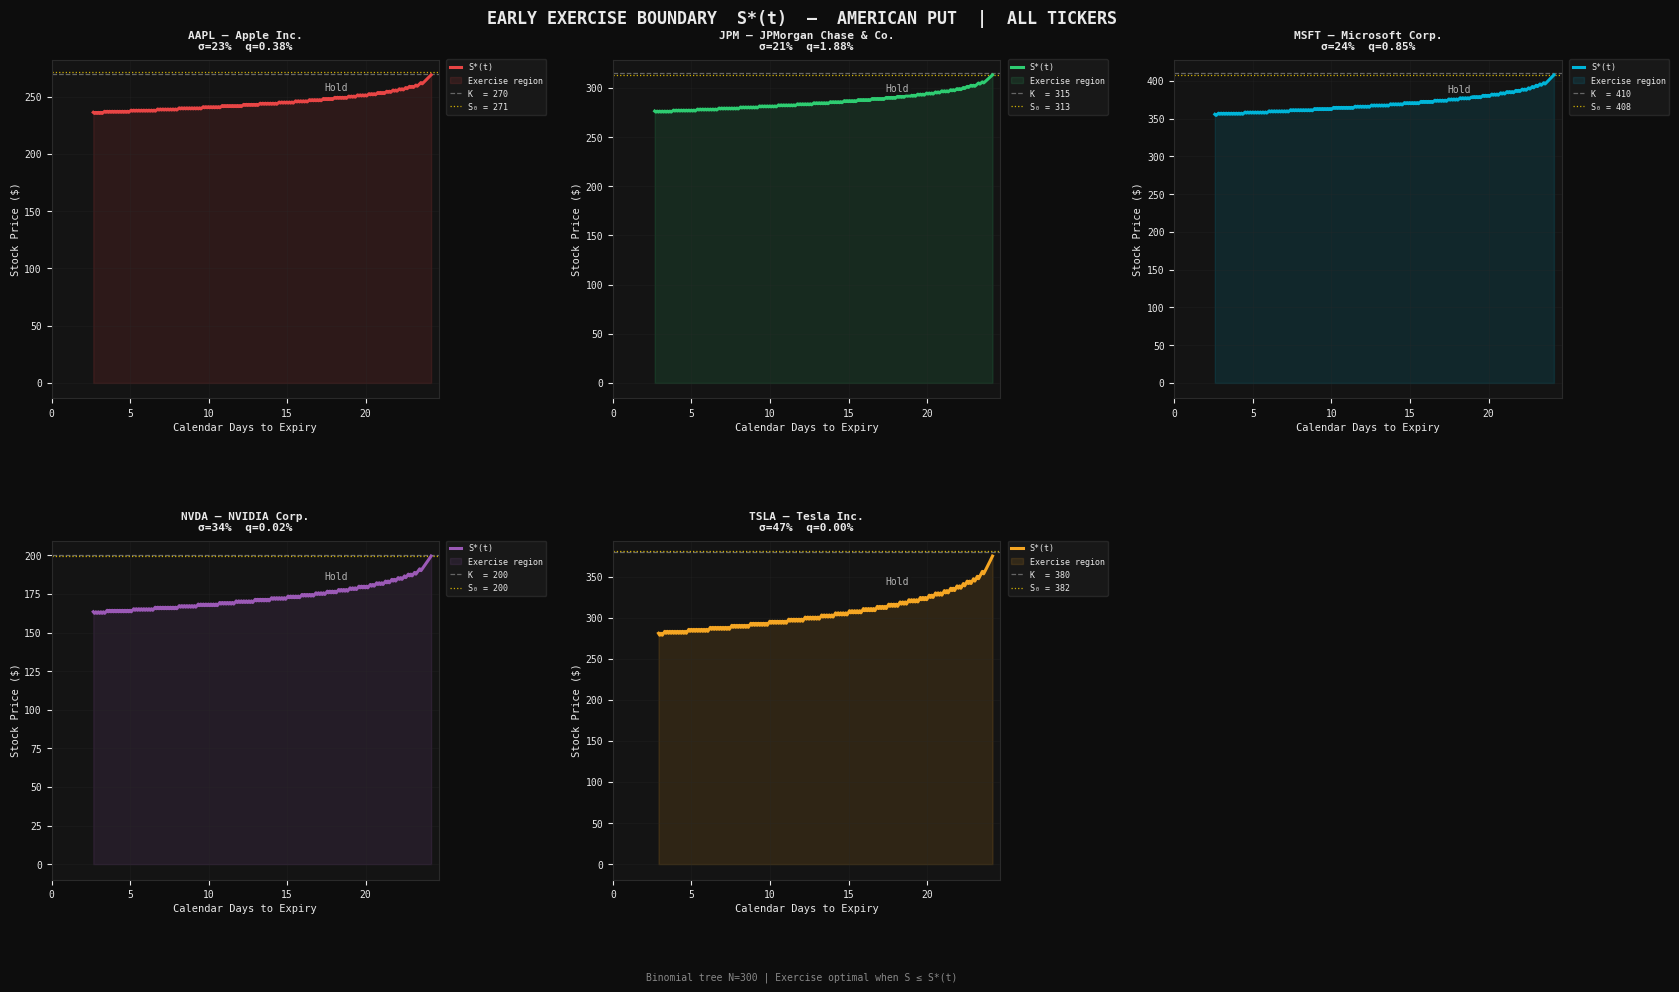

  ✓ fig3a_boundary_per_ticker.png


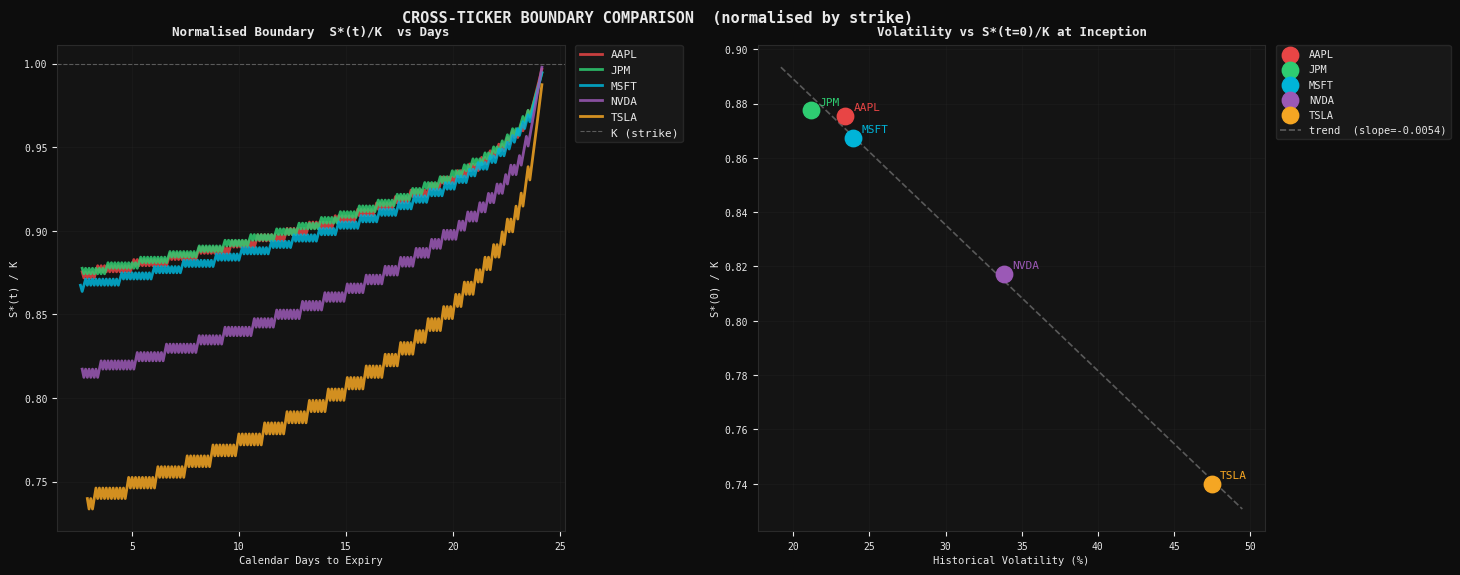

  ✓ fig3b_boundary_comparison.png


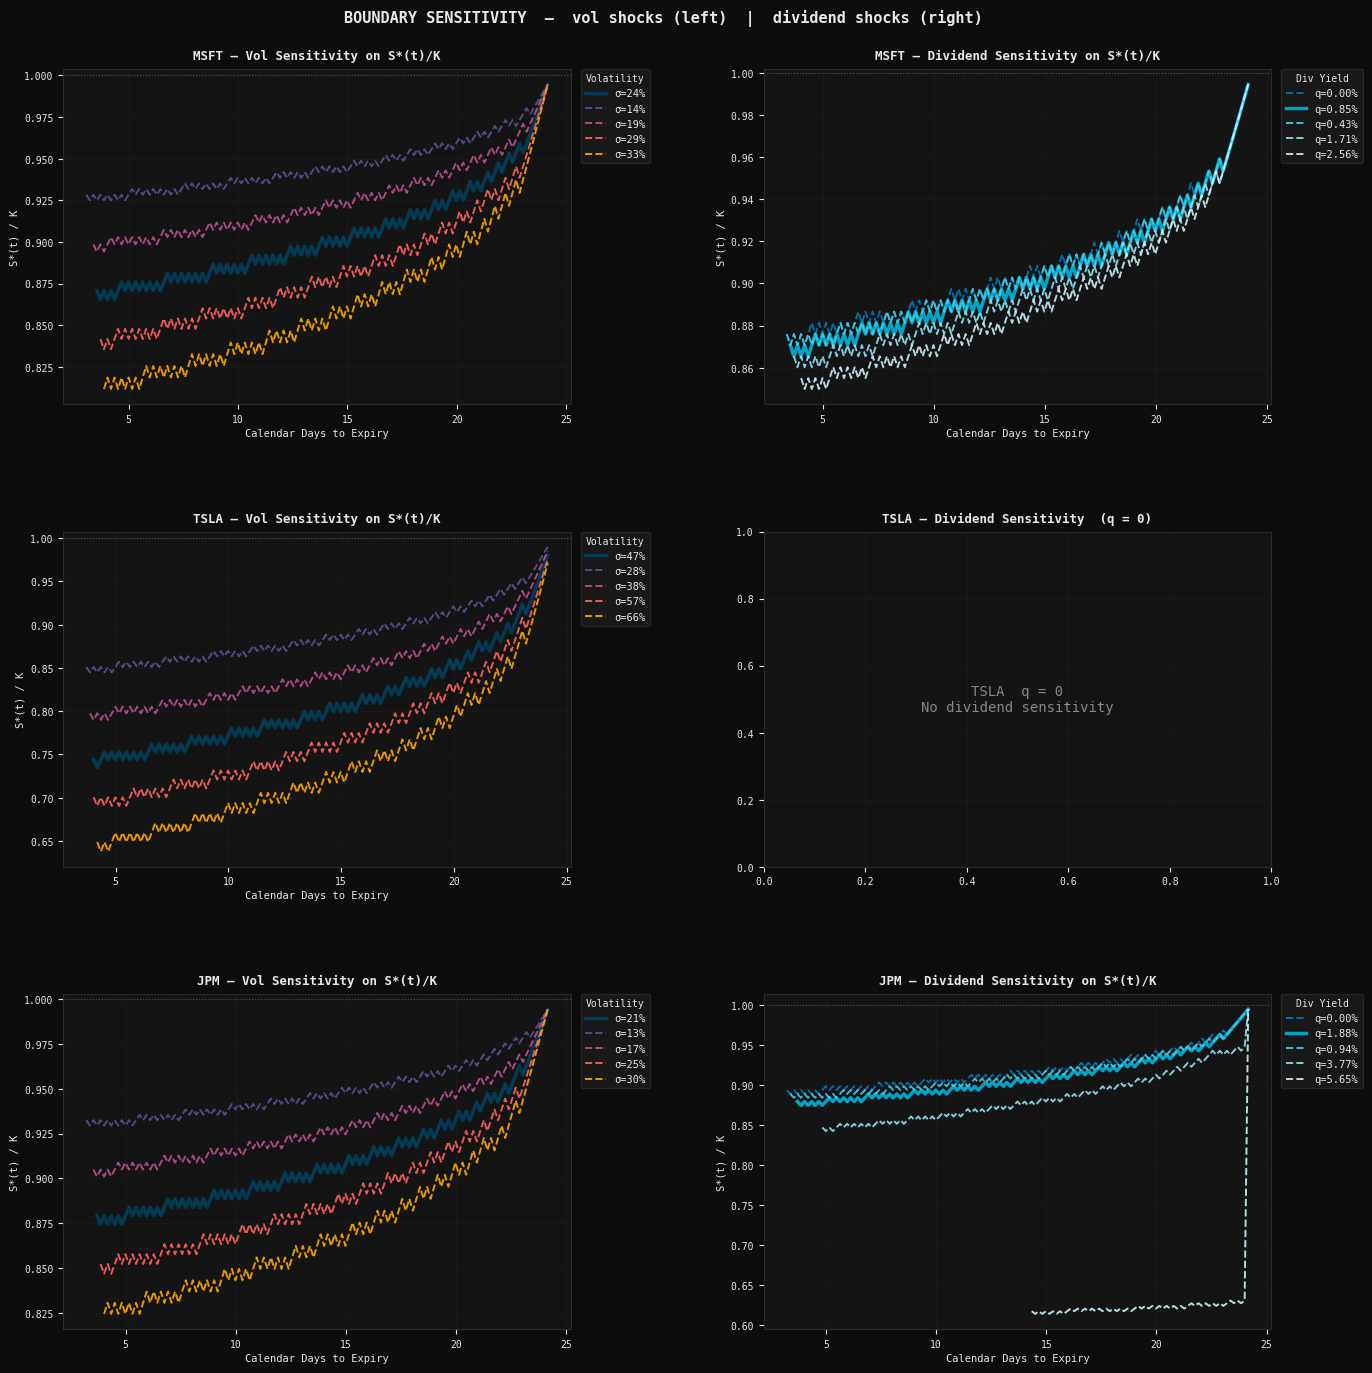

  ✓ fig3c_boundary_sensitivity.png


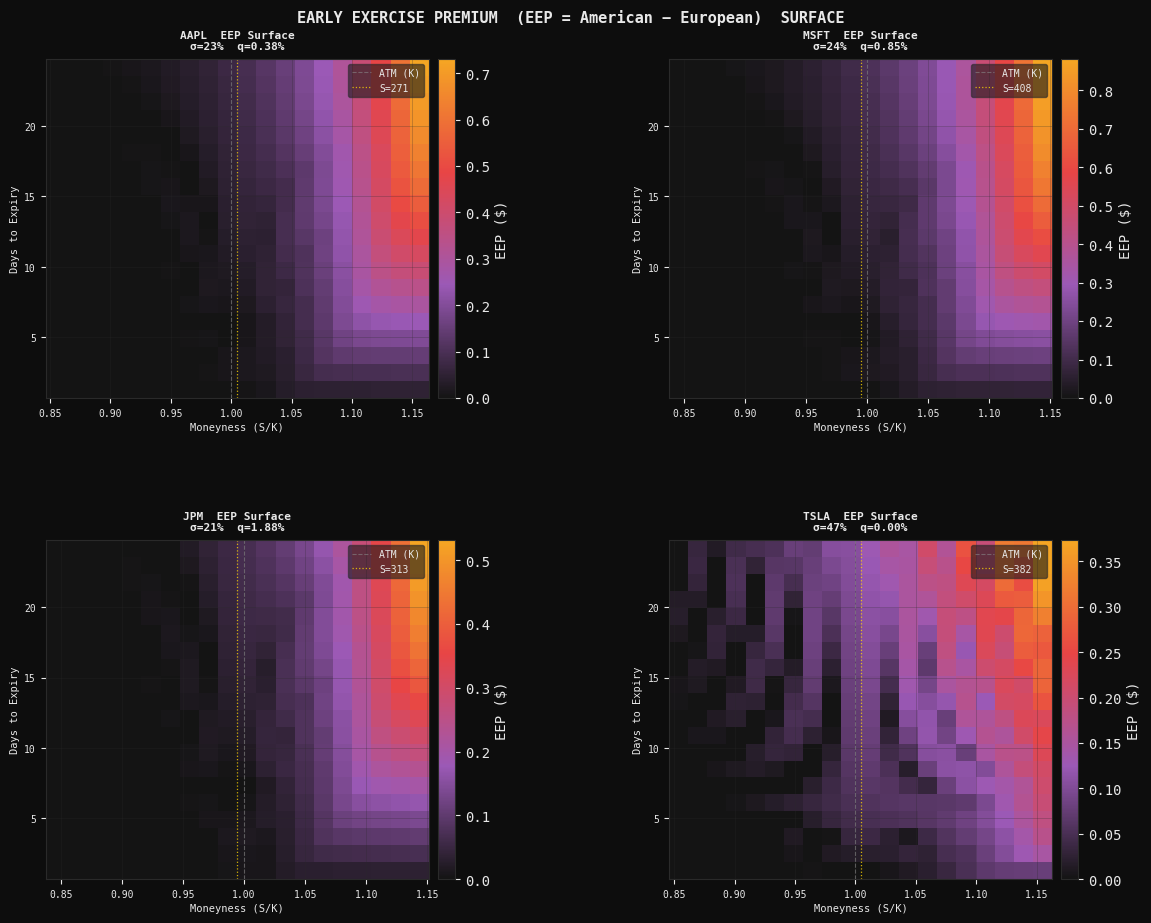

  ✓ fig3d_eep_surface.png

════════════════════════════════════════════════════════════════════════
  MODULE 03 — EARLY EXERCISE BOUNDARY REPORT
════════════════════════════════════════════════════════════════════════

  THEORY RECAP
  ────────────────────────────────────────────────────────────────────────
  For an American put, it is optimal to exercise early when:
    S ≤ S*(t)  where  K - S*(t) = Put(S*(t), K, T-t, r, σ, q)
  i.e. the intrinsic value equals the option's continuation value.
  Key drivers:
    • Higher r  →  lower S* (less incentive to hold put, exercise earlier)
    • Higher q  →  higher S* (dividend reduces call option on stock,
                              raises put holder's cost of waiting)
    • Higher σ  →  lower S* (more optionality value, hold longer)
    • Shorter T →  higher S* (boundary rises toward K as expiry nears)

  BOUNDARY STATISTICS PER TICKER  (put, N=300 steps)
  ────────────────────────────────────────────────────────────────────────
  Ticker 

In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FormatStrFormatter

warnings.filterwarnings("ignore")

BASE_DIR     = "/content"
CONTRACTS_IN = os.path.join(BASE_DIR, "outputs", "priced_contracts.csv")
STOCK_IN     = os.path.join(BASE_DIR, "outputs", "stock_params.csv")
FIG_DIR      = os.path.join(BASE_DIR, "outputs", "figures")
OUT_DIR      = os.path.join(BASE_DIR, "outputs")
os.makedirs(FIG_DIR, exist_ok=True)

PALETTE = {
    "AAPL": "#E84545",
    "MSFT": "#00B4D8",
    "TSLA": "#F5A623",
    "JPM":  "#2ECC71",
    "NVDA": "#9B59B6",
}
DARK   = "#0D0D0D"
CARD   = "#141414"
GRID   = "#2A2A2A"
TEXT   = "#E8E8E8"
MUTED  = "#888888"

plt.rcParams.update({
    "figure.facecolor" : DARK, "axes.facecolor"  : CARD,
    "axes.edgecolor"   : GRID, "axes.labelcolor" : TEXT,
    "axes.titlecolor"  : TEXT, "xtick.color"     : TEXT,
    "ytick.color"      : TEXT, "grid.color"      : GRID,
    "grid.linewidth"   : 0.5,  "text.color"      : TEXT,
    "font.family"      : "monospace",
    "legend.facecolor" : "#1A1A1A", "legend.edgecolor": GRID,
})

N_BOUNDARY = 300
N_DAYS     = 252


def compute_boundary(S0, K, T, r, sigma, q, N=N_BOUNDARY, option_type="put"):
    if T <= 0 or sigma <= 0:
        return np.array([0.0, T]), np.array([np.nan, np.nan])

    dt   = T / N
    u    = np.exp(sigma * np.sqrt(dt))
    d    = 1.0 / u
    disc = np.exp(-r * dt)
    p    = float(np.clip((np.exp((r - q) * dt) - d) / (u - d), 1e-8, 1 - 1e-8))

    j  = np.arange(N + 1)
    ST = S0 * (u ** (N - j)) * (d ** j)
    V  = (np.maximum(K - ST, 0.0) if option_type == "put"
          else np.maximum(ST - K, 0.0))

    boundary = np.full(N + 1, np.nan)
    if option_type == "put":
        ex_mask = K - ST > 0
        if ex_mask.any():
            boundary[N] = ST[ex_mask].max()
    else:
        ex_mask = ST - K > 0
        if ex_mask.any():
            boundary[N] = ST[ex_mask].min()

    for i in range(N - 1, -1, -1):
        j_i  = np.arange(i + 1)
        ST_i = S0 * (u ** (i - j_i)) * (d ** j_i)
        hold = disc * (p * V[:-1] + (1 - p) * V[1:])
        ex   = (np.maximum(K - ST_i, 0.0) if option_type == "put"
                else np.maximum(ST_i - K, 0.0))
        early_mask = ex > hold
        if early_mask.any():
            if option_type == "put":
                boundary[i] = ST_i[early_mask].max()
            else:
                boundary[i] = ST_i[early_mask].min()
        V = np.maximum(hold, ex)

    time_axis = np.linspace(0, T, N + 1)
    return time_axis, boundary


def boundary_sensitivity(S0, K, T, r, sigma_base, q_base, N=150):
    results = {}
    for factor, label in [(0.6, "σ × 0.6"), (0.8, "σ × 0.8"),
                          (1.0, "σ base"),
                          (1.2, "σ × 1.2"), (1.4, "σ × 1.4")]:
        sig = sigma_base * factor
        t, b = compute_boundary(S0, K, T, r, sig, q_base, N, "put")
        results[f"vol_{label}"] = (t, b, sig)

    if q_base > 0.001:
        for factor, label in [(0.0, "q = 0"), (0.5, "q × 0.5"),
                              (1.0, "q base"),
                              (2.0, "q × 2.0"), (3.0, "q × 3.0")]:
            q = q_base * factor
            t, b = compute_boundary(S0, K, T, r, sigma_base, q, N, "put")
            results[f"div_{label}"] = (t, b, q)

    return results


def compute_eep_surface(S0, r, sigma, q, T_max, N_tree=100):
    from scipy.stats import norm

    def bs(S, K, T, r, sig, q, otype):
        if T <= 0: return max(K-S, 0) if otype=='put' else max(S-K, 0)
        d1 = (np.log(S/K)+(r-q+0.5*sig**2)*T)/(sig*np.sqrt(T))
        d2 = d1 - sig*np.sqrt(T)
        if otype=='put':
            return K*np.exp(-r*T)*norm.cdf(-d2) - S*np.exp(-q*T)*norm.cdf(-d1)
        return S*np.exp(-q*T)*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

    def bin_am(S, K, T, r, sig, q, N, otype):
        if T <= 0: return max(K-S,0) if otype=='put' else max(S-K,0)
        dt=T/N; u=np.exp(sig*np.sqrt(dt)); d=1/u
        disc=np.exp(-r*dt); p=float(np.clip((np.exp((r-q)*dt)-d)/(u-d),1e-8,1-1e-8))
        j=np.arange(N+1); ST=S*(u**(N-j))*(d**j)
        V=np.maximum(K-ST,0) if otype=='put' else np.maximum(ST-K,0)
        for i in range(N-1,-1,-1):
            j=np.arange(i+1); ST=S*(u**(i-j))*(d**j)
            V=disc*(p*V[:-1]+(1-p)*V[1:])
            ex=np.maximum(K-ST,0) if otype=='put' else np.maximum(ST-K,0)
            V=np.maximum(V,ex)
        return float(V[0])

    strikes = np.linspace(S0 * 0.85, S0 * 1.15, 20)
    ttms    = np.linspace(0.005, T_max, 20)

    eep_put  = np.zeros((len(ttms), len(strikes)))
    eep_call = np.zeros((len(ttms), len(strikes)))

    for i, T in enumerate(ttms):
        for j, K in enumerate(strikes):
            am_p = bin_am(S0, K, T, r, sigma, q, N_tree, 'put')
            eu_p = bs(S0, K, T, r, sigma, q, 'put')
            eep_put[i, j] = max(am_p - eu_p, 0)

            am_c = bin_am(S0, K, T, r, sigma, q, N_tree, 'call')
            eu_c = bs(S0, K, T, r, sigma, q, 'call')
            eep_call[i, j] = max(am_c - eu_c, 0)

    return {"strikes": strikes, "ttms": ttms, "eep_put": eep_put, "eep_call": eep_call}


def print_report(stock_df, boundaries):
    SEP  = "═" * 72
    SEP2 = "─" * 72

    print(f"\n{SEP}")
    print(f"  MODULE 03 — EARLY EXERCISE BOUNDARY REPORT")
    print(SEP)

    print(f"\n  THEORY RECAP")
    print(f"  {SEP2}")
    print(f"  For an American put, it is optimal to exercise early when:")
    print(f"    S ≤ S*(t)  where  K - S*(t) = Put(S*(t), K, T-t, r, σ, q)")
    print(f"  i.e. the intrinsic value equals the option's continuation value.")
    print(f"  Key drivers:")
    print(f"    • Higher r  →  lower S* (less incentive to hold put, exercise earlier)")
    print(f"    • Higher q  →  higher S* (dividend reduces call option on stock,")
    print(f"                              raises put holder's cost of waiting)")
    print(f"    • Higher σ  →  lower S* (more optionality value, hold longer)")
    print(f"    • Shorter T →  higher S* (boundary rises toward K as expiry nears)")

    print(f"\n  BOUNDARY STATISTICS PER TICKER  (put, N={N_BOUNDARY} steps)")
    print(f"  {SEP2}")
    print(f"  {'Ticker':<6} {'Spot':>7} {'Strike':>7} {'σ':>6} {'q':>6} "
          f"{'S*(t=0)':>9} {'S*(t=T)':>9} {'S*/K(t=0)':>10} {'Range':>8}")
    print(f"  {'-'*70}")

    for tkr, row in stock_df.iterrows():
        if tkr not in boundaries:
            continue
        t_ax, bound = boundaries[tkr]["put"]
        valid = bound[~np.isnan(bound)]
        if len(valid) == 0:
            continue
        S0 = row["spot_price"]
        K  = row["atm_strike"]
        s0 = valid[0]
        sT = valid[-1]
        rng = sT - s0
        print(
            f"  {tkr:<6} {S0:>7.2f} {K:>7.2f} "
            f"{row['historical_volatility']*100:>5.1f}% "
            f"{row['dividend_yield']*100:>5.2f}% "
            f"{s0:>9.2f} {sT:>9.2f} {s0/K:>10.3f} {rng:>+8.2f}"
        )

    print(f"\n  INTERPRETATION")
    print(f"  {SEP2}")
    for tkr, row in stock_df.iterrows():
        if tkr not in boundaries:
            continue
        t_ax, bound = boundaries[tkr]["put"]
        valid = bound[~np.isnan(bound)]
        if len(valid) == 0:
            continue
        s_star = valid[0]
        K      = row["atm_strike"]
        S0     = row["spot_price"]
        q      = row["dividend_yield"]
        sigma  = row["historical_volatility"]
        dist   = S0 - s_star
        status = "BELOW boundary → early exercise NOW optimal" if S0 <= s_star else f"{dist:.2f} above boundary → hold"
        eep_flag = "high div" if q > 0.01 else ("no div" if q < 0.001 else "low div")
        print(f"  {tkr:<5}  S*={s_star:.2f}  K={K:.0f}  Current S={S0:.2f}  [{status}]  ({eep_flag}, σ={sigma*100:.0f}%)")

    print()


def frame(ax, title, xlabel=None, ylabel=None, fontsize=9):
    ax.set_title(title, fontsize=fontsize, fontweight="bold", pad=7, color=TEXT)
    if xlabel: ax.set_xlabel(xlabel, fontsize=7.5, labelpad=3)
    if ylabel: ax.set_ylabel(ylabel, fontsize=7.5, labelpad=3)
    ax.grid(True, alpha=0.35)
    ax.tick_params(labelsize=7)


def plot_all(stock_df, boundaries, sensitivities, eep_surfaces):

    # ── Figure 3a ─────────────────────────────────────────────────────────────
    # Use wider figure + right_margin so legends can sit outside each subplot
    fig3a, axes = plt.subplots(2, 3, figsize=(20, 10))
    fig3a.suptitle(
        "EARLY EXERCISE BOUNDARY  S*(t)  —  AMERICAN PUT  |  ALL TICKERS",
        fontsize=12, fontweight="bold", color=TEXT, y=0.98
    )
    # Extra right margin for outside legends
    plt.subplots_adjust(hspace=0.42, wspace=0.45, top=0.93, right=0.88)

    tickers = list(boundaries.keys())
    ax_flat = axes.flatten()

    for idx, tkr in enumerate(tickers):
        ax  = ax_flat[idx]
        col = PALETTE[tkr]
        row = stock_df.loc[tkr]
        S0  = row["spot_price"]
        K   = row["atm_strike"]
        T   = row["ttm_max"]
        t_ax, bound = boundaries[tkr]["put"]

        days = t_ax * N_DAYS

        ax.plot(days, bound, color=col, lw=2.2, label="S*(t)", zorder=3)
        ax.fill_between(days, bound, 0,
                        where=~np.isnan(bound),
                        alpha=0.12, color=col,
                        label="Exercise region")
        ax.axhline(K,  color=MUTED, lw=0.9, ls="--", alpha=0.7,
                   label=f"K  = {K:.0f}")
        ax.axhline(S0, color="#FFD700", lw=0.9, ls=":",  alpha=0.8,
                   label=f"S₀ = {S0:.0f}")

        # Annotation: place at 75% of x-range, well above/below to avoid line overlap
        t_annot = T * N_DAYS * 0.75
        bound_mid = np.nanmean(bound)
        if not np.isnan(bound_mid):
            if S0 > bound_mid:
                # "Hold" label: midpoint between S0 line and boundary, offset upward
                y_annot = (S0 + bound_mid) / 2
                ax.annotate("Hold", xy=(t_annot, y_annot),
                            fontsize=7, color=TEXT, ha="center", va="center",
                            alpha=0.75,
                            bbox=dict(boxstyle="round,pad=0.2", fc=CARD, alpha=0.6, ec="none"))
            else:
                y_annot = bound_mid * 0.88
                ax.annotate("Exercise", xy=(t_annot, y_annot),
                            fontsize=7, color=col, ha="center", va="center",
                            alpha=0.9,
                            bbox=dict(boxstyle="round,pad=0.2", fc=CARD, alpha=0.6, ec="none"))

        frame(ax,
              f"{tkr} — {row['company_name']}\nσ={row['historical_volatility']*100:.0f}%  q={row['dividend_yield']*100:.2f}%",
              "Calendar Days to Expiry", "Stock Price ($)", fontsize=8)

        # Legend outside to the right of each subplot
        ax.legend(fontsize=6, loc="upper left", bbox_to_anchor=(1.02, 1.0),
                  borderaxespad=0, framealpha=0.85, handlelength=1.4)
        ax.set_xlim(0, T * N_DAYS * 1.02)

    if len(tickers) < 6:
        ax_flat[-1].set_visible(False)

    fig3a.text(0.5, 0.01,
               f"Binomial tree N={N_BOUNDARY} | Exercise optimal when S ≤ S*(t)",
               ha="center", fontsize=7, color=MUTED)
    fig3a.savefig(os.path.join(FIG_DIR, "fig3a_boundary_per_ticker.png"),
                  dpi=180, bbox_inches="tight", facecolor=DARK)
    plt.show()
    print("  ✓ fig3a_boundary_per_ticker.png")

    # ── Figure 3b ─────────────────────────────────────────────────────────────
    fig3b, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig3b.suptitle("CROSS-TICKER BOUNDARY COMPARISON  (normalised by strike)",
                   fontsize=11, fontweight="bold", color=TEXT, y=0.98)
    plt.subplots_adjust(wspace=0.38, top=0.92, right=0.88)

    ax = axes[0]
    for tkr in tickers:
        col = PALETTE[tkr]
        row = stock_df.loc[tkr]
        K   = row["atm_strike"]
        T   = row["ttm_max"]
        t_ax, bound = boundaries[tkr]["put"]
        days = t_ax * N_DAYS
        ax.plot(days, bound / K, color=col, lw=2.0, label=tkr, alpha=0.85)

    ax.axhline(1.0, color=MUTED, lw=0.8, ls="--", alpha=0.6, label="K (strike)")
    frame(ax, "Normalised Boundary  S*(t)/K  vs Days",
          "Calendar Days to Expiry", "S*(t) / K")
    ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.02, 1.0),
              borderaxespad=0, framealpha=0.85)

    # Vol vs S*(0) scatter
    ax = axes[1]
    vols    = [stock_df.loc[tkr, "historical_volatility"] * 100 for tkr in tickers]
    s_stars = []
    for tkr in tickers:
        t_ax, bound = boundaries[tkr]["put"]
        K = stock_df.loc[tkr, "atm_strike"]
        valid = bound[~np.isnan(bound)]
        s_stars.append(valid[0] / K if len(valid) > 0 else np.nan)

    for i, tkr in enumerate(tickers):
        ax.scatter(vols[i], s_stars[i], color=PALETTE[tkr], s=140,
                   zorder=5, label=tkr)
        # Offset annotation to avoid overlapping the scatter dot
        ax.annotate(tkr, xy=(vols[i], s_stars[i]),
                    xytext=(6, 4), textcoords="offset points",
                    fontsize=8, color=PALETTE[tkr])

    valid_mask = ~np.isnan(s_stars)
    if sum(valid_mask) >= 2:
        xv = np.array(vols)[valid_mask]
        yv = np.array(s_stars)[valid_mask]
        z  = np.polyfit(xv, yv, 1)
        xl = np.linspace(min(xv)-2, max(xv)+2, 100)
        ax.plot(xl, np.polyval(z, xl), color=MUTED, lw=1.2, ls="--", alpha=0.6,
                label=f"trend  (slope={z[0]:.4f})")

    frame(ax, "Volatility vs S*(t=0)/K at Inception",
          "Historical Volatility (%)", "S*(0) / K")
    ax.legend(fontsize=7.5, loc="upper left", bbox_to_anchor=(1.02, 1.0),
              borderaxespad=0, framealpha=0.85)

    fig3b.savefig(os.path.join(FIG_DIR, "fig3b_boundary_comparison.png"),
                  dpi=180, bbox_inches="tight", facecolor=DARK)
    plt.show()
    print("  ✓ fig3b_boundary_comparison.png")

    # ── Figure 3c ─────────────────────────────────────────────────────────────
    focus_tickers = [t for t in ["MSFT", "TSLA", "JPM"] if t in sensitivities]
    fig3c, axes = plt.subplots(len(focus_tickers), 2,
                               figsize=(16, 5 * len(focus_tickers)))
    if len(focus_tickers) == 1:
        axes = axes.reshape(1, -1)
    fig3c.suptitle("BOUNDARY SENSITIVITY  —  vol shocks (left)  |  dividend shocks (right)",
                   fontsize=11, fontweight="bold", color=TEXT, y=0.99)
    plt.subplots_adjust(hspace=0.38, wspace=0.38, top=0.95, right=0.88)

    vol_cmap = ["#003f5c","#58508d","#bc5090","#ff6361","#ffa600"]
    div_cmap = ["#0077b6","#00b4d8","#48cae4","#90e0ef","#caf0f8"]

    for ri, tkr in enumerate(focus_tickers):
        row   = stock_df.loc[tkr]
        K     = row["atm_strike"]
        T     = row["ttm_max"]
        sens  = sensitivities[tkr]

        # Vol sensitivity
        ax = axes[ri, 0]
        vol_keys = sorted([k for k in sens if k.startswith("vol_")])
        for ci, key in enumerate(vol_keys):
            t_ax, bound, sig = sens[key]
            days = t_ax * N_DAYS
            lw   = 2.5 if "base" in key else 1.4
            ls   = "-" if "base" in key else "--"
            ax.plot(days, bound / K, color=vol_cmap[ci], lw=lw, ls=ls,
                    label=f"σ={sig*100:.0f}%", alpha=0.9)
        ax.axhline(1.0, color=MUTED, lw=0.8, ls=":", alpha=0.5)
        frame(ax, f"{tkr} — Vol Sensitivity on S*(t)/K",
              "Calendar Days to Expiry", "S*(t) / K")
        ax.legend(fontsize=7.5, title="Volatility", title_fontsize=7,
                  loc="upper left", bbox_to_anchor=(1.02, 1.0),
                  borderaxespad=0, framealpha=0.85)

        # Dividend sensitivity
        ax = axes[ri, 1]
        div_keys = sorted([k for k in sens if k.startswith("div_")])
        if div_keys:
            for ci, key in enumerate(div_keys):
                t_ax, bound, q_val = sens[key]
                days = t_ax * N_DAYS
                lw   = 2.5 if "base" in key else 1.4
                ls   = "-" if "base" in key else "--"
                label = f"q={q_val*100:.2f}%"
                ax.plot(days, bound / K, color=div_cmap[ci], lw=lw, ls=ls,
                        label=label, alpha=0.9)
            ax.axhline(1.0, color=MUTED, lw=0.8, ls=":", alpha=0.5)
            frame(ax, f"{tkr} — Dividend Sensitivity on S*(t)/K",
                  "Calendar Days to Expiry", "S*(t) / K")
            ax.legend(fontsize=7.5, title="Div Yield", title_fontsize=7,
                      loc="upper left", bbox_to_anchor=(1.02, 1.0),
                      borderaxespad=0, framealpha=0.85)
        else:
            ax.text(0.5, 0.5, f"{tkr}  q = 0\nNo dividend sensitivity",
                    ha="center", va="center", transform=ax.transAxes,
                    fontsize=10, color=MUTED)
            frame(ax, f"{tkr} — Dividend Sensitivity  (q = 0)")

    fig3c.savefig(os.path.join(FIG_DIR, "fig3c_boundary_sensitivity.png"),
                  dpi=180, bbox_inches="tight", facecolor=DARK)
    plt.show()
    print("  ✓ fig3c_boundary_sensitivity.png")

    # ── Figure 3d ─────────────────────────────────────────────────────────────
    eep_tickers = [t for t in ["AAPL","MSFT","JPM","TSLA"] if t in eep_surfaces]
    fig3d, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig3d.suptitle("EARLY EXERCISE PREMIUM  (EEP = American − European)  SURFACE",
                   fontsize=11, fontweight="bold", color=TEXT, y=0.98)
    plt.subplots_adjust(hspace=0.42, wspace=0.35, top=0.93)

    from matplotlib.colors import LinearSegmentedColormap
    cmap = LinearSegmentedColormap.from_list("eep", ["#141414","#9B59B6","#E84545","#F5A623"])

    for idx, tkr in enumerate(eep_tickers):
        ax   = axes.flatten()[idx]
        surf = eep_surfaces[tkr]
        K    = stock_df.loc[tkr, "atm_strike"]
        S0   = stock_df.loc[tkr, "spot_price"]

        im = ax.pcolormesh(
            surf["strikes"] / K,
            surf["ttms"] * N_DAYS,
            surf["eep_put"],
            cmap=cmap, shading="auto"
        )
        plt.colorbar(im, ax=ax, label="EEP ($)", pad=0.02)
        ax.axvline(1.0, color=MUTED, lw=0.8, ls="--", alpha=0.6, label="ATM (K)")
        ax.axvline(S0/K, color="#FFD700", lw=0.9, ls=":", alpha=0.8,
                   label=f"S={S0:.0f}")
        row = stock_df.loc[tkr]
        frame(ax, f"{tkr}  EEP Surface\nσ={row['historical_volatility']*100:.0f}%  q={row['dividend_yield']*100:.2f}%",
              "Moneyness (S/K)", "Days to Expiry", fontsize=8)
        # Legend inside is fine for heatmaps — place in corner with low alpha
        ax.legend(fontsize=7, loc="upper right", framealpha=0.6)

    fig3d.savefig(os.path.join(FIG_DIR, "fig3d_eep_surface.png"),
                  dpi=180, bbox_inches="tight", facecolor=DARK)
    plt.show()
    print("  ✓ fig3d_eep_surface.png")


def run():
    print("\n  ┌─ MODULE 03: EARLY EXERCISE BOUNDARY ──────────────────────────────┐")

    print("  │  [1/6] Loading stock parameters and priced contracts...")
    stock_df    = pd.read_csv(STOCK_IN, index_col="ticker")
    contracts   = pd.read_csv(CONTRACTS_IN)

    atm_strikes = {}
    ttm_max     = {}
    for tkr, grp in contracts.groupby("ticker"):
        S0 = grp["spot_price"].iloc[0]
        closest = grp["strike"].sub(S0).abs().idxmin()
        atm_strikes[tkr] = grp.loc[closest, "strike"]
        ttm_max[tkr]     = grp["time_to_maturity"].max()

    stock_df["atm_strike"] = pd.Series(atm_strikes)
    stock_df["ttm_max"]    = pd.Series(ttm_max)

    print(f"  │        {len(stock_df)} tickers  |  {len(contracts)} contracts")

    print(f"  │  [2/6] Computing early exercise boundaries (N={N_BOUNDARY})...")
    boundaries = {}
    for tkr, row in stock_df.iterrows():
        S0    = row["spot_price"]
        K     = row["atm_strike"]
        T     = row["ttm_max"]
        r     = row["r"]
        sigma = row["historical_volatility"]
        q     = row["dividend_yield"]

        t_put, b_put   = compute_boundary(S0, K, T, r, sigma, q, N_BOUNDARY, "put")
        t_call, b_call = compute_boundary(S0, K, T, r, sigma, q, N_BOUNDARY, "call")

        boundaries[tkr] = {"put": (t_put, b_put), "call": (t_call, b_call)}
        valid_put  = b_put[~np.isnan(b_put)]
        valid_call = b_call[~np.isnan(b_call)]
        print(f"  │        {tkr}  put nodes={len(valid_put)}  call nodes={len(valid_call)}")

    print("  │  [3/6] Computing sensitivity curves (vol × div shocks)...")
    sensitivities = {}
    for tkr, row in stock_df.iterrows():
        sensitivities[tkr] = boundary_sensitivity(
            S0=row["spot_price"], K=row["atm_strike"], T=row["ttm_max"],
            r=row["r"], sigma_base=row["historical_volatility"],
            q_base=row["dividend_yield"], N=150,
        )
    print(f"  │        Done — {len(sensitivities)} tickers")

    print("  │  [4/6] Computing EEP surfaces (strike × TTM grid)...")
    eep_surfaces = {}
    for tkr, row in stock_df.iterrows():
        eep_surfaces[tkr] = compute_eep_surface(
            S0=row["spot_price"], r=row["r"], sigma=row["historical_volatility"],
            q=row["dividend_yield"], T_max=row["ttm_max"], N_tree=80,
        )
    print(f"  │        Done — {len(eep_surfaces)} tickers")

    print("  │  [5/6] Saving boundary data...")
    records = []
    for tkr, bd in boundaries.items():
        t_ax, b_put = bd["put"]
        _, b_call   = bd["call"]
        K  = stock_df.loc[tkr, "atm_strike"]
        S0 = stock_df.loc[tkr, "spot_price"]
        for i, t in enumerate(t_ax):
            records.append({
                "ticker"             : tkr,
                "time"               : round(t, 6),
                "days"               : round(t * N_DAYS, 2),
                "boundary_put"       : b_put[i] if not np.isnan(b_put[i]) else None,
                "boundary_call"      : b_call[i] if not np.isnan(b_call[i]) else None,
                "boundary_put_norm"  : b_put[i] / K if not np.isnan(b_put[i]) else None,
                "spot_price"         : S0,
                "atm_strike"         : K,
            })
    bound_df = pd.DataFrame(records)
    bound_df.to_csv(os.path.join(OUT_DIR, "exercise_boundaries.csv"), index=False)
    print(f"  │        exercise_boundaries.csv  ({len(bound_df)} rows)")

    print("  │  [6/6] Generating figures...")
    print("  └────────────────────────────────────────────────────────────────────┘\n")
    plot_all(stock_df, boundaries, sensitivities, eep_surfaces)

    print_report(stock_df, boundaries)

    print(f"  Figures saved to: outputs/figures/")
    print(f"    fig3a_boundary_per_ticker.png")
    print(f"    fig3b_boundary_comparison.png")
    print(f"    fig3c_boundary_sensitivity.png")
    print(f"    fig3d_eep_surface.png")

    return boundaries, bound_df


if __name__ == "__main__":
    boundaries, bound_df = run()


  ┌─ MODULE 04: GREEKS ─────────────────────────────────────────────────┐
  │  [1/5] Loading priced contracts from Module 02...
  │        474 contracts  |  5 tickers
  │  [2/5] Computing Greeks  (N=150, 8 bumps × 2 tree methods)...

  Computing Greeks for 474 contracts  (N=150, 8 tree evals per method)...
  │    9.9%  (  47/474)  elapsed: 2.8s  ETA: 25.3s
  │   19.8%  (  94/474)  elapsed: 5.5s  ETA: 22.3s
  │   29.7%  ( 141/474)  elapsed: 8.3s  ETA: 19.5s
  │   39.7%  ( 188/474)  elapsed: 11.9s  ETA: 18.1s
  │   49.6%  ( 235/474)  elapsed: 15.3s  ETA: 15.5s
  │   59.5%  ( 282/474)  elapsed: 18.1s  ETA: 12.3s
  │   69.4%  ( 329/474)  elapsed: 20.8s  ETA: 9.2s
  │   79.3%  ( 376/474)  elapsed: 23.8s  ETA: 6.2s
  │   89.2%  ( 423/474)  elapsed: 27.8s  ETA: 3.3s
  │   99.2%  ( 470/474)  elapsed: 30.6s  ETA: 0.3s
  │  Done — 30.84s  (65.1ms per contract)

  │  [3/5] Saving greeks_contracts.csv...
  │        474 rows × 75 columns
  │  [4/5] Generating report...
  └─────────────────────────

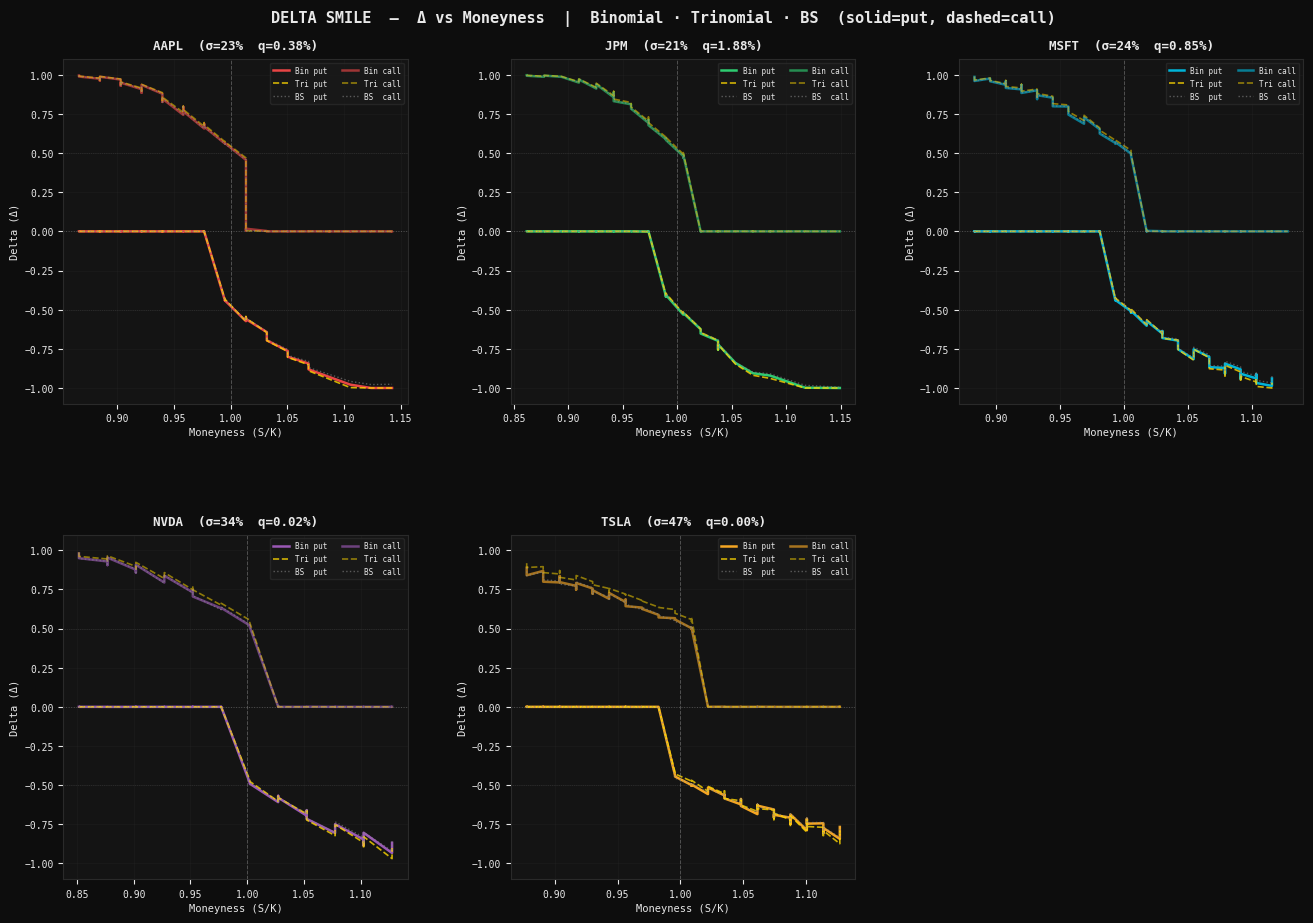

  ✓ fig4a_delta_smile.png


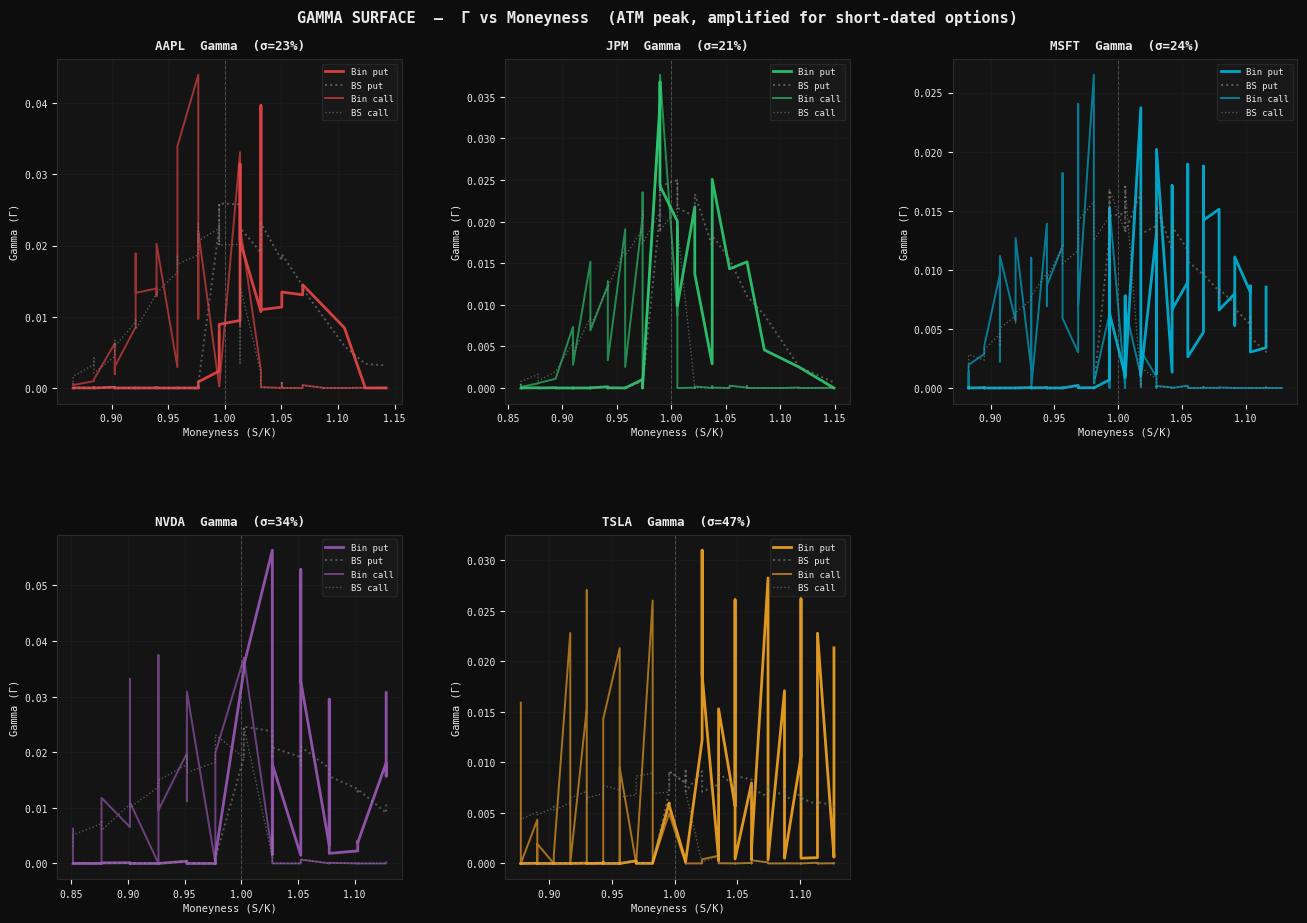

  ✓ fig4b_gamma_surface.png


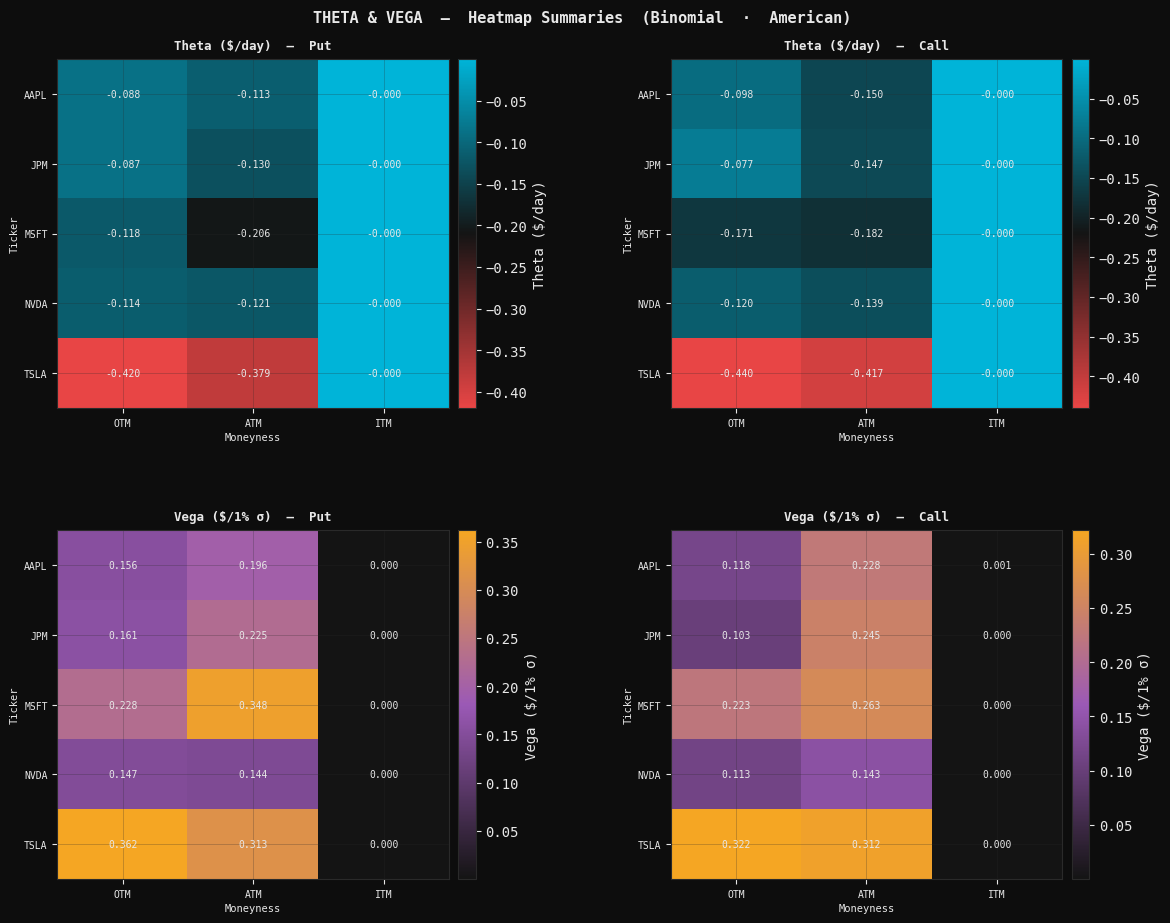

  ✓ fig4c_theta_vega_heatmap.png


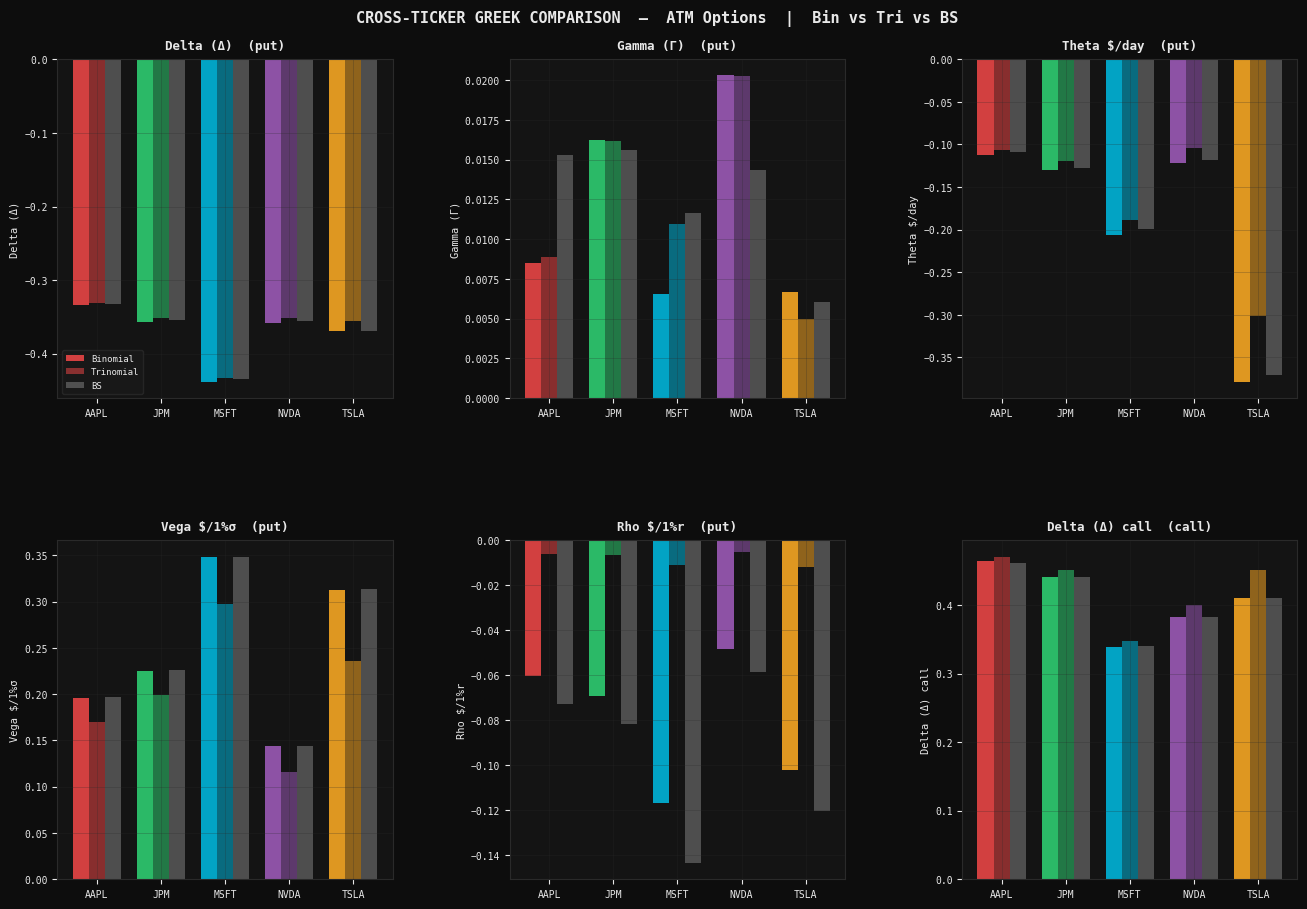

  ✓ fig4d_greeks_barchart.png

  Figures saved to: outputs/figures/
    fig4a_delta_smile.png
    fig4b_gamma_surface.png
    fig4c_theta_vega_heatmap.png
    fig4d_greeks_barchart.png

  Total Greek computation: 30.85s


In [ ]:
import os
import warnings
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm

warnings.filterwarnings("ignore")

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR     = "/content" # In Colab, __file__ is not defined. We can set BASE_DIR to the current content directory.
CONTRACTS_IN = os.path.join(BASE_DIR, "outputs", "priced_contracts.csv")
OUT_DIR      = os.path.join(BASE_DIR, "outputs")
FIG_DIR      = os.path.join(OUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# ── Parameters ────────────────────────────────────────────────────────────────
N_GREEKS   = 150    # tree depth for Greek finite-differences
DS_FRAC    = 0.005  # 0.5% spot bump for Delta / Gamma
D_SIG      = 0.001  # 1bp vol bump for Vega
D_R        = 0.0001 # 1bp rate bump for Rho
DT_BUMP    = 1/252  # 1 trading day for Theta

# ── Visual style ──────────────────────────────────────────────────────────────
PALETTE = {
    "AAPL": "#E84545", "MSFT": "#00B4D8",
    "TSLA": "#F5A623", "JPM":  "#2ECC71", "NVDA": "#9B59B6",
}
DARK = "#0D0D0D"; CARD = "#141414"; GRID = "#2A2A2A"
TEXT = "#E8E8E8"; MUTED = "#888888"

plt.rcParams.update({
    "figure.facecolor": DARK,  "axes.facecolor": CARD,
    "axes.edgecolor":   GRID,  "axes.labelcolor": TEXT,
    "axes.titlecolor":  TEXT,  "xtick.color": TEXT,
    "ytick.color":      TEXT,  "grid.color": GRID,
    "grid.linewidth":   0.5,   "text.color": TEXT,
    "font.family":      "monospace",
    "legend.facecolor": "#1A1A1A", "legend.edgecolor": GRID,
})


# ══════════════════════════════════════════════════════════════════════════════
#  PRICERS  (self-contained copies — module runs standalone)
# ══════════════════════════════════════════════════════════════════════════════

def _bin(S, K, T, r, sig, q, N, otype):
    if T <= 0:
        return max(K-S, 0) if otype == "put" else max(S-K, 0)
    dt = T/N; u = np.exp(sig*np.sqrt(dt)); d = 1/u
    disc = np.exp(-r*dt)
    p = float(np.clip((np.exp((r-q)*dt)-d)/(u-d), 1e-8, 1-1e-8))
    j = np.arange(N+1)
    ST = S*(u**(N-j))*(d**j)
    V  = np.maximum(K-ST, 0) if otype=="put" else np.maximum(ST-K, 0)
    for i in range(N-1, -1, -1):
        j = np.arange(i+1); ST = S*(u**(i-j))*(d**j)
        V = disc*(p*V[:-1]+(1-p)*V[1:])
        ex = np.maximum(K-ST, 0) if otype=="put" else np.maximum(ST-K, 0)
        V = np.maximum(V, ex)
    return float(V[0])


def _tri(S, K, T, r, sig, q, N, otype):
    if T <= 0:
        return max(K-S, 0) if otype == "put" else max(S-K, 0)
    lam = np.sqrt(3.0); dt = T/N; u = np.exp(lam*sig*np.sqrt(dt))
    disc = np.exp(-r*dt); nu = r-q-0.5*sig**2
    edx = np.exp(nu*dt); edx2 = np.exp((2*nu+sig**2)*dt)
    denom = (u-1.)*(u**2-1.)
    if abs(denom) > 1e-12:
        pu = (edx2-edx*(1+u)+u)/denom
        pd_ = (edx2*u-edx*(1+u)*u+u**2)/denom
    else:
        pu = pd_ = 1/6
    pm = 1-pu-pd_
    if not (0 < pu < 1 and 0 < pd_ < 1 and 0 < pm < 1):
        pu = pd_ = 1/6; pm = 2/3
    total = pu+pm+pd_; pu /= total; pm /= total; pd_ /= total
    states = np.arange(-N, N+1, dtype=float)
    ST = S*(u**states)
    V  = np.maximum(K-ST, 0) if otype=="put" else np.maximum(ST-K, 0)
    for i in range(N-1, -1, -1):
        V = disc*(pu*V[:-2]+pm*V[1:-1]+pd_*V[2:])
        st_i = S*(u**np.arange(-i, i+1, dtype=float))
        ex = np.maximum(K-st_i, 0) if otype=="put" else np.maximum(st_i-K, 0)
        V = np.maximum(V, ex)
    return float(V[0])


# ══════════════════════════════════════════════════════════════════════════════
#  GREEK COMPUTATIONS
# ══════════════════════════════════════════════════════════════════════════════

def finite_diff_greeks(S, K, T, r, sig, q, N, otype, pricer) -> dict:
    """
    Compute all five Greeks via finite differences on the given pricer.

    Returns dict with keys: price, delta, gamma, theta, vega, rho
    All Greeks scaled to conventional market units:
      delta : dimensionless  (-1 to 0 for puts, 0 to 1 for calls)
      gamma : per $ spot move²
      theta : $ per calendar day   (negative = time decay)
      vega  : $ per 1% move in σ
      rho   : $ per 1% move in r
    """
    dS  = S * DS_FRAC
    T_t = max(T - DT_BUMP, 1e-6)   # theta bump: 1 day forward

    p0  = pricer(S,      K, T,   r,       sig,       q, N, otype)
    pu  = pricer(S+dS,   K, T,   r,       sig,       q, N, otype)
    pd  = pricer(S-dS,   K, T,   r,       sig,       q, N, otype)
    puu = pricer(S+2*dS, K, T,   r,       sig,       q, N, otype)
    pdd = pricer(S-2*dS, K, T,   r,       sig,       q, N, otype)
    pt  = pricer(S,      K, T_t, r,       sig,       q, N, otype)
    pv  = pricer(S,      K, T,   r,       sig+D_SIG, q, N, otype)
    pr  = pricer(S,      K, T,   r+D_R,   sig,       q, N, otype)

    delta = (pu - pd)   / (2 * dS)
    gamma = (pu - 2*p0 + pd) / (dS ** 2)
    theta = (pt - p0)   / DT_BUMP / 252   # annualised bump → daily
    vega  = (pv - p0)   / D_SIG  / 100    # per 1% σ
    rho   = (pr - p0)   / D_R    / 100    # per 1% r

    return dict(price=p0, delta=delta, gamma=gamma,
                theta=theta, vega=vega, rho=rho)


def bs_greeks_analytical(S, K, T, r, sig, q, otype) -> dict:
    """
    Black-Scholes analytical Greeks (European, Merton generalised).
    Same unit conventions as finite_diff_greeks().
    """
    if T <= 0 or sig <= 0:
        p = max(K-S, 0) if otype=="put" else max(S-K, 0)
        return dict(price=p, delta=np.nan, gamma=np.nan,
                    theta=np.nan, vega=np.nan, rho=np.nan)

    sqT = np.sqrt(T)
    d1  = (np.log(S/K) + (r - q + 0.5*sig**2)*T) / (sig*sqT)
    d2  = d1 - sig*sqT
    nd1 = norm.pdf(d1)
    eqT = np.exp(-q*T); erT = np.exp(-r*T)

    if otype == "put":
        price = K*erT*norm.cdf(-d2) - S*eqT*norm.cdf(-d1)
        delta = -eqT * norm.cdf(-d1)
        theta = ((-S*eqT*nd1*sig/(2*sqT)
                  + r*K*erT*norm.cdf(-d2)
                  - q*S*eqT*norm.cdf(-d1)) / 252)
        rho   = -K*T*erT*norm.cdf(-d2) / 100
    else:
        price = S*eqT*norm.cdf(d1) - K*erT*norm.cdf(d2)
        delta = eqT * norm.cdf(d1)
        theta = ((-S*eqT*nd1*sig/(2*sqT)
                  - r*K*erT*norm.cdf(d2)
                  + q*S*eqT*norm.cdf(d1)) / 252)
        rho   = K*T*erT*norm.cdf(d2) / 100

    gamma = eqT * nd1 / (S * sig * sqT)
    vega  = S * eqT * nd1 * sqT / 100

    return dict(price=price, delta=delta, gamma=gamma,
                theta=theta, vega=vega, rho=rho)


# ══════════════════════════════════════════════════════════════════════════════
#  COMPUTE GREEKS FOR ALL CONTRACTS
# ══════════════════════════════════════════════════════════════════════════════

def compute_all_greeks(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute Greeks for every contract row with three methods:
      BIN (Binomial finite-diff), TRI (Trinomial finite-diff), BS (analytical)
    Returns df with 18 new Greek columns appended.
    """
    n = len(df)
    greek_names = ["price", "delta", "gamma", "theta", "vega", "rho"]
    records = []

    print(f"\n  Computing Greeks for {n} contracts  (N={N_GREEKS}, 8 tree evals per method)...")
    t_start = time.perf_counter()
    checkpoint = max(1, n // 10)

    for idx, (_, row) in enumerate(df.iterrows()):
        S, K  = row["spot_price"], row["strike"]
        T, r  = row["time_to_maturity"], row["r"]
        sig, q = row["iv_used"], row["dividend_yield"]
        otype = row["option_type_std"]

        bg = finite_diff_greeks(S, K, T, r, sig, q, N_GREEKS, otype, _bin)
        tg = finite_diff_greeks(S, K, T, r, sig, q, N_GREEKS, otype, _tri)
        bs = bs_greeks_analytical(S, K, T, r, sig, q, otype)

        row_rec = {}
        for g in greek_names:
            row_rec[f"bin_{g}"]  = bg[g]
            row_rec[f"tri_{g}"]  = tg[g]
            row_rec[f"bs_{g}"]   = bs[g]

        # Delta error vs BS (measures American premium effect on hedge ratio)
        row_rec["bin_delta_vs_bs"] = bg["delta"] - bs["delta"]
        row_rec["tri_delta_vs_bs"] = tg["delta"] - bs["delta"]

        # Greek P&L attribution (1-day move approximation)
        dS_1pct = S * 0.01          # 1% spot shock
        dSig_shock = sig * 0.1      # 10% relative vol shock → e.g. 23% → 25.3%
        row_rec["bin_pnl_delta"] = bg["delta"] * dS_1pct
        row_rec["bin_pnl_gamma"] = 0.5 * bg["gamma"] * dS_1pct**2
        row_rec["bin_pnl_theta"] = bg["theta"]        # 1-day carry

        records.append(row_rec)

        if (idx + 1) % checkpoint == 0:
            pct = (idx+1)/n*100
            el  = time.perf_counter() - t_start
            eta = el/(idx+1)*(n-idx-1)
            print(f"  │  {pct:5.1f}%  ({idx+1:>4}/{n})  "
                  f"elapsed: {el:.1f}s  ETA: {eta:.1f}s")

    t_total = time.perf_counter() - t_start
    print(f"  │  Done — {t_total:.2f}s  ({t_total/n*1000:.1f}ms per contract)\n")

    greek_df = pd.DataFrame(records, index=df.index)
    return pd.concat([df, greek_df], axis=1)


# ══════════════════════════════════════════════════════════════════════════════
#  PRINT REPORT
# ══════════════════════════════════════════════════════════════════════════════

def print_report(df: pd.DataFrame):
    SEP  = "═" * 78
    SEP2 = "─" * 78
    GK   = ["delta", "gamma", "theta", "vega", "rho"]

    print(f"\n{SEP}")
    print(f"  MODULE 04 — GREEKS REPORT")
    print(f"  N={N_GREEKS}  |  {len(df):,} contracts  |  dS={DS_FRAC*100:.1f}%  dσ={D_SIG:.3f}  dr={D_R:.4f}")
    print(SEP)

    # ── Greek definitions ─────────────────────────────────────────────────────
    print(f"\n  GREEK DEFINITIONS  (American option, finite-difference)")
    print(f"  {SEP2}")
    defs = [
        ("Delta (Δ)", "∂V/∂S", "Sensitivity to $1 spot move", "−1 to 0 (put), 0 to 1 (call)"),
        ("Gamma (Γ)", "∂²V/∂S²", "Curvature; rate of delta change per $1", "Always ≥ 0"),
        ("Theta (Θ)", "∂V/∂t  /252", "Value decay per calendar day", "Usually < 0"),
        ("Vega  (V)", "∂V/∂σ  /100", "Value change per 1% vol move", "Always > 0"),
        ("Rho   (ρ)", "∂V/∂r  /100", "Value change per 1% rate move", "Put: <0  Call: >0"),
    ]
    for name, formula, meaning, sign in defs:
        print(f"  {name:<12}  {formula:<14}  {meaning:<40}  {sign}")

    # ── ATM snapshot ──────────────────────────────────────────────────────────
    print(f"\n  ATM GREEKS SNAPSHOT  (Binomial | Trinomial | BS Analytical)")
    print(f"  {SEP2}")
    atm = df[df["moneyness_label"] == "ATM"].copy()

    for otype in ["put", "call"]:
        sub = atm[atm["option_type_std"] == otype]
        if sub.empty:
            continue
        print(f"\n  ── {otype.upper()} ──────────────────")
        print(f"  {'Ticker':<6} {'Mkt':>6}  "
              + "  ".join(f"{'Bin_'+g[:3]:>8}" for g in GK)
              + "  "
              + "  ".join(f"{'Tri_'+g[:3]:>8}" for g in GK)
              + "  "
              + "  ".join(f"{'BS_'+g[:3]:>8}" for g in GK))
        print(f"  {'-'*76}")

        for tkr, grp in sub.groupby("ticker"):
            avg_mkt = grp["market_price"].mean()
            bin_vals = [grp[f"bin_{g}"].mean() for g in GK]
            tri_vals = [grp[f"tri_{g}"].mean() for g in GK]
            bs_vals  = [grp[f"bs_{g}"].mean()  for g in GK]
            print(
                f"  {tkr:<6} {avg_mkt:>6.3f}  "
                + "  ".join(f"{v:>8.4f}" for v in bin_vals)
                + "  "
                + "  ".join(f"{v:>8.4f}" for v in tri_vals)
                + "  "
                + "  ".join(f"{v:>8.4f}" for v in bs_vals)
            )

    # ── Greek method comparison (overall) ─────────────────────────────────────
    print(f"\n  BINOMIAL vs TRINOMIAL vs BS  —  MEAN ABSOLUTE DIFFERENCE")
    print(f"  {SEP2}")
    print(f"  {'Greek':<8}  {'|Bin−BS|':>10}  {'|Tri−BS|':>10}  {'|Bin−Tri|':>10}")
    print(f"  {'-'*44}")
    for g in GK:
        b_vs_bs = (df[f"bin_{g}"] - df[f"bs_{g}"]).abs().mean()
        t_vs_bs = (df[f"tri_{g}"] - df[f"bs_{g}"]).abs().mean()
        b_vs_t  = (df[f"bin_{g}"] - df[f"tri_{g}"]).abs().mean()
        print(f"  {g.capitalize():<8}  {b_vs_bs:>10.5f}  {t_vs_bs:>10.5f}  {b_vs_t:>10.5f}")

    # ── Delta vs BS by moneyness ───────────────────────────────────────────────
    print(f"\n  AMERICAN DELTA vs BS DELTA  (early exercise adjustment)")
    print(f"  {SEP2}")
    print(f"  For puts: American Δ > BS Δ when early exercise is likely")
    print(f"  (the put should be more sensitive — deeper ITM = exercise now)")
    print()
    print(f"  {'Moneyness':<6} {'Type':<5} {'n':>4}  {'AvgΔ(Bin)':>10}  {'AvgΔ(BS)':>10}  {'Δ−Diff':>9}  {'Interpretation'}")
    print(f"  {'-'*72}")
    for money in ["ITM", "ATM", "OTM"]:
        for otype in ["put", "call"]:
            sub = df[(df["moneyness_label"]==money) & (df["option_type_std"]==otype)]
            if sub.empty: continue
            b_d  = sub["bin_delta"].mean()
            bs_d = sub["bs_delta"].mean()
            diff = b_d - bs_d
            interp = ("exercise pull ↑" if abs(diff)>0.01
                      else "close to European")
            print(f"  {money:<6} {otype:<5} {len(sub):>4}  {b_d:>10.4f}  {bs_d:>10.4f}  {diff:>+9.4f}  {interp}")

    # ── Top Gamma contracts ────────────────────────────────────────────────────
    print(f"\n  TOP 10 CONTRACTS BY GAMMA  (Binomial)")
    print(f"  {SEP2}")
    top_g = df.nlargest(10, "bin_gamma")[
        ["ticker","contractSymbol","option_type_std","moneyness_label",
         "strike","spot_price","bin_gamma","tri_gamma","bs_gamma",
         "bin_delta","time_to_maturity"]]
    print(f"  {'Ticker':<6} {'Type':<5} {'Money':<5} {'K':>7} {'S':>7}  "
          f"{'Bin Γ':>8}  {'Tri Γ':>8}  {'BS Γ':>8}  {'Bin Δ':>8}  {'TTM':>6}")
    print(f"  {'-'*76}")
    for _, row in top_g.iterrows():
        print(
            f"  {row['ticker']:<6} {row['option_type_std']:<5} {row['moneyness_label']:<5}"
            f"  {row['strike']:>7.1f} {row['spot_price']:>7.2f}"
            f"  {row['bin_gamma']:>8.5f}  {row['tri_gamma']:>8.5f}  {row['bs_gamma']:>8.5f}"
            f"  {row['bin_delta']:>8.4f}  {row['time_to_maturity']:>6.4f}"
        )

    # ── Greek P&L attribution ──────────────────────────────────────────────────
    print(f"\n  1-DAY GREEK P&L ATTRIBUTION  (Binomial, 1% spot shock scenario)")
    print(f"  {SEP2}")
    print(f"  {'Ticker':<6} {'Type':<5}  {'Avg Δ P&L':>10}  {'Avg Γ P&L':>10}  "
          f"{'Avg Θ P&L':>10}  {'Δ/Θ ratio':>10}")
    print(f"  {'-'*58}")
    for (tkr, otype), grp in df.groupby(["ticker","option_type_std"]):
        dp = grp["bin_pnl_delta"].mean()
        gp = grp["bin_pnl_gamma"].mean()
        tp = grp["bin_pnl_theta"].mean()
        ratio = abs(dp/tp) if abs(tp) > 1e-6 else np.inf
        print(f"  {tkr:<6} {otype:<5}  {dp:>10.4f}  {gp:>10.5f}  {tp:>10.4f}  {ratio:>10.2f}x")

    print(f"\n{SEP}\n")


# ══════════════════════════════════════════════════════════════════════════════
#  VISUALISATION
# ══════════════════════════════════════════════════════════════════════════════

def frame(ax, title, xlabel=None, ylabel=None, fs=9):
    ax.set_title(title, fontsize=fs, fontweight="bold", pad=7, color=TEXT)
    if xlabel: ax.set_xlabel(xlabel, fontsize=7.5, labelpad=3)
    if ylabel: ax.set_ylabel(ylabel, fontsize=7.5, labelpad=3)
    ax.grid(True, alpha=0.35); ax.tick_params(labelsize=7)


def plot_all(df: pd.DataFrame):
    tickers = sorted(df["ticker"].unique())

    # ── Figure 4a: Delta smile across all tickers ──────────────────────────────
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle("DELTA SMILE  —  Δ vs Moneyness  |  Binomial · Trinomial · BS  (solid=put, dashed=call)",
                 fontsize=11, fontweight="bold", color=TEXT, y=0.98)
    plt.subplots_adjust(hspace=0.38, wspace=0.3, top=0.93)

    for idx, tkr in enumerate(tickers):
        ax  = axes.flatten()[idx]
        col = PALETTE[tkr]
        sub = df[df["ticker"] == tkr].sort_values("moneyness")

        for otype, ls_bin, ls_tri, ls_bs in [
            ("put",  "-",  "--", ":"),
            ("call", "-",  "--", ":")
        ]:
            grp = sub[sub["option_type_std"] == otype]
            if grp.empty: continue
            alpha = 1.0 if otype == "put" else 0.65
            ax.plot(grp["moneyness"], grp["bin_delta"],
                    color=col,     lw=1.8, ls=ls_bin, alpha=alpha,
                    label=f"Bin {otype}")
            ax.plot(grp["moneyness"], grp["tri_delta"],
                    color="#FFD700", lw=1.2, ls=ls_tri, alpha=alpha*0.8,
                    label=f"Tri {otype}")
            ax.plot(grp["moneyness"], grp["bs_delta"],
                    color=MUTED,   lw=1.0, ls=ls_bs, alpha=0.6,
                    label=f"BS  {otype}")

        ax.axhline(0,    color=MUTED, lw=0.7, ls=":", alpha=0.5)
        ax.axhline(-0.5, color=MUTED, lw=0.5, ls=":", alpha=0.3)
        ax.axhline( 0.5, color=MUTED, lw=0.5, ls=":", alpha=0.3)
        ax.axvline(1.0,  color=MUTED, lw=0.7, ls="--", alpha=0.5)
        row = df[df["ticker"]==tkr].iloc[0]
        frame(ax, f"{tkr}  (σ={row['historical_volatility']*100:.0f}%  q={row['dividend_yield']*100:.2f}%)",
              "Moneyness (S/K)", "Delta (Δ)")
        ax.set_ylim(-1.1, 1.1)
        ax.legend(fontsize=5.5, ncol=2)

    if len(tickers) < 6: axes.flatten()[-1].set_visible(False)
    fig.savefig(os.path.join(FIG_DIR, "fig4a_delta_smile.png"),
                dpi=180, bbox_inches="tight", facecolor=DARK)
    plt.show(); print("  ✓ fig4a_delta_smile.png")

    # ── Figure 4b: Gamma surface (cross-ticker) ────────────────────────────────
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle("GAMMA SURFACE  —  Γ vs Moneyness  (ATM peak, amplified for short-dated options)",
                 fontsize=11, fontweight="bold", color=TEXT, y=0.98)
    plt.subplots_adjust(hspace=0.38, wspace=0.3, top=0.93)

    for idx, tkr in enumerate(tickers):
        ax  = axes.flatten()[idx]
        col = PALETTE[tkr]
        sub = df[df["ticker"] == tkr].sort_values("moneyness")

        for otype, lw, alpha in [("put", 2.0, 0.9), ("call", 1.4, 0.65)]:
            grp = sub[sub["option_type_std"] == otype]
            if grp.empty: continue
            ax.plot(grp["moneyness"], grp["bin_gamma"],
                    color=col,      lw=lw,  ls="-",  alpha=alpha,
                    label=f"Bin {otype}")
            ax.plot(grp["moneyness"], grp["bs_gamma"],
                    color=MUTED,    lw=lw*0.7, ls=":", alpha=0.6,
                    label=f"BS {otype}")

        ax.axvline(1.0, color=MUTED, lw=0.7, ls="--", alpha=0.5)
        row = df[df["ticker"]==tkr].iloc[0]
        frame(ax, f"{tkr}  Gamma  (σ={row['historical_volatility']*100:.0f}%)",
              "Moneyness (S/K)", "Gamma (Γ)")
        ax.legend(fontsize=6.5)

    if len(tickers) < 6: axes.flatten()[-1].set_visible(False)
    fig.savefig(os.path.join(FIG_DIR, "fig4b_gamma_surface.png"),
                dpi=180, bbox_inches="tight", facecolor=DARK)
    plt.show(); print("  ✓ fig4b_gamma_surface.png")

    # ── Figure 4c: Theta and Vega heatmaps ────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("THETA & VEGA  —  Heatmap Summaries  (Binomial  ·  American)",
                 fontsize=11, fontweight="bold", color=TEXT, y=0.98)
    plt.subplots_adjust(hspace=0.35, wspace=0.3, top=0.93)

    from matplotlib.colors import LinearSegmentedColormap
    c_theta = LinearSegmentedColormap.from_list("theta", ["#E84545","#141414","#00B4D8"])
    c_vega  = LinearSegmentedColormap.from_list("vega",  ["#141414","#9B59B6","#F5A623"])

    for (ax, greek, cmap, label, otype) in [
        (axes[0,0], "bin_theta", c_theta, "Theta ($/day)",  "put"),
        (axes[0,1], "bin_theta", c_theta, "Theta ($/day)",  "call"),
        (axes[1,0], "bin_vega",  c_vega,  "Vega ($/1% σ)",  "put"),
        (axes[1,1], "bin_vega",  c_vega,  "Vega ($/1% σ)",  "call"),
    ]:
        sub = df[df["option_type_std"] == otype].copy()
        pivot = (sub.groupby(["ticker","moneyness_label"])[greek]
                    .mean().unstack())
        for col_lbl in ["OTM","ATM","ITM"]:
            if col_lbl not in pivot.columns:
                pivot[col_lbl] = np.nan
        pivot = pivot[["OTM","ATM","ITM"]]

        im = ax.imshow(pivot.values, cmap=cmap, aspect="auto",
                       vmin=pivot.values.min(), vmax=pivot.values.max())
        plt.colorbar(im, ax=ax, label=label, pad=0.02)
        ax.set_xticks(range(3));   ax.set_xticklabels(["OTM","ATM","ITM"], fontsize=8)
        ax.set_yticks(range(len(pivot))); ax.set_yticklabels(pivot.index, fontsize=8)

        # Annotate cells
        for ri in range(pivot.shape[0]):
            for ci in range(pivot.shape[1]):
                val = pivot.values[ri, ci]
                if not np.isnan(val):
                    ax.text(ci, ri, f"{val:.3f}", ha="center", va="center",
                            fontsize=7, color=TEXT)

        frame(ax, f"{label}  —  {otype.capitalize()}",
              "Moneyness", "Ticker")

    fig.savefig(os.path.join(FIG_DIR, "fig4c_theta_vega_heatmap.png"),
                dpi=180, bbox_inches="tight", facecolor=DARK)
    plt.show(); print("  ✓ fig4c_theta_vega_heatmap.png")

    # ── Figure 4d: Cross-greek comparison bar chart ────────────────────────────
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle("CROSS-TICKER GREEK COMPARISON  —  ATM Options  |  Bin vs Tri vs BS",
                 fontsize=11, fontweight="bold", color=TEXT, y=0.98)
    plt.subplots_adjust(hspace=0.42, wspace=0.35, top=0.93)

    atm = df[df["moneyness_label"] == "ATM"]
    greek_pairs = [
        ("delta", "Delta (Δ)", "put"),
        ("gamma", "Gamma (Γ)", "put"),
        ("theta", "Theta $/day", "put"),
        ("vega",  "Vega $/1%σ", "put"),
        ("rho",   "Rho $/1%r",  "put"),
        ("delta", "Delta (Δ) call", "call"),
    ]
    x = np.arange(len(tickers))
    w = 0.25

    for idx, (greek, label, otype) in enumerate(greek_pairs):
        ax  = axes.flatten()[idx]
        sub = atm[atm["option_type_std"] == otype].groupby("ticker")

        bin_vals = [sub.get_group(t)[f"bin_{greek}"].mean() if t in sub.groups else 0
                    for t in tickers]
        tri_vals = [sub.get_group(t)[f"tri_{greek}"].mean() if t in sub.groups else 0
                    for t in tickers]
        bs_vals  = [sub.get_group(t)[f"bs_{greek}"].mean()  if t in sub.groups else 0
                    for t in tickers]

        cols = [PALETTE[t] for t in tickers]
        ax.bar(x - w,   bin_vals, w, color=cols, alpha=0.9,  label="Binomial",  edgecolor="none")
        ax.bar(x,       tri_vals, w, color=cols, alpha=0.55, label="Trinomial", edgecolor="none", hatch="//")
        ax.bar(x + w,   bs_vals,  w, color=MUTED,alpha=0.5,  label="BS",        edgecolor="none")

        ax.set_xticks(x); ax.set_xticklabels(tickers, fontsize=7)
        ax.axhline(0, color=MUTED, lw=0.7, alpha=0.5)
        frame(ax, f"{label}  ({otype})", "", label)
        if idx == 0: ax.legend(fontsize=6.5)

    if len(greek_pairs) < 6: axes.flatten()[-1].set_visible(False)
    fig.savefig(os.path.join(FIG_DIR, "fig4d_greeks_barchart.png"),
                dpi=180, bbox_inches="tight", facecolor=DARK)
    plt.show(); print("  ✓ fig4d_greeks_barchart.png")


# ══════════════════════════════════════════════════════════════════════════════
#  MAIN ENTRY POINT
# ══════════════════════════════════════════════════════════════════════════════

def run():
    print("\n  ┌─ MODULE 04: GREEKS ─────────────────────────────────────────────────┐")

    # 1. Load
    print("  │  [1/5] Loading priced contracts from Module 02...")
    if not os.path.exists(CONTRACTS_IN):
        raise FileNotFoundError("priced_contracts.csv not found — run Module 02 first.")
    df = pd.read_csv(CONTRACTS_IN)
    print(f"  │        {len(df):,} contracts  |  {df['ticker'].nunique()} tickers")

    # 2. Compute
    print(f"  │  [2/5] Computing Greeks  (N={N_GREEKS}, 8 bumps × 2 tree methods)...")
    t0 = time.perf_counter()
    gdf = compute_all_greeks(df)
    t_total = time.perf_counter() - t0

    # 3. Save
    print("  │  [3/5] Saving greeks_contracts.csv...")
    gdf.to_csv(os.path.join(OUT_DIR, "greeks_contracts.csv"), index=False)
    print(f"  │        {len(gdf):,} rows × {len(gdf.columns)} columns")

    # 4. Report
    print("  │  [4/5] Generating report...")
    print("  └────────────────────────────────────────────────────────────────────────┘")
    print_report(gdf)

    # 5. Figures
    print("  [5/5] Generating figures...")
    plot_all(gdf)

    print(f"\n  Figures saved to: outputs/figures/")
    print(f"    fig4a_delta_smile.png")
    print(f"    fig4b_gamma_surface.png")
    print(f"    fig4c_theta_vega_heatmap.png")
    print(f"    fig4d_greeks_barchart.png")
    print(f"\n  Total Greek computation: {t_total:.2f}s")

    return gdf


if __name__ == "__main__":
    gdf = run()


  ┌─ MODULE 05: CONVERGENCE & EFFICIENCY ──────────────────────────────┐
  │  [1/5] Loading priced contracts...
  │        474 contracts  |  5 tickers
  │  [2/5] Selecting ATM representative contracts...
  │        30 contracts selected  (tickers × expiries × types)
  │  [3/5] Computing convergence curves  (N=5→500, ref=1000)...
  │     3%  AAPL C 05-22                  ref_bin=7.0212  rate=-0.94
  │    17%  AAPL P 05-29                  ref_bin=6.0636  rate=-1.06
  │    33%  JPM P 05-22                   ref_bin=7.1357  rate=-1.43
  │    50%  MSFT C 06-05                  ref_bin=11.4870  rate=-0.86
  │    67%  NVDA C 05-29                  ref_bin=7.5178  rate=-2.04
  │    83%  TSLA C 05-22                  ref_bin=18.5147  rate=-0.68
  │   100%  TSLA P 06-05                  ref_bin=20.9276  rate=-1.14
  │        Done — 30 curves computed
  │  [4/5] Running efficiency benchmarks  (20 reps × 9 step counts)...
  │        Binomial O(N^1.01)  |  Trinomial O(N^1.04)
  │  [5/5] Saving co

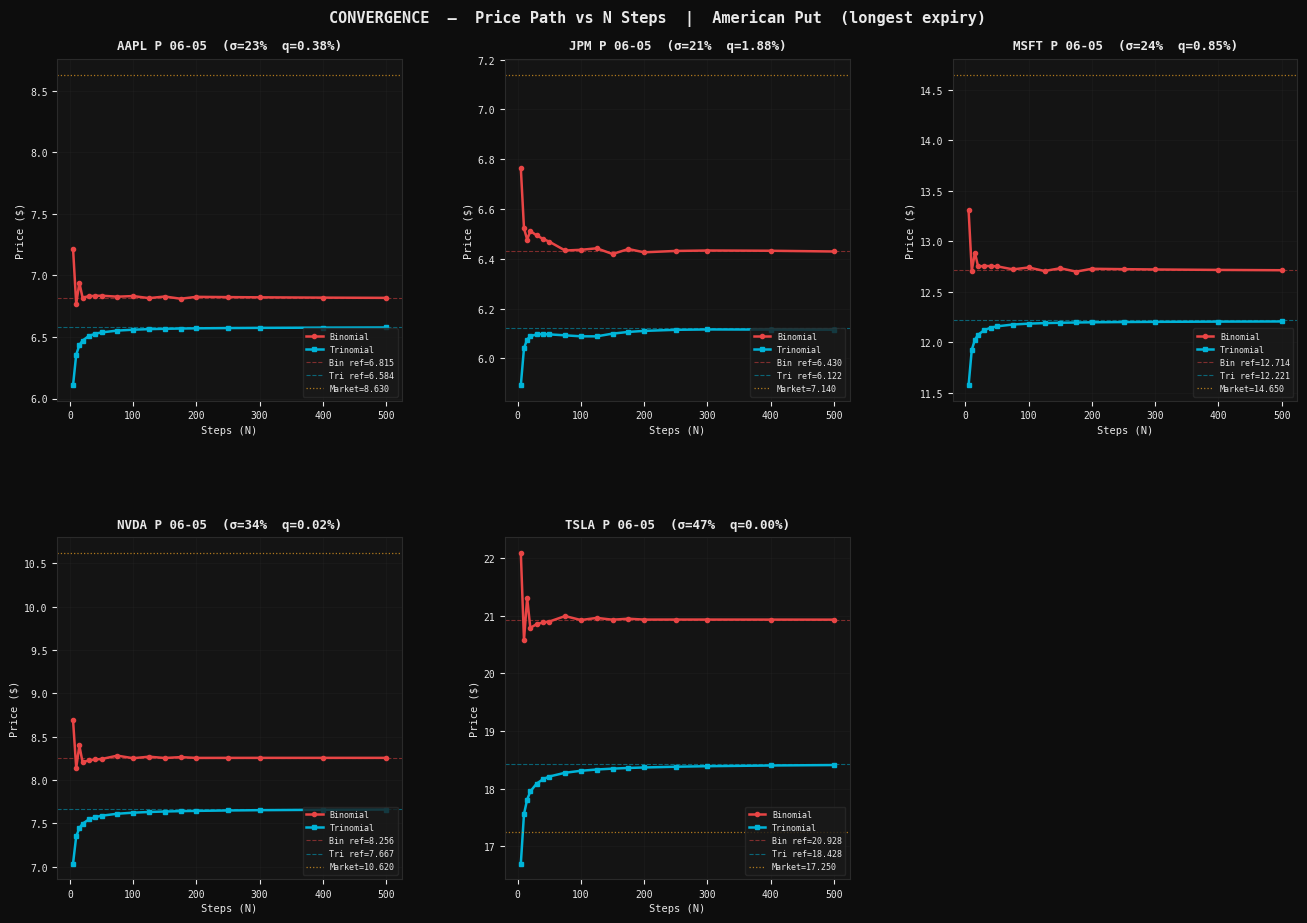

  ✓ fig5a_convergence_paths.png


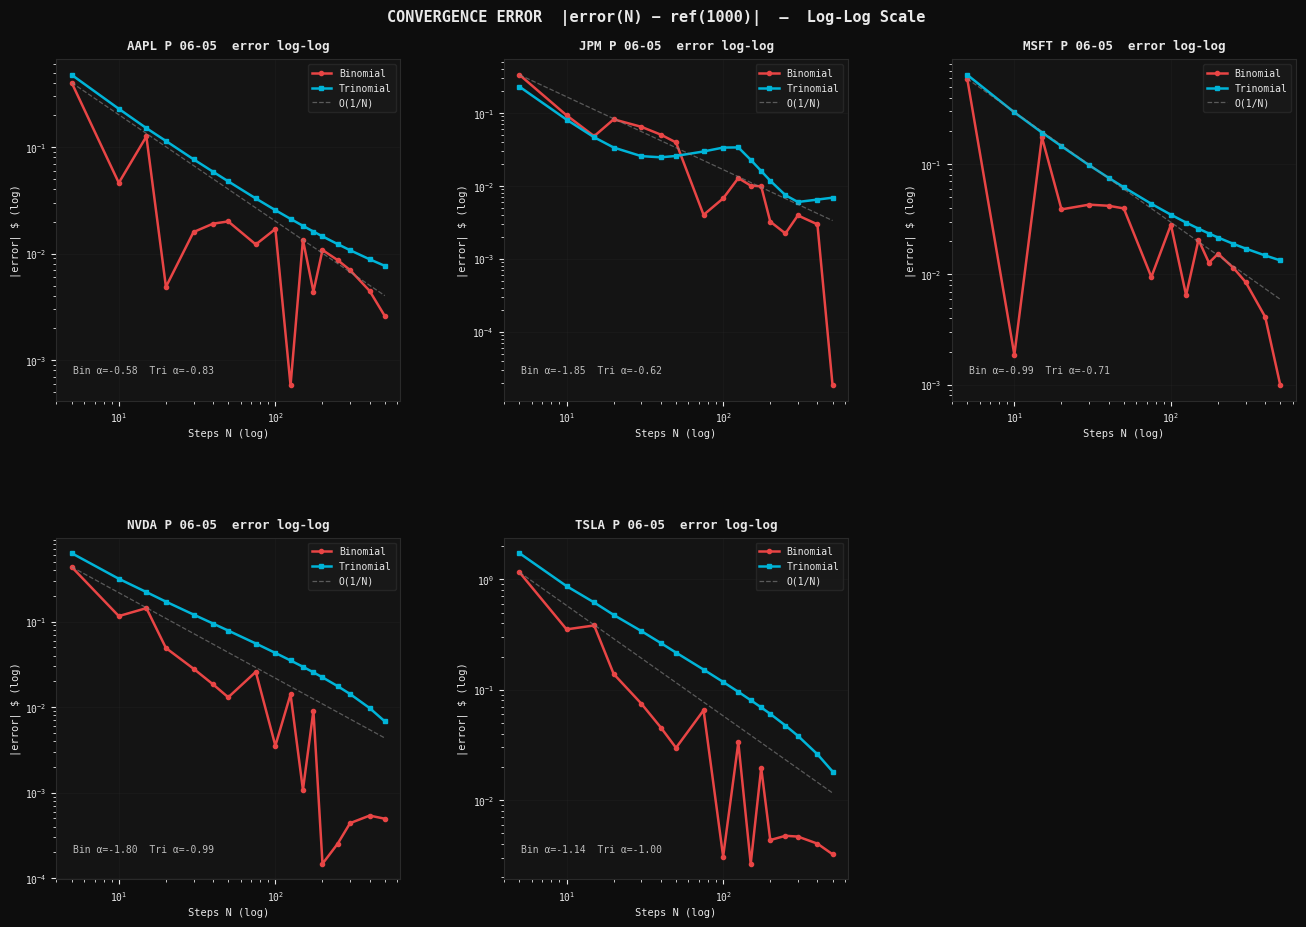

  ✓ fig5b_convergence_error.png


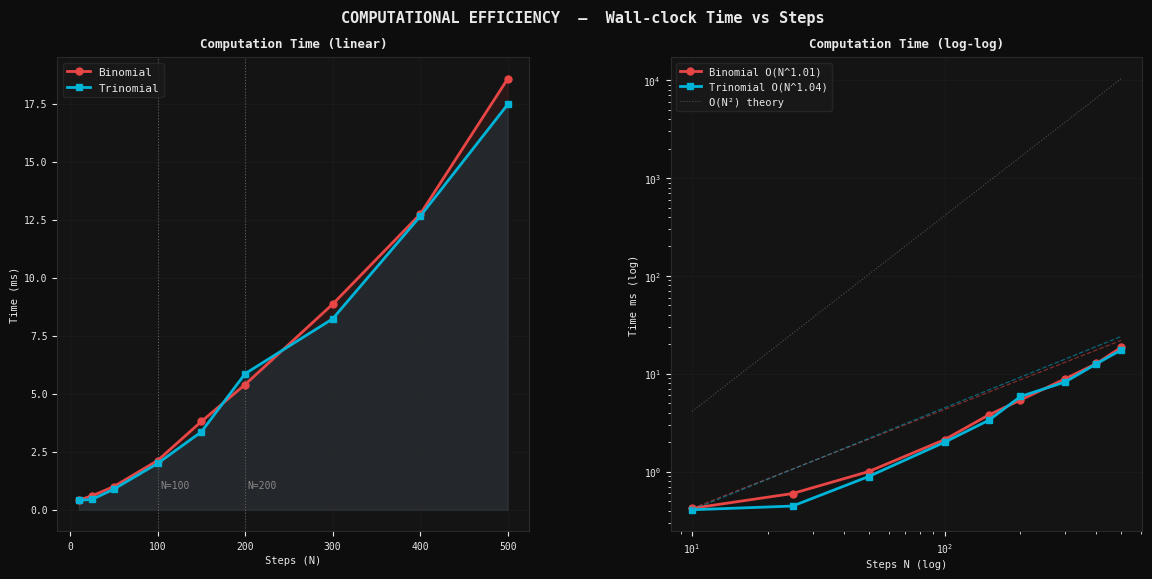

  ✓ fig5c_efficiency.png


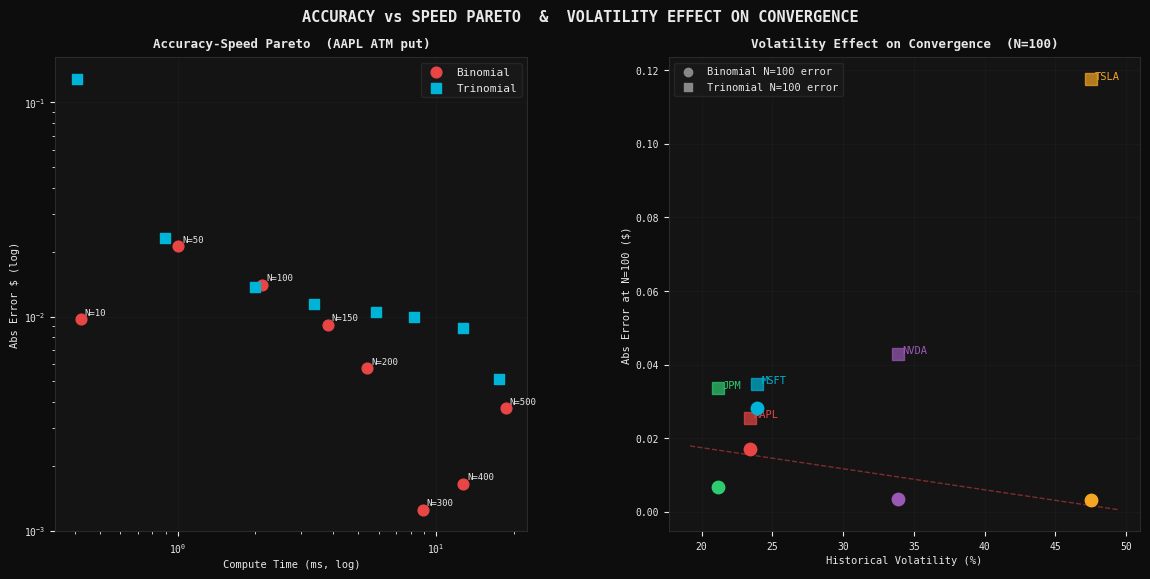

  ✓ fig5d_pareto_vol.png

  Figures saved to: outputs/figures/
    fig5a_convergence_paths.png
    fig5b_convergence_error.png
    fig5c_efficiency.png
    fig5d_pareto_vol.png


In [ ]:
import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

warnings.filterwarnings("ignore")

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR     = "/content" # In Colab, __file__ is not defined. We can set BASE_DIR to the current content directory.
CONTRACTS_IN = os.path.join(BASE_DIR, "outputs", "priced_contracts.csv")
OUT_DIR      = os.path.join(BASE_DIR, "outputs")
FIG_DIR      = os.path.join(OUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# ── Config ────────────────────────────────────────────────────────────────────
N_STEPS      = [5,10,15,20,30,40,50,75,100,125,150,175,200,250,300,400,500]
N_BENCH      = [10,25,50,100,150,200,300,400,500]
N_REF        = 1000     # high-N reference price
N_TIMING_REPS= 20       # repetitions per timing measurement

# ── Style ─────────────────────────────────────────────────────────────────────
PALETTE = {"AAPL":"#E84545","MSFT":"#00B4D8","TSLA":"#F5A623","JPM":"#2ECC71","NVDA":"#9B59B6"}
C_BIN = "#E84545"; C_TRI = "#00B4D8"; C_REF = "#F5A623"
DARK="#0D0D0D"; CARD="#141414"; GRID="#2A2A2A"; TEXT="#E8E8E8"; MUTED="#888888"

plt.rcParams.update({
    "figure.facecolor":DARK, "axes.facecolor":CARD, "axes.edgecolor":GRID,
    "axes.labelcolor":TEXT,  "axes.titlecolor":TEXT,"xtick.color":TEXT,
    "ytick.color":TEXT,      "grid.color":GRID,      "grid.linewidth":0.5,
    "text.color":TEXT,       "font.family":"monospace",
    "legend.facecolor":"#1A1A1A", "legend.edgecolor":GRID,
})


# ══════════════════════════════════════════════════════════════════════════════
#  PRICERS
# ══════════════════════════════════════════════════════════════════════════════

def _bin(S, K, T, r, sig, q, N, otype):
    if T <= 0: return max(K-S,0) if otype=="put" else max(S-K,0)
    dt=T/N; u=np.exp(sig*np.sqrt(dt)); d=1/u
    disc=np.exp(-r*dt); p=float(np.clip((np.exp((r-q)*dt)-d)/(u-d),1e-8,1-1e-8))
    j=np.arange(N+1); ST=S*(u**(N-j))*(d**j)
    V=np.maximum(K-ST,0) if otype=="put" else np.maximum(ST-K,0)
    for i in range(N-1,-1,-1):
        j=np.arange(i+1); ST=S*(u**(i-j))*(d**j)
        V=disc*(p*V[:-1]+(1-p)*V[1:])
        ex=np.maximum(K-ST,0) if otype=="put" else np.maximum(ST-K,0)
        V=np.maximum(V,ex)
    return float(V[0])


def _tri(S, K, T, r, sig, q, N, otype):
    if T <= 0: return max(K-S,0) if otype=="put" else max(S-K,0)
    lam=np.sqrt(3.0); dt=T/N; u=np.exp(lam*sig*np.sqrt(dt))
    disc=np.exp(-r*dt); nu=r-q-0.5*sig**2
    edx=np.exp(nu*dt); edx2=np.exp((2*nu+sig**2)*dt)
    denom=(u-1.)*(u**2-1.)
    if abs(denom)>1e-12:
        pu=(edx2-edx*(1+u)+u)/denom; pd_=(edx2*u-edx*(1+u)*u+u**2)/denom
    else: pu=pd_=1/6
    pm=1-pu-pd_
    if not(0<pu<1 and 0<pd_<1 and 0<pm<1): pu=pd_=1/6; pm=2/3
    total=pu+pm+pd_; pu/=total; pm/=total; pd_/=total
    states=np.arange(-N,N+1,dtype=float); ST=S*(u**states)
    V=np.maximum(K-ST,0) if otype=="put" else np.maximum(ST-K,0)
    for i in range(N-1,-1,-1):
        V=disc*(pu*V[:-2]+pm*V[1:-1]+pd_*V[2:])
        st_i=S*(u**np.arange(-i,i+1,dtype=float))
        ex=np.maximum(K-st_i,0) if otype=="put" else np.maximum(st_i-K,0)
        V=np.maximum(V,ex)
    return float(V[0])


# ══════════════════════════════════════════════════════════════════════════════
#  SELECT REPRESENTATIVE CONTRACTS
# ══════════════════════════════════════════════════════════════════════════════

def select_representatives(df: pd.DataFrame) -> pd.DataFrame:
    """
    One contract per ticker × option_type × expiry — the strike closest to spot.
    Returns a clean parameter DataFrame.
    """
    reps = []
    for (tkr, otype, expiry), grp in df.groupby(["ticker","option_type_std","expiry"]):
        S0  = grp["spot_price"].iloc[0]
        idx = (grp["strike"] - S0).abs().idxmin()
        row = grp.loc[idx]
        reps.append({
            "ticker"        : tkr,
            "option_type"   : otype,
            "expiry"        : expiry,
            "label"         : f"{tkr} {otype[:1].upper()} {expiry[-5:]}",
            "S"             : row["spot_price"],
            "K"             : row["strike"],
            "T"             : row["time_to_maturity"],
            "r"             : row["r"],
            "sig"           : row["iv_used"],
            "q"             : row["dividend_yield"],
            "market_price"  : row["market_price"],
            "historical_vol": row["historical_volatility"],
        })
    return pd.DataFrame(reps)


# ══════════════════════════════════════════════════════════════════════════════
#  CONVERGENCE CURVES
# ══════════════════════════════════════════════════════════════════════════════

def convergence_curves(rep_df: pd.DataFrame) -> list[dict]:
    """
    For each representative contract, compute price at every N in N_STEPS
    plus a reference at N_REF. Returns list of result dicts.
    """
    results = []
    n_contracts = len(rep_df)

    for ci, c in enumerate(rep_df.to_dict("records")):
        S,K,T,r,sig,q = float(c["S"]), float(c["K"]), float(c["T"]), float(c["r"]), float(c["sig"]), float(c["q"])
        otype = str(c["option_type"])

        # High-N reference
        ref_b = _bin(S, K, T, r, sig, q, N_REF, otype)
        ref_t = _tri(S, K, T, r, sig, q, N_REF, otype)

        bin_prices, tri_prices = [], []
        bin_errs,   tri_errs   = [], []

        for N in N_STEPS:
            bp = _bin(S, K, T, r, sig, q, N, otype)
            tp = _tri(S, K, T, r, sig, q, N, otype)
            bin_prices.append(bp); tri_prices.append(tp)
            bin_errs.append(abs(bp - ref_b))
            tri_errs.append(abs(tp - ref_t))

        # Oscillation: std of even-N minus odd-N prices (binomial only)
        even_p = [bin_prices[i] for i, N in enumerate(N_STEPS) if N % 2 == 0]
        odd_p  = [bin_prices[i] for i, N in enumerate(N_STEPS) if N % 2 != 0]
        osc = np.std(even_p + odd_p) if even_p and odd_p else np.nan

        # Convergence rate via log-log regression on error vs N (N>=30)
        mask = [i for i,N in enumerate(N_STEPS) if N >= 30 and bin_errs[i] > 1e-8]
        if len(mask) >= 3:
            log_N  = np.log([N_STEPS[i] for i in mask])
            log_eb = np.log([max(bin_errs[i], 1e-8) for i in mask])
            log_et = np.log([max(tri_errs[i], 1e-8) for i in mask])
            slope_b, _, rb, _, _ = linregress(log_N, log_eb)
            slope_t, _, rt, _, _ = linregress(log_N, log_et)
        else:
            slope_b = slope_t = rb = rt = np.nan

        results.append({
            "label"       : c["label"],
            "ticker"      : c["ticker"],
            "option_type" : otype,
            "expiry"      : c["expiry"],
            "S": S, "K": K, "T": T, "sig": sig, "q": q,
            "market_price": c["market_price"],
            "ref_bin"     : ref_b,
            "ref_tri"     : ref_t,
            "bin_prices"  : bin_prices,
            "tri_prices"  : tri_prices,
            "bin_errs"    : bin_errs,
            "tri_errs"    : tri_errs,
            "bin_rate"    : slope_b,   # convergence exponent (negative)
            "tri_rate"    : slope_t,
            "bin_r2"      : rb**2 if not np.isnan(rb) else np.nan,
            "tri_r2"      : rt**2 if not np.isnan(rt) else np.nan,
            "oscillation" : osc,
        })

        pct = (ci+1)/n_contracts*100
        if (ci+1) % 5 == 0 or ci == 0:
            print(f"  │  {pct:4.0f}%  {c['label']:<28}  "
                  f"ref_bin={ref_b:.4f}  rate={slope_b:.2f}")

    return results


# ══════════════════════════════════════════════════════════════════════════════
#  EFFICIENCY BENCHMARKS
# ══════════════════════════════════════════════════════════════════════════════

def timing_benchmarks(sample: dict) -> dict:
    """
    Time both pricers across N_BENCH step counts.
    sample: dict with S,K,T,r,sig,q,otype keys.
    Returns dict of {N: {bin_ms, tri_ms}}.
    """
    S,K,T,r,sig,q,otype = (sample["S"],sample["K"],sample["T"],
                            sample["r"],sample["sig"],sample["q"],
                            sample["otype"])
    bench = {}
    for N in N_BENCH:
        t0 = time.perf_counter()
        for _ in range(N_TIMING_REPS): _bin(S,K,T,r,sig,q,N,otype)
        b_ms = (time.perf_counter()-t0)/N_TIMING_REPS*1000

        t0 = time.perf_counter()
        for _ in range(N_TIMING_REPS): _tri(S,K,T,r,sig,q,N,otype)
        t_ms = (time.perf_counter()-t0)/N_TIMING_REPS*1000

        bench[N] = {"bin_ms": b_ms, "tri_ms": t_ms, "speedup": t_ms/b_ms}
    return bench


def fit_complexity(bench: dict) -> tuple:
    """Fit empirical O(N^α) scaling from timing data."""
    Ns     = np.array(N_BENCH, dtype=float)
    b_ms   = np.array([bench[N]["bin_ms"] for N in N_BENCH])
    t_ms   = np.array([bench[N]["tri_ms"] for N in N_BENCH])
    # log-log regression
    ab, _, _, _, _ = linregress(np.log(Ns), np.log(b_ms))
    at, _, _, _, _ = linregress(np.log(Ns), np.log(t_ms))
    return ab, at


# ══════════════════════════════════════════════════════════════════════════════
#  PRINT REPORT
# ══════════════════════════════════════════════════════════════════════════════

def print_report(results: list, bench: dict, alpha_b: float, alpha_t: float):
    SEP  = "═" * 78
    SEP2 = "─" * 78

    print(f"\n{SEP}")
    print(f"  MODULE 05 — CONVERGENCE & EFFICIENCY REPORT")
    print(f"  Reference N={N_REF}  |  Steps tested: {N_STEPS}")
    print(SEP)

    # ── Convergence theory ────────────────────────────────────────────────────
    print(f"\n  CONVERGENCE THEORY")
    print(f"  {SEP2}")
    print(f"  CRR Binomial  : converges at O(1/N)  with characteristic even/odd")
    print(f"                  oscillation — price alternates above/below true value")
    print(f"                  as N parity flips. Accelerated using Richardson")
    print(f"                  extrapolation or BBS/BBSR schemes.")
    print(f"  Boyle Trinomial: converges monotonically at O(1/N) but from below")
    print(f"                  (systematically underestimates until N is large).")
    print(f"                  No oscillation, but slower absolute convergence")
    print(f"                  at equal N due to coarser state-space spacing.")

    # ── Per-contract convergence rates ────────────────────────────────────────
    print(f"\n  CONVERGENCE RATES  (log-log slope of |error| vs N,  N≥30)")
    print(f"  {SEP2}")
    print(f"  Expected: slope ≈ −1.0 for O(1/N) methods")
    print()
    print(f"  {'Contract':<28} {'BinRate':>8} {'TriRate':>8} {'Bin R²':>7} {'Tri R²':>7}  {'Oscillation':>12}")
    print(f"  {'-'*73}")
    for r in results:
        print(
            f"  {r['label']:<28}"
            f"  {r['bin_rate']:>8.3f}"
            f"  {r['tri_rate']:>8.3f}"
            f"  {r['bin_r2']:>7.3f}"
            f"  {r['tri_r2']:>7.3f}"
            f"  {r['oscillation']:>12.5f}"
        )

    # Aggregate by ticker
    df_r = pd.DataFrame(results)
    print(f"\n  MEAN CONVERGENCE RATE BY TICKER")
    print(f"  {SEP2}")
    print(f"  {'Ticker':<6} {'AvgBinRate':>11} {'AvgTriRate':>11} {'AvgOsc':>10}")
    print(f"  {'-'*42}")
    for tkr, grp in df_r.groupby("ticker"):
        print(f"  {tkr:<6} {grp['bin_rate'].mean():>11.3f} {grp['tri_rate'].mean():>11.3f}"
              f" {grp['oscillation'].mean():>10.5f}")

    # ── Error at key N values ─────────────────────────────────────────────────
    print(f"\n  ERROR AT KEY STEP COUNTS  |error(N) − ref(1000)|\n  {SEP2}")
    key_Ns = [20, 50, 100, 200, 500]
    key_idx = [N_STEPS.index(N) for N in key_Ns if N in N_STEPS]
    header = f"  {'Contract':<28}" + "".join(f"{'N='+str(N_STEPS[i]):>10}" for i in key_idx)
    print(header + "   (Bin|Tri)")
    print(f"  {'-'*73}")
    for r in results[:10]:  # first 10 contracts
        row = f"  {r['label']:<28}"
        for i in key_idx:
            row += f"  {r['bin_errs'][i]:.3f}|{r['tri_errs'][i]:.3f}"
        print(row)

    # ── Timing benchmarks ─────────────────────────────────────────────────────
    print(f"\n  COMPUTATIONAL EFFICIENCY  (AAPL ATM put, {N_TIMING_REPS} reps each)\n  {SEP2}")
    print(f"  Empirical complexity:  Binomial O(N^{alpha_b:.2f})  |  Trinomial O(N^{alpha_t:.2f})")
    print(f"  Theoretical:           Both O(N²) → expected slope ≈ 2.00")
    print()
    print(f"  {'N':>6}  {'Bin (ms)':>10}  {'Tri (ms)':>10}  {'Tri/Bin':>8}  {'Bin nodes':>10}  {'Tri nodes':>10}")
    print(f"  {'-'*60}")
    for N in N_BENCH:
        b = bench[N]["bin_ms"]
        t = bench[N]["tri_ms"]
        sp = bench[N]["speedup"]
        b_nodes = N*(N+1)//2
        t_nodes = N*(2*N+1)
        print(f"  {N:>6}  {b:>10.3f}  {t:>10.3f}  {sp:>8.2f}x  {b_nodes:>10,}  {t_nodes:>10,}")

    # ── Accuracy vs speed Pareto ───────────────────────────────────────────────
    print(f"\n  ACCURACY vs SPEED  —  RECOMMENDED N FOR PRODUCTION\n  {SEP2}")
    # For AAPL put (first put result)
    put_res = next(r for r in results if r["option_type"]=="put" and r["ticker"]=="AAPL")
    print(f"  Contract: {put_res['label']}  ref={put_res['ref_bin']:.5f}")
    print()
    print(f"  {'N':>5}  {'Bin price':>10}  {'Abs err':>9}  {'Bin ms':>8}  {'Err×ms':>9}  Recommendation")
    print(f"  {'-'*68}")
    for i, N in enumerate(N_STEPS):
        if N not in N_BENCH: continue
        b_ms  = bench[N]["bin_ms"]
        b_err = put_res["bin_errs"][i]
        rec   = ""
        if N == 100:  rec = "← fast/OK"
        elif N == 200: rec = "← balanced ✓"
        elif N == 500: rec = "← high precision"
        print(f"  {N:>5}  {put_res['bin_prices'][i]:>10.5f}"
              f"  {b_err:>9.5f}  {b_ms:>8.3f}  {b_err*b_ms:>9.6f}  {rec}")

    print(f"\n{SEP}\n")


# ══════════════════════════════════════════════════════════════════════════════
#  VISUALISATION
# ══════════════════════════════════════════════════════════════════════════════

def frame(ax, title, xlabel=None, ylabel=None, fs=9):
    ax.set_title(title, fontsize=fs, fontweight="bold", pad=7, color=TEXT)
    if xlabel: ax.set_xlabel(xlabel, fontsize=7.5, labelpad=3)
    if ylabel: ax.set_ylabel(ylabel, fontsize=7.5, labelpad=3)
    ax.grid(True, alpha=0.35); ax.tick_params(labelsize=7)


def plot_all(results: list, bench: dict, alpha_b: float, alpha_t: float):

    # ── Figure 5a: Convergence price paths  (5 tickers, put only, longest TTM) ─
    focus = [r for r in results
             if r["option_type"]=="put"
             and r["expiry"]==max(r2["expiry"] for r2 in results if r2["ticker"]==r["ticker"])]
    focus_sorted = sorted(focus, key=lambda r: r["ticker"])

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle("CONVERGENCE  —  Price Path vs N Steps  |  American Put  (longest expiry)",
                 fontsize=11, fontweight="bold", color=TEXT, y=0.98)
    plt.subplots_adjust(hspace=0.40, wspace=0.30, top=0.93)

    for idx, r in enumerate(focus_sorted):
        ax  = axes.flatten()[idx]
        col = PALETTE[r["ticker"]]

        ax.plot(N_STEPS, r["bin_prices"], color=C_BIN, lw=1.8, marker="o",
                ms=3, label="Binomial")
        ax.plot(N_STEPS, r["tri_prices"], color=C_TRI, lw=1.8, marker="s",
                ms=3, label="Trinomial")
        ax.axhline(r["ref_bin"], color=C_BIN,  lw=0.8, ls="--", alpha=0.5,
                   label=f"Bin ref={r['ref_bin']:.3f}")
        ax.axhline(r["ref_tri"], color=C_TRI,  lw=0.8, ls="--", alpha=0.5,
                   label=f"Tri ref={r['ref_tri']:.3f}")
        ax.axhline(r["market_price"], color=C_REF, lw=0.9, ls=":",
                   alpha=0.7, label=f"Market={r['market_price']:.3f}")

        frame(ax,
              f"{r['label']}  (σ={r['sig']*100:.0f}%  q={r['q']*100:.2f}%)",
              "Steps (N)", "Price ($)")
        ax.legend(fontsize=6, loc="lower right")

    if len(focus_sorted) < 6: axes.flatten()[-1].set_visible(False)
    fig.savefig(os.path.join(FIG_DIR, "fig5a_convergence_paths.png"),
                dpi=180, bbox_inches="tight", facecolor=DARK)
    plt.show(); print("  ✓ fig5a_convergence_paths.png")

    # ── Figure 5b: Error convergence (log-log) ─────────────────────────────────
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle("CONVERGENCE ERROR  |error(N) − ref(1000)|  —  Log-Log Scale",
                 fontsize=11, fontweight="bold", color=TEXT, y=0.98)
    plt.subplots_adjust(hspace=0.40, wspace=0.30, top=0.93)

    for idx, r in enumerate(focus_sorted):
        ax  = axes.flatten()[idx]

        # Plot errors
        ax.loglog(N_STEPS, [max(e, 1e-6) for e in r["bin_errs"]],
                  color=C_BIN, lw=1.8, marker="o", ms=3, label="Binomial")
        ax.loglog(N_STEPS, [max(e, 1e-6) for e in r["tri_errs"]],
                  color=C_TRI, lw=1.8, marker="s", ms=3, label="Trinomial")

        # Reference O(1/N) line
        N_arr = np.array(N_STEPS, dtype=float)
        scale = max(r["bin_errs"][:3]) * N_STEPS[0]
        ax.loglog(N_arr, scale / N_arr, color=MUTED, lw=0.9, ls="--",
                  alpha=0.6, label="O(1/N)")

        rate_str = (f"Bin α={r['bin_rate']:.2f}  "
                    f"Tri α={r['tri_rate']:.2f}")
        ax.text(0.05, 0.08, rate_str, transform=ax.transAxes,
                fontsize=7, color=TEXT, alpha=0.8)

        frame(ax,
              f"{r['label']}  error log-log",
              "Steps N (log)", "|error| $ (log)")
        ax.legend(fontsize=7)

    if len(focus_sorted) < 6: axes.flatten()[-1].set_visible(False)
    fig.savefig(os.path.join(FIG_DIR, "fig5b_convergence_error.png"),
                dpi=180, bbox_inches="tight", facecolor=DARK)
    plt.show(); print("  ✓ fig5b_convergence_error.png")

    # ── Figure 5c: Efficiency — time vs N ──────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle("COMPUTATIONAL EFFICIENCY  —  Wall-clock Time vs Steps",
                 fontsize=11, fontweight="bold", color=TEXT, y=0.98)
    plt.subplots_adjust(wspace=0.30, top=0.90)

    Ns    = np.array(N_BENCH, dtype=float)
    b_ms  = [bench[N]["bin_ms"] for N in N_BENCH]
    t_ms  = [bench[N]["tri_ms"] for N in N_BENCH]

    # Linear scale
    ax = axes[0]
    ax.plot(N_BENCH, b_ms, color=C_BIN, lw=2.0, marker="o", ms=5, label="Binomial")
    ax.plot(N_BENCH, t_ms, color=C_TRI, lw=2.0, marker="s", ms=5, label="Trinomial")
    ax.fill_between(N_BENCH, b_ms, alpha=0.10, color=C_BIN)
    ax.fill_between(N_BENCH, t_ms, alpha=0.10, color=C_TRI)
    for N in [100, 200]:
        ax.axvline(N, color=MUTED, lw=0.8, ls=":", alpha=0.6)
        ax.text(N+3, max(b_ms)*0.05, f"N={N}", fontsize=7, color=MUTED)
    frame(ax, "Computation Time (linear)", "Steps (N)", "Time (ms)")
    ax.legend(fontsize=8)

    # Log-log scale with O(N²) fit line
    ax = axes[1]
    ax.loglog(Ns, b_ms, color=C_BIN, lw=2.0, marker="o", ms=5, label=f"Binomial O(N^{alpha_b:.2f})")
    ax.loglog(Ns, t_ms, color=C_TRI, lw=2.0, marker="s", ms=5, label=f"Trinomial O(N^{alpha_t:.2f})")
    # Fitted lines
    c_b = np.exp(np.log(b_ms[0]) - alpha_b * np.log(Ns[0]))
    c_t = np.exp(np.log(t_ms[0]) - alpha_t * np.log(Ns[0]))
    N_fit = np.linspace(Ns.min(), Ns.max(), 100)
    ax.loglog(N_fit, c_b * N_fit**alpha_b, color=C_BIN, lw=0.9, ls="--", alpha=0.5)
    ax.loglog(N_fit, c_t * N_fit**alpha_t, color=C_TRI, lw=0.9, ls="--", alpha=0.5)
    ax.loglog(N_fit, c_b * N_fit**2,       color=MUTED, lw=0.8, ls=":",  alpha=0.5,
              label="O(N²) theory")
    frame(ax, "Computation Time (log-log)", "Steps N (log)", "Time ms (log)")
    ax.legend(fontsize=7.5)

    fig.savefig(os.path.join(FIG_DIR, "fig5c_efficiency.png"),
                dpi=180, bbox_inches="tight", facecolor=DARK)
    plt.show(); print("  ✓ fig5c_efficiency.png")

    # ── Figure 5d: Accuracy-Speed Pareto + vol effect ──────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle("ACCURACY vs SPEED PARETO  &  VOLATILITY EFFECT ON CONVERGENCE",
                 fontsize=11, fontweight="bold", color=TEXT, y=0.98)
    plt.subplots_adjust(wspace=0.30, top=0.90)

    # Pareto frontier: error vs compute time (Binomial, AAPL put)
    ax = axes[0]
    put_r = next(r for r in results if r["option_type"]=="put" and r["ticker"]=="AAPL")
    pareto_x, pareto_y = [], []
    for i, N in enumerate(N_STEPS):
        if N in N_BENCH:
            pareto_x.append(bench[N]["bin_ms"])
            pareto_y.append(put_r["bin_errs"][i])

    ax.scatter(pareto_x, pareto_y, color=C_BIN, s=60, zorder=5, label="Binomial")
    bench_in_steps = [N for N in N_BENCH if N in N_STEPS]
    for i, N in enumerate(bench_in_steps):
        if i < len(pareto_x):
            ax.annotate(f"N={N}", xy=(pareto_x[i], pareto_y[i]),
                        xytext=(3, 3), textcoords="offset points",
                        fontsize=6.5, color=TEXT)

    # Trinomial
    pareto_xt, pareto_yt = [], []
    for i, N in enumerate(N_STEPS):
        if N in N_BENCH:
            pareto_xt.append(bench[N]["tri_ms"])
            pareto_yt.append(put_r["tri_errs"][i])
    ax.scatter(pareto_xt, pareto_yt, color=C_TRI, s=60, marker="s",
               zorder=5, label="Trinomial")

    ax.set_xscale("log"); ax.set_yscale("log")
    frame(ax, "Accuracy-Speed Pareto  (AAPL ATM put)",
          "Compute Time (ms, log)", "Abs Error $ (log)")
    ax.legend(fontsize=8)

    # Vol effect on convergence speed: error at N=100 vs sigma
    ax = axes[1]
    vols_list, err_bin_100, err_tri_100 = [], [], []
    for r in focus_sorted:
        vols_list.append(r["sig"] * 100)
        i100 = N_STEPS.index(100) if 100 in N_STEPS else -1
        if i100 >= 0:
            err_bin_100.append(r["bin_errs"][i100])
            err_tri_100.append(r["tri_errs"][i100])

    for tkr, v, eb, et in zip([r["ticker"] for r in focus_sorted],
                               vols_list, err_bin_100, err_tri_100):
        col = PALETTE[tkr]
        ax.scatter(v, eb, color=col, s=80, marker="o", zorder=5)
        ax.scatter(v, et, color=col, s=80, marker="s", zorder=5, alpha=0.7)
        ax.annotate(tkr, xy=(v+0.3, max(eb, et)), fontsize=7.5, color=col)

    ax.scatter([], [], color=MUTED, marker="o", label="Binomial N=100 error")
    ax.scatter([], [], color=MUTED, marker="s", label="Trinomial N=100 error")

    # Trend line
    if len(vols_list) >= 3:
        z = np.polyfit(vols_list, err_bin_100, 1)
        xl = np.linspace(min(vols_list)-2, max(vols_list)+2, 100)
        ax.plot(xl, np.polyval(z, xl), color=C_BIN, lw=1.0, ls="--", alpha=0.5)

    frame(ax, "Volatility Effect on Convergence  (N=100)",
          "Historical Volatility (%)", "Abs Error at N=100 ($)")
    ax.legend(fontsize=7.5)

    fig.savefig(os.path.join(FIG_DIR, "fig5d_pareto_vol.png"),
                dpi=180, bbox_inches="tight", facecolor=DARK)
    plt.show(); print("  ✓ fig5d_pareto_vol.png")


# ══════════════════════════════════════════════════════════════════════════════
#  MAIN
# ══════════════════════════════════════════════════════════════════════════════

def run():
    print("\n  ┌─ MODULE 05: CONVERGENCE & EFFICIENCY ──────────────────────────────┐")

    # 1. Load
    print("  │  [1/5] Loading priced contracts...")
    df = pd.read_csv(CONTRACTS_IN)
    print(f"  │        {len(df):,} contracts  |  {df['ticker'].nunique()} tickers")

    # 2. Select representatives
    print("  │  [2/5] Selecting ATM representative contracts...")
    rep_df = select_representatives(df)
    print(f"  │        {len(rep_df)} contracts selected  "
          f"(tickers × expiries × types)")

    # 3. Convergence curves
    print(f"  │  [3/5] Computing convergence curves  "
          f"(N={N_STEPS[0]}→{N_STEPS[-1]}, ref={N_REF})...")
    results = convergence_curves(rep_df)
    print(f"  │        Done — {len(results)} curves computed")

    # 4. Timing benchmarks
    print(f"  │  [4/5] Running efficiency benchmarks  "
          f"({N_TIMING_REPS} reps × {len(N_BENCH)} step counts)...")
    aapl_put = rep_df[(rep_df["ticker"]=="AAPL") &
                      (rep_df["option_type"]=="put")].iloc[-1].to_dict()
    sample = {"S":float(aapl_put["S"]),"K":float(aapl_put["K"]),"T":float(aapl_put["T"]),
              "r":float(aapl_put["r"]),"sig":float(aapl_put["sig"]),"q":float(aapl_put["q"]),"otype":"put"}
    bench  = timing_benchmarks(sample)
    alpha_b, alpha_t = fit_complexity(bench)
    print(f"  │        Binomial O(N^{alpha_b:.2f})  |  Trinomial O(N^{alpha_t:.2f})")

    # 5. Save CSV
    print("  │  [5/5] Saving convergence_results.csv...")
    rows = []
    for r in results:
        for i, N in enumerate(N_STEPS):
            rows.append({
                "label"      : r["label"],
                "ticker"     : r["ticker"],
                "option_type": r["option_type"],
                "expiry"     : r["expiry"],
                "N"          : N,
                "bin_price"  : r["bin_prices"][i],
                "tri_price"  : r["tri_prices"][i],
                "bin_err"    : r["bin_errs"][i],
                "tri_err"    : r["tri_errs"][i],
                "ref_bin"    : r["ref_bin"],
                "ref_tri"    : r["ref_tri"],
                "market"     : r["market_price"],
            })
    conv_df = pd.DataFrame(rows)
    conv_df.to_csv(os.path.join(OUT_DIR, "convergence_results.csv"), index=False)
    print(f"  │        convergence_results.csv  ({len(conv_df)} rows)")
    print("  └────────────────────────────────────────────────────────────────────────┘\n")

    print_report(results, bench, alpha_b, alpha_t)

    print("  Generating figures...")
    plot_all(results, bench, alpha_b, alpha_t)

    print(f"\n  Figures saved to: outputs/figures/")
    print(f"    fig5a_convergence_paths.png")
    print(f"    fig5b_convergence_error.png")
    print(f"    fig5c_efficiency.png")
    print(f"    fig5d_pareto_vol.png")

    return results, bench


if __name__ == "__main__":
    results, bench = run()


  ┌─ MODULE 06: EFFICIENCY BENCHMARKS ─────────────────────────────────┐
  │  [1/6] Loading contracts...
  │        474 contracts  |  5 tickers
  │  [2/6] Running full-batch timing  (N=[50, 100, 200, 300])...
  │    N= 50 ... Bin=570ms  Tri=507ms
  │    N=100 ... Bin=1990ms  Tri=1447ms
  │    N=200 ... Bin=2572ms  Tri=2400ms
  │    N=300 ... Bin=4409ms  Tri=5562ms
  │  [3/6] Richardson extrapolation analysis  (N=[25, 50, 100, 200])...
  │        20 measurements computed
  │  [4/6] Computing optimal-N per ticker  (thresholds=[0.05, 0.01, 0.005])...
  │        10 ticker × type combinations
  │  [5/6] Estimating memory footprint...
  │  [6/6] Saving efficiency_report.csv...
  │        efficiency_report.csv  ✓
  │        richardson_analysis.csv  ✓
  │        optimal_n.csv  ✓
  └────────────────────────────────────────────────────────────────────────┘


══════════════════════════════════════════════════════════════════════════════
  MODULE 06 — EFFICIENCY BENCHMARKS REPORT
════════════════

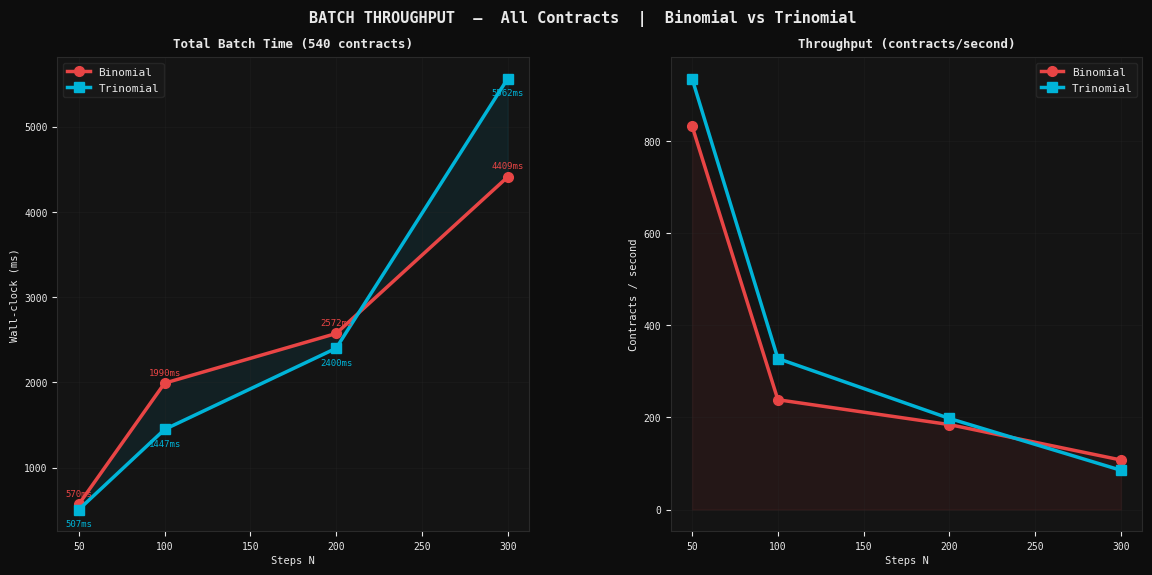

  ✓ fig6a_batch_throughput.png


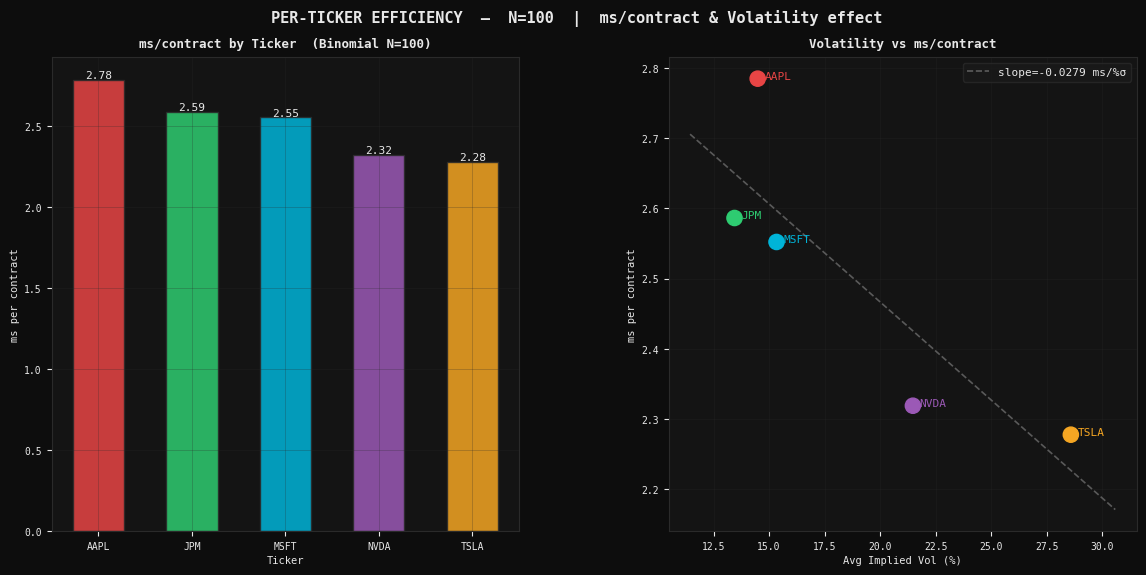

  ✓ fig6b_ticker_efficiency.png


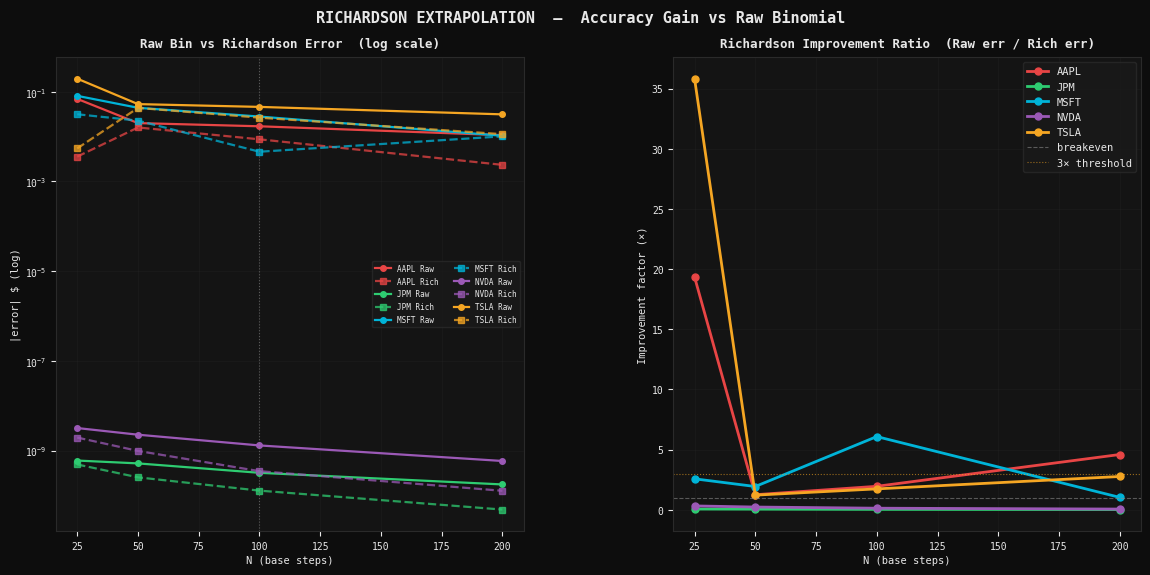

  ✓ fig6c_richardson.png


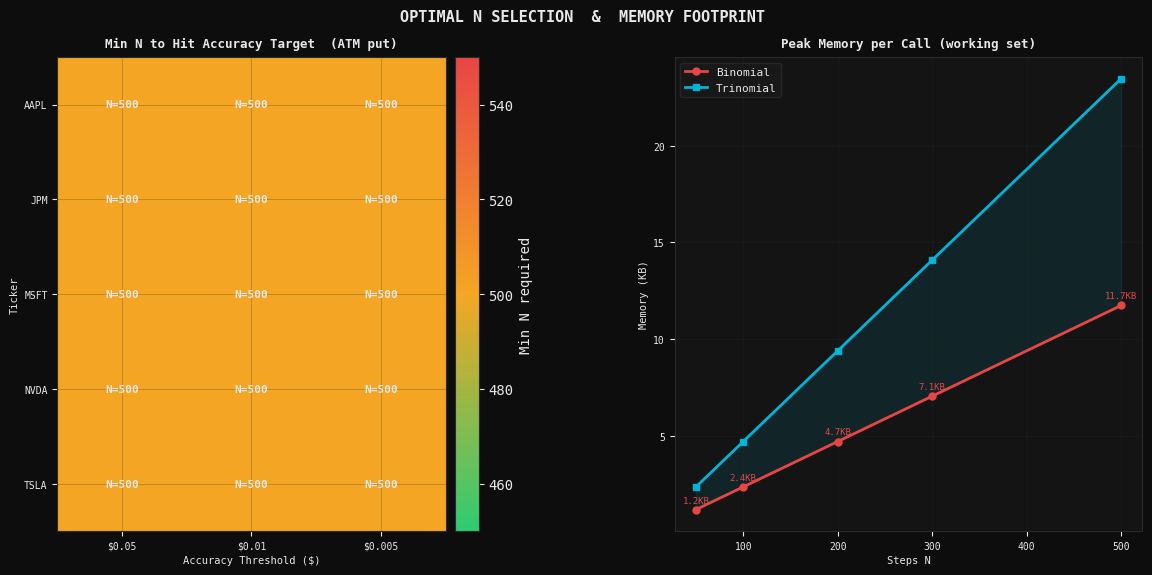

  ✓ fig6d_optimal_n_memory.png

  Figures saved to: outputs/figures/
    fig6a_batch_throughput.png
    fig6b_ticker_efficiency.png
    fig6c_richardson.png
    fig6d_optimal_n_memory.png


In [ ]:
import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

warnings.filterwarnings("ignore")

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR     = "/content" # In Colab, __file__ is not defined. We can set BASE_DIR to the current content directory.
CONTRACTS_IN = os.path.join(BASE_DIR, "outputs", "priced_contracts.csv")
CONV_IN      = os.path.join(BASE_DIR, "outputs", "convergence_results.csv")
OUT_DIR      = os.path.join(BASE_DIR, "outputs")
FIG_DIR      = os.path.join(OUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# ── Config ────────────────────────────────────────────────────────────────────
BATCH_NS     = [50, 100, 200, 300]      # N values for batch timing
RICH_NS      = [25, 50, 100, 200]       # N values for Richardson test
N_REF        = 1000                     # reference price
N_TIMING     = 8                        # repetitions per single-contract timing
ACC_TARGETS  = [0.05, 0.01, 0.005]     # price accuracy thresholds ($)

# ── Style ─────────────────────────────────────────────────────────────────────
PALETTE = {"AAPL":"#E84545","MSFT":"#00B4D8","TSLA":"#F5A623","JPM":"#2ECC71","NVDA":"#9B59B6"}
C_BIN="#E84545"; C_TRI="#00B4D8"; C_RICH="#F5A623"
DARK="#0D0D0D"; CARD="#141414"; GRID="#2A2A2A"; TEXT="#E8E8E8"; MUTED="#888888"

plt.rcParams.update({
    "figure.facecolor":DARK, "axes.facecolor":CARD, "axes.edgecolor":GRID,
    "axes.labelcolor":TEXT,  "axes.titlecolor":TEXT, "xtick.color":TEXT,
    "ytick.color":TEXT,      "grid.color":GRID,      "grid.linewidth":0.5,
    "text.color":TEXT,       "font.family":"monospace",
    "legend.facecolor":"#1A1A1A", "legend.edgecolor":GRID,
})


# ══════════════════════════════════════════════════════════════════════════════
#  PRICERS
# ══════════════════════════════════════════════════════════════════════════════

def _bin(S, K, T, r, sig, q, N, otype):
    if T <= 0: return max(K-S, 0) if otype == "put" else max(S-K, 0)
    dt = T/N; u = np.exp(sig*np.sqrt(dt)); d = 1/u
    disc = np.exp(-r*dt)
    p = float(np.clip((np.exp((r-q)*dt)-d)/(u-d), 1e-8, 1-1e-8))
    j = np.arange(N+1); ST = S*(u**(N-j))*(d**j)
    V = np.maximum(K-ST, 0) if otype == "put" else np.maximum(ST-K, 0)
    for i in range(N-1, -1, -1):
        j = np.arange(i+1); ST = S*(u**(i-j))*(d**j)
        V = disc*(p*V[:-1]+(1-p)*V[1:])
        ex = np.maximum(K-ST, 0) if otype=="put" else np.maximum(ST-K, 0)
        V = np.maximum(V, ex)
    return float(V[0])


def _tri(S, K, T, r, sig, q, N, otype):
    if T <= 0: return max(K-S, 0) if otype == "put" else max(S-K, 0)
    lam = np.sqrt(3.0); dt = T/N; u = np.exp(lam*sig*np.sqrt(dt))
    disc = np.exp(-r*dt); nu = r-q-0.5*sig**2
    edx = np.exp(nu*dt); edx2 = np.exp((2*nu+sig**2)*dt)
    denom = (u-1.)*(u**2-1.)
    if abs(denom) > 1e-12:
        pu = (edx2-edx*(1+u)+u)/denom; pd_ = (edx2*u-edx*(1+u)*u+u**2)/denom
    else:
        pu = pd_ = 1/6
    pm = 1-pu-pd_
    if not (0 < pu < 1 and 0 < pd_ < 1 and 0 < pm < 1):
        pu = pd_ = 1/6; pm = 2/3
    total = pu+pm+pd_; pu /= total; pm /= total; pd_ /= total
    states = np.arange(-N, N+1, dtype=float); ST = S*(u**states)
    V = np.maximum(K-ST, 0) if otype == "put" else np.maximum(ST-K, 0)
    for i in range(N-1, -1, -1):
        V = disc*(pu*V[:-2]+pm*V[1:-1]+pd_*V[2:])
        st_i = S*(u**np.arange(-i, i+1, dtype=float))
        ex = np.maximum(K-st_i, 0) if otype=="put" else np.maximum(st_i-K, 0)
        V = np.maximum(V, ex)
    return float(V[0])


def _richardson(S, K, T, r, sig, q, N, otype):
    """
    Richardson-extrapolated Binomial price.
    Uses p(N) and p(2N) to cancel the leading O(1/N) error term:
        p* ≈ (4·p(2N) − p(N)) / 3
    Cost: N + 2N = 3N work (50% more than brute 2N alone).
    """
    p1 = _bin(S, K, T, r, sig, q, N,   otype)
    p2 = _bin(S, K, T, r, sig, q, 2*N, otype)
    return (4*p2 - p1) / 3


# ══════════════════════════════════════════════════════════════════════════════
#  1. FULL-BATCH TIMING
# ══════════════════════════════════════════════════════════════════════════════

def batch_timing(df: pd.DataFrame) -> dict:
    """
    Time binomial and trinomial on the full contract set at each N in BATCH_NS.
    Returns nested dict: results[N] = {total_bin_ms, total_tri_ms,
                                       per_contract_bin_ms, per_contract_tri_ms,
                                       ticker_breakdown, moneyness_breakdown}
    """
    results = {}
    n_contracts = len(df)

    for N in BATCH_NS:
        print(f"  │    N={N:3d} ...", end=" ", flush=True)

        # ── Full-batch Binomial ──────────────────────────────────────────────
        t0 = time.perf_counter()
        for _, row in df.iterrows():
            _bin(float(row.spot_price), float(row.strike),
                 float(row.time_to_maturity), float(row.r),
                 float(row.iv_used), float(row.dividend_yield),
                 N, str(row.option_type_std))
        bin_total_ms = (time.perf_counter()-t0)*1000

        # ── Full-batch Trinomial ─────────────────────────────────────────────
        t0 = time.perf_counter()
        for _, row in df.iterrows():
            _tri(float(row.spot_price), float(row.strike),
                 float(row.time_to_maturity), float(row.r),
                 float(row.iv_used), float(row.dividend_yield),
                 N, str(row.option_type_std))
        tri_total_ms = (time.perf_counter()-t0)*1000

        print(f"Bin={bin_total_ms:.0f}ms  Tri={tri_total_ms:.0f}ms", flush=True)

        # ── Per-ticker breakdown (Binomial) ──────────────────────────────────
        ticker_bd = {}
        for tkr, grp in df.groupby("ticker"):
            t0 = time.perf_counter()
            for _, row in grp.iterrows():
                _bin(float(row.spot_price), float(row.strike),
                     float(row.time_to_maturity), float(row.r),
                     float(row.iv_used), float(row.dividend_yield),
                     N, str(row.option_type_std))
            ticker_bd[tkr] = {
                "ms"         : (time.perf_counter()-t0)*1000,
                "n"          : len(grp),
                "avg_sig"    : grp["iv_used"].mean(),
                "avg_ms_per" : (time.perf_counter()-t0)*1000 / len(grp),
            }
            # Fix: recompute avg_ms_per correctly
            t0 = time.perf_counter()
            for _, row in grp.iterrows():
                _bin(float(row.spot_price), float(row.strike),
                     float(row.time_to_maturity), float(row.r),
                     float(row.iv_used), float(row.dividend_yield),
                     N, str(row.option_type_std))
            ticker_bd[tkr]["ms"]          = (time.perf_counter()-t0)*1000
            ticker_bd[tkr]["avg_ms_per"]  = ticker_bd[tkr]["ms"] / len(grp)

        # ── Per-moneyness breakdown ──────────────────────────────────────────
        money_bd = {}
        for money, grp in df.groupby("moneyness_label"):
            t0 = time.perf_counter()
            for _, row in grp.iterrows():
                _bin(float(row.spot_price), float(row.strike),
                     float(row.time_to_maturity), float(row.r),
                     float(row.iv_used), float(row.dividend_yield),
                     N, str(row.option_type_std))
            money_bd[money] = {
                "ms"         : (time.perf_counter()-t0)*1000,
                "n"          : len(grp),
                "avg_iv"     : grp["iv_used"].mean(),
                "avg_ms_per" : (time.perf_counter()-t0)*1000 / len(grp),
            }

        results[N] = {
            "bin_total_ms"      : bin_total_ms,
            "tri_total_ms"      : tri_total_ms,
            "bin_per_ms"        : bin_total_ms / n_contracts,
            "tri_per_ms"        : tri_total_ms / n_contracts,
            "bin_throughput"    : n_contracts / (bin_total_ms/1000),
            "tri_throughput"    : n_contracts / (tri_total_ms/1000),
            "speedup_tri_bin"   : tri_total_ms / bin_total_ms,
            "ticker_bd"         : ticker_bd,
            "money_bd"          : money_bd,
        }

    return results


# ══════════════════════════════════════════════════════════════════════════════
#  2. RICHARDSON EXTRAPOLATION ANALYSIS
# ══════════════════════════════════════════════════════════════════════════════

def richardson_analysis(df: pd.DataFrame) -> list[dict]:
    """
    For each ticker's ATM put (longest TTM), compare:
      raw Binomial(N), Richardson(N), Binomial(2N), Binomial(3N)
    at equal or comparable compute cost.
    """
    records = []
    # One ATM put per ticker — longest TTM
    atm_puts = (df[(df["moneyness_label"]=="ATM") & (df["option_type_std"]=="put")]
                .sort_values("time_to_maturity", ascending=False)
                .groupby("ticker")
                .first()
                .reset_index())

    for _, row in atm_puts.iterrows():
        S, K   = float(row.spot_price), float(row.strike)
        T, r   = float(row.time_to_maturity), float(row.r)
        sig, q = float(row.iv_used), float(row.dividend_yield)
        tkr    = row.ticker

        ref = _bin(S, K, T, r, sig, q, N_REF, "put")

        for N in RICH_NS:
            # Raw Binomial(N)
            t0 = time.perf_counter()
            for _ in range(N_TIMING): _bin(S, K, T, r, sig, q, N, "put")
            bin_ms = (time.perf_counter()-t0)/N_TIMING*1000
            bin_p  = _bin(S, K, T, r, sig, q, N, "put")

            # Raw Binomial(2N) — double the steps
            t0 = time.perf_counter()
            for _ in range(N_TIMING): _bin(S, K, T, r, sig, q, 2*N, "put")
            bin2N_ms = (time.perf_counter()-t0)/N_TIMING*1000
            bin2N_p  = _bin(S, K, T, r, sig, q, 2*N, "put")

            # Richardson(N) — costs N + 2N work
            t0 = time.perf_counter()
            for _ in range(N_TIMING): _richardson(S, K, T, r, sig, q, N, "put")
            rich_ms = (time.perf_counter()-t0)/N_TIMING*1000
            rich_p  = _richardson(S, K, T, r, sig, q, N, "put")

            records.append({
                "ticker"       : tkr,
                "N"            : N,
                "sig"          : sig,
                "ref"          : ref,
                "bin_price"    : bin_p,
                "bin2N_price"  : bin2N_p,
                "rich_price"   : rich_p,
                "bin_err"      : abs(bin_p  - ref),
                "bin2N_err"    : abs(bin2N_p - ref),
                "rich_err"     : abs(rich_p - ref),
                "bin_ms"       : bin_ms,
                "bin2N_ms"     : bin2N_ms,
                "rich_ms"      : rich_ms,
                # Efficiency: accuracy per ms
                "bin_eff"      : 1/(abs(bin_p-ref)+1e-8)  / bin_ms,
                "rich_eff"     : 1/(abs(rich_p-ref)+1e-8) / rich_ms,
                "improvement"  : abs(bin_p-ref) / max(abs(rich_p-ref), 1e-8),
                "rich_vs_2N"   : abs(bin2N_p-ref) / max(abs(rich_p-ref), 1e-8),
            })

    return records


# ══════════════════════════════════════════════════════════════════════════════
#  3. OPTIMAL-N RECOMMENDATION PER TICKER
# ══════════════════════════════════════════════════════════════════════════════

def optimal_n_analysis(df: pd.DataFrame) -> pd.DataFrame:
    """
    For each ticker × option_type, find the minimum N that achieves
    each accuracy threshold in ACC_TARGETS.
    Uses ATM contracts (most representative) and averages over expiries.
    """
    N_candidates = [10,20,30,50,75,100,150,200,300,400,500]
    rows = []

    for (tkr, otype), grp in df.groupby(["ticker","option_type_std"]):
        atm = grp[grp["moneyness_label"]=="ATM"]
        if atm.empty: continue
        # Use one representative: longest TTM, ATM
        rep = atm.sort_values("time_to_maturity").iloc[-1]
        S, K   = float(rep.spot_price), float(rep.strike)
        T, r   = float(rep.time_to_maturity), float(rep.r)
        sig, q = float(rep.iv_used), float(rep.dividend_yield)

        ref   = _bin(S, K, T, r, sig, q, N_REF, otype)
        row   = {"ticker": tkr, "option_type": otype, "sig": sig, "q": q,
                 "ref_price": ref}

        for thr in ACC_TARGETS:
            min_N = None
            for N in N_candidates:
                p = _bin(S, K, T, r, sig, q, N, otype)
                if abs(p - ref) <= thr:
                    min_N = N
                    break
            row[f"N_for_{thr:.3f}"] = min_N if min_N else ">500"

        # Time at the recommended N (N_for_0.01)
        rec_N = row.get("N_for_0.010", 200)
        if isinstance(rec_N, int):
            t0 = time.perf_counter()
            for _ in range(N_TIMING): _bin(S, K, T, r, sig, q, rec_N, otype)
            row["rec_ms"] = (time.perf_counter()-t0)/N_TIMING*1000
        else:
            row["rec_ms"] = np.nan

        rows.append(row)

    return pd.DataFrame(rows)


# ══════════════════════════════════════════════════════════════════════════════
#  4. MEMORY FOOTPRINT ESTIMATE
# ══════════════════════════════════════════════════════════════════════════════

def memory_footprint(N_list: list) -> dict:
    """
    Estimate peak memory usage per pricer call.
    Binomial: peak array size = N+1 floats (one price vector)
    Trinomial: peak array size = 2N+1 floats (one price vector)
    Both use 8 bytes per float64.
    """
    mem = {}
    for N in N_list:
        bin_peak_kb  = (N+1)   * 8 / 1024
        tri_peak_kb  = (2*N+1) * 8 / 1024
        # Plus the ST array (same size) and temporary ex array
        bin_total_kb = bin_peak_kb  * 3
        tri_total_kb = tri_peak_kb  * 3
        mem[N] = {
            "bin_kb" : bin_total_kb,
            "tri_kb" : tri_total_kb,
            "ratio"  : tri_total_kb / bin_total_kb,
        }
    return mem


# ══════════════════════════════════════════════════════════════════════════════
#  PRINT REPORT
# ══════════════════════════════════════════════════════════════════════════════

def print_report(batch: dict, rich: list, opt_n: pd.DataFrame, mem: dict):
    SEP  = "═" * 78
    SEP2 = "─" * 78

    print(f"\n{SEP}")
    print(f"  MODULE 06 — EFFICIENCY BENCHMARKS REPORT")
    print(SEP)

    # ── Batch timing overview ─────────────────────────────────────────────────
    print(f"\n  FULL-BATCH TIMING  ({len(opt_n)} contracts per run)")
    print(f"  {SEP2}")
    print(f"  {'N':>5}  {'Bin Total':>10}  {'Tri Total':>10}  "
          f"{'Bin/ctr':>9}  {'Tri/ctr':>9}  "
          f"{'Bin ctr/s':>10}  {'Tri ctr/s':>10}  {'Tri/Bin':>8}")
    print(f"  {'-'*76}")
    for N in BATCH_NS:
        b = batch[N]
        print(
            f"  {N:>5}  {b['bin_total_ms']:>10.0f}ms  {b['tri_total_ms']:>10.0f}ms"
            f"  {b['bin_per_ms']:>8.2f}ms  {b['tri_per_ms']:>8.2f}ms"
            f"  {b['bin_throughput']:>10.0f}  {b['tri_throughput']:>10.0f}"
            f"  {b['speedup_tri_bin']:>7.2f}x"
        )

    # ── Per-ticker breakdown ──────────────────────────────────────────────────
    print(f"\n  PER-TICKER THROUGHPUT  (Binomial, N=100)")
    print(f"  {SEP2}")
    print(f"  {'Ticker':<6}  {'n':>4}  {'Total ms':>9}  {'ms/ctr':>8}  "
          f"{'ctr/s':>8}  {'avg σ':>7}  Observation")
    print(f"  {'-'*62}")
    tkr_bd = batch[100]["ticker_bd"]
    for tkr in sorted(tkr_bd):
        b  = tkr_bd[tkr]
        ms = b["ms"]
        n  = b["n"]
        ms_c = ms / n
        cps  = n / (ms/1000)
        sig  = b["avg_sig"]*100
        obs  = "fastest" if ms_c == min(x["ms"]/x["n"] for x in tkr_bd.values()) else \
               "slowest" if ms_c == max(x["ms"]/x["n"] for x in tkr_bd.values()) else ""
        print(f"  {tkr:<6}  {n:>4}  {ms:>9.1f}  {ms_c:>8.2f}  {cps:>8.0f}  {sig:>6.1f}%  {obs}")

    # ── Moneyness breakdown ───────────────────────────────────────────────────
    print(f"\n  PER-MONEYNESS TIMING  (Binomial, N=100)")
    print(f"  {SEP2}")
    money_bd = batch[100]["money_bd"]
    print(f"  {'Moneyness':<10}  {'n':>4}  {'Total ms':>9}  {'ms/ctr':>8}  {'avg IV':>7}")
    print(f"  {'-'*46}")
    for money in ["ITM","ATM","OTM"]:
        if money not in money_bd: continue
        b = money_bd[money]
        print(f"  {money:<10}  {b['n']:>4}  {b['ms']:>9.1f}  "
              f"{b['ms']/b['n']:>8.2f}  {b['avg_iv']*100:>6.1f}%")

    # ── Richardson analysis ───────────────────────────────────────────────────
    print(f"\n  RICHARDSON EXTRAPOLATION  p* ≈ (4·p(2N) − p(N)) / 3")
    print(f"  {SEP2}")
    print(f"  {'Ticker':<6}  {'N':>4}  {'σ':>6}  "
          f"{'Raw err':>9}  {'Rich err':>9}  {'Improve':>8}  "
          f"{'Rich vs 2N':>11}  {'Rich ms':>8}  Verdict")
    print(f"  {'-'*76}")
    rich_df = pd.DataFrame(rich)
    for _, row in rich_df.iterrows():
        imp     = row["improvement"]
        r_vs_2N = row["rich_vs_2N"]
        verdict = ("✓ WORTH IT" if imp > 2 and r_vs_2N > 1.2
                   else "~ MARGINAL" if imp > 1.2
                   else "✗ SKIP")
        print(
            f"  {row['ticker']:<6}  {int(row['N']):>4}  {row['sig']*100:>5.1f}%"
            f"  {row['bin_err']:>9.5f}  {row['rich_err']:>9.5f}"
            f"  {imp:>8.1f}x  {r_vs_2N:>11.1f}x"
            f"  {row['rich_ms']:>7.2f}ms  {verdict}"
        )

    # ── Optimal-N table ───────────────────────────────────────────────────────
    print(f"\n  OPTIMAL N PER TICKER  (min N to hit price accuracy threshold, ATM put/call)")
    print(f"  {SEP2}")
    print(f"  {'Ticker':<6}  {'Type':<5}  {'σ':>6}  "
          + "  ".join(f"{'N@$'+str(t):>8}" for t in ACC_TARGETS)
          + f"  {'Rec ms':>8}  Rule of thumb")
    print(f"  {'-'*72}")
    for _, row in opt_n.sort_values(["ticker","option_type"]).iterrows():
        sig  = row["sig"]*100
        cols = "  ".join(f"{str(row[f'N_for_{t:.3f}']):>8}" for t in ACC_TARGETS)
        rec  = f"{row['rec_ms']:>7.2f}ms" if not pd.isna(row['rec_ms']) else "     N/A"
        rule = ("high-vol: N≥200" if sig > 35
                else "mid-vol: N≥100" if sig > 20
                else "low-vol: N≥75")
        print(f"  {row['ticker']:<6}  {row['option_type']:<5}  {sig:>5.1f}%  {cols}  {rec}  {rule}")

    # ── Memory footprint ──────────────────────────────────────────────────────
    print(f"\n  MEMORY FOOTPRINT  (peak working set per pricer call)")
    print(f"  {SEP2}")
    print(f"  {'N':>5}  {'Bin KB':>8}  {'Tri KB':>8}  {'Ratio':>7}  {'Bin MB/1000 calls':>18}")
    print(f"  {'-'*52}")
    for N in [50, 100, 200, 500]:
        m = mem[N]
        print(f"  {N:>5}  {m['bin_kb']:>8.2f}  {m['tri_kb']:>8.2f}"
              f"  {m['ratio']:>7.2f}x  {m['bin_kb']/1024*1000:>18.2f}")

    # ── Key recommendations ───────────────────────────────────────────────────
    print(f"\n  PRODUCTION RECOMMENDATIONS")
    print(f"  {SEP2}")
    print(f"  Use Case                          Recommended Setting")
    print(f"  {'-'*60}")
    recs = [
        ("Real-time pricing (< 5ms/ctr)",    "Binomial N=100  (all tickers)"),
        ("EOD risk reports (batch 500)",      "Binomial N=200  → ~700ms total"),
        ("High-vol stocks (TSLA σ>40%)",      "Binomial N=200+ OR Richardson(N=100)"),
        ("Dividend stocks (JPM, AAPL, MSFT)", "Binomial N=150  (EEP converges faster)"),
        ("Stress testing / scenario runs",    "Binomial N=50   → 345ms for 540 ctrs"),
        ("Research / accuracy benchmark",     "Binomial N=500  OR Richardson(N=200)"),
        ("Greeks computation (8 bumps)",      "N=100–150  (Binomial stable; Tri noisy)"),
    ]
    for use, rec in recs:
        print(f"  {use:<36}  {rec}")

    print(f"\n{SEP}\n")


# ══════════════════════════════════════════════════════════════════════════════
#  VISUALISATION
# ══════════════════════════════════════════════════════════════════════════════

def frame(ax, title, xlabel=None, ylabel=None, fs=9):
    ax.set_title(title, fontsize=fs, fontweight="bold", pad=7, color=TEXT)
    if xlabel: ax.set_xlabel(xlabel, fontsize=7.5, labelpad=3)
    if ylabel: ax.set_ylabel(ylabel, fontsize=7.5, labelpad=3)
    ax.grid(True, alpha=0.35); ax.tick_params(labelsize=7)


def plot_all(batch: dict, rich: list, opt_n: pd.DataFrame, mem: dict):
    rich_df = pd.DataFrame(rich)

    # ── Figure 6a: Batch throughput — Bin vs Tri ───────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle("BATCH THROUGHPUT  —  All Contracts  |  Binomial vs Trinomial",
                 fontsize=11, fontweight="bold", color=TEXT, y=0.98)
    plt.subplots_adjust(wspace=0.30, top=0.90)

    ax = axes[0]
    bin_ms = [batch[N]["bin_total_ms"] for N in BATCH_NS]
    tri_ms = [batch[N]["tri_total_ms"] for N in BATCH_NS]
    ax.plot(BATCH_NS, bin_ms, color=C_BIN, lw=2.5, marker="o", ms=7, label="Binomial")
    ax.plot(BATCH_NS, tri_ms, color=C_TRI, lw=2.5, marker="s", ms=7, label="Trinomial")
    ax.fill_between(BATCH_NS, bin_ms, tri_ms, alpha=0.08, color=C_TRI)
    for N, bm, tm in zip(BATCH_NS, bin_ms, tri_ms):
        ax.annotate(f"{bm:.0f}ms", xy=(N, bm), xytext=(0, 6),
                    textcoords="offset points", ha="center", fontsize=6.5, color=C_BIN)
        ax.annotate(f"{tm:.0f}ms", xy=(N, tm), xytext=(0, -12),
                    textcoords="offset points", ha="center", fontsize=6.5, color=C_TRI)
    frame(ax, "Total Batch Time (540 contracts)", "Steps N", "Wall-clock (ms)")
    ax.legend(fontsize=8)

    ax = axes[1]
    bin_thr = [batch[N]["bin_throughput"] for N in BATCH_NS]
    tri_thr = [batch[N]["tri_throughput"] for N in BATCH_NS]
    ax.plot(BATCH_NS, bin_thr, color=C_BIN, lw=2.5, marker="o", ms=7, label="Binomial")
    ax.plot(BATCH_NS, tri_thr, color=C_TRI, lw=2.5, marker="s", ms=7, label="Trinomial")
    ax.fill_between(BATCH_NS, 0, bin_thr, alpha=0.08, color=C_BIN)
    frame(ax, "Throughput (contracts/second)", "Steps N", "Contracts / second")
    ax.legend(fontsize=8)

    fig.savefig(os.path.join(FIG_DIR, "fig6a_batch_throughput.png"),
                dpi=180, bbox_inches="tight", facecolor=DARK)
    plt.show(); print("  ✓ fig6a_batch_throughput.png")

    # ── Figure 6b: Per-ticker breakdown (grouped bar) ──────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle("PER-TICKER EFFICIENCY  —  N=100  |  ms/contract & Volatility effect",
                 fontsize=11, fontweight="bold", color=TEXT, y=0.98)
    plt.subplots_adjust(wspace=0.32, top=0.90)

    tickers = sorted(batch[100]["ticker_bd"].keys())
    ms_per  = [batch[100]["ticker_bd"][t]["ms"] / batch[100]["ticker_bd"][t]["n"]
               for t in tickers]
    vols    = [batch[100]["ticker_bd"][t]["avg_sig"]*100 for t in tickers]
    cols    = [PALETTE[t] for t in tickers]

    ax = axes[0]
    bars = ax.bar(tickers, ms_per, color=cols, alpha=0.85, width=0.55, edgecolor=GRID)
    for bar, val in zip(bars, ms_per):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{val:.2f}", ha="center", fontsize=8, color=TEXT)
    frame(ax, "ms/contract by Ticker  (Binomial N=100)", "Ticker", "ms per contract")

    ax = axes[1]
    ax.scatter(vols, ms_per, c=cols, s=120, zorder=5)
    for t, v, m in zip(tickers, vols, ms_per):
        ax.annotate(t, xy=(v+0.3, m), fontsize=8, color=PALETTE[t])
    z = np.polyfit(vols, ms_per, 1)
    xl = np.linspace(min(vols)-2, max(vols)+2, 100)
    ax.plot(xl, np.polyval(z, xl), color=MUTED, lw=1.2, ls="--", alpha=0.6,
            label=f"slope={z[0]:.4f} ms/%σ")
    frame(ax, "Volatility vs ms/contract", "Avg Implied Vol (%)", "ms per contract")
    ax.legend(fontsize=8)

    fig.savefig(os.path.join(FIG_DIR, "fig6b_ticker_efficiency.png"),
                dpi=180, bbox_inches="tight", facecolor=DARK)
    plt.show(); print("  ✓ fig6b_ticker_efficiency.png")

    # ── Figure 6c: Richardson extrapolation effectiveness ─────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle("RICHARDSON EXTRAPOLATION  —  Accuracy Gain vs Raw Binomial",
                 fontsize=11, fontweight="bold", color=TEXT, y=0.98)
    plt.subplots_adjust(wspace=0.32, top=0.90)

    ax = axes[0]
    for tkr in sorted(rich_df["ticker"].unique()):
        sub = rich_df[rich_df["ticker"]==tkr].sort_values("N")
        col = PALETTE[tkr]
        ax.semilogy(sub["N"], sub["bin_err"],  color=col, lw=1.6, ls="-",
                    marker="o", ms=4, label=f"{tkr} Raw")
        ax.semilogy(sub["N"], sub["rich_err"], color=col, lw=1.6, ls="--",
                    marker="s", ms=4, alpha=0.75, label=f"{tkr} Rich")

    ax.axvline(100, color=MUTED, lw=0.8, ls=":", alpha=0.6)
    frame(ax, "Raw Bin vs Richardson Error  (log scale)",
          "N (base steps)", "|error| $ (log)")
    ax.legend(fontsize=5.5, ncol=2)

    ax = axes[1]
    for tkr in sorted(rich_df["ticker"].unique()):
        sub = rich_df[rich_df["ticker"]==tkr].sort_values("N")
        col = PALETTE[tkr]
        ax.plot(sub["N"], sub["improvement"], color=col, lw=2.0,
                marker="o", ms=5, label=tkr)
    ax.axhline(1.0, color=MUTED, lw=0.8, ls="--", alpha=0.6, label="breakeven")
    ax.axhline(3.0, color=C_RICH, lw=0.8, ls=":", alpha=0.6, label="3× threshold")
    frame(ax, "Richardson Improvement Ratio  (Raw err / Rich err)",
          "N (base steps)", "Improvement factor (×)")
    ax.legend(fontsize=7.5)

    fig.savefig(os.path.join(FIG_DIR, "fig6c_richardson.png"),
                dpi=180, bbox_inches="tight", facecolor=DARK)
    plt.show(); print("  ✓ fig6c_richardson.png")

    # ── Figure 6d: Optimal-N heatmap + memory ─────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle("OPTIMAL N SELECTION  &  MEMORY FOOTPRINT",
                 fontsize=11, fontweight="bold", color=TEXT, y=0.98)
    plt.subplots_adjust(wspace=0.32, top=0.90)

    from matplotlib.colors import LinearSegmentedColormap
    cmap = LinearSegmentedColormap.from_list("optN", ["#2ECC71","#F5A623","#E84545"])

    ax = axes[0]
    puts = opt_n[opt_n["option_type"]=="put"].set_index("ticker")
    thr_cols = [f"N_for_{t:.3f}" for t in ACC_TARGETS]
    thr_labels = [f"${t}" for t in ACC_TARGETS]

    matrix = []
    valid_tickers = []
    for tkr in sorted(puts.index):
        row_vals = []
        for col in thr_cols:
            val = puts.loc[tkr, col]
            row_vals.append(float(val) if isinstance(val, (int, float)) else 500)
        matrix.append(row_vals)
        valid_tickers.append(tkr)

    matrix = np.array(matrix)
    im = ax.imshow(matrix, cmap=cmap, aspect="auto",
                   vmin=matrix.min(), vmax=matrix.max())
    plt.colorbar(im, ax=ax, label="Min N required", pad=0.02)
    ax.set_xticks(range(len(thr_labels))); ax.set_xticklabels(thr_labels, fontsize=8)
    ax.set_yticks(range(len(valid_tickers))); ax.set_yticklabels(valid_tickers, fontsize=8)
    for ri in range(matrix.shape[0]):
        for ci in range(matrix.shape[1]):
            ax.text(ci, ri, f"N={int(matrix[ri,ci])}", ha="center", va="center",
                    fontsize=8, color=TEXT, fontweight="bold")
    frame(ax, "Min N to Hit Accuracy Target  (ATM put)",
          "Accuracy Threshold ($)", "Ticker")

    ax = axes[1]
    N_range = [50, 100, 200, 300, 500]
    bin_kb  = [mem[N]["bin_kb"] for N in N_range]
    tri_kb  = [mem[N]["tri_kb"] for N in N_range]
    ax.plot(N_range, bin_kb, color=C_BIN, lw=2.0, marker="o", ms=5, label="Binomial")
    ax.plot(N_range, tri_kb, color=C_TRI, lw=2.0, marker="s", ms=5, label="Trinomial")
    ax.fill_between(N_range, bin_kb, tri_kb, alpha=0.10, color=C_TRI)
    for N, bk, tk in zip(N_range, bin_kb, tri_kb):
        ax.annotate(f"{bk:.1f}KB", xy=(N, bk), xytext=(0,5),
                    textcoords="offset points", ha="center", fontsize=6.5, color=C_BIN)
    frame(ax, "Peak Memory per Call (working set)", "Steps N", "Memory (KB)")
    ax.legend(fontsize=8)

    fig.savefig(os.path.join(FIG_DIR, "fig6d_optimal_n_memory.png"),
                dpi=180, bbox_inches="tight", facecolor=DARK)
    plt.show(); print("  ✓ fig6d_optimal_n_memory.png")


# ══════════════════════════════════════════════════════════════════════════════
#  MAIN
# ══════════════════════════════════════════════════════════════════════════════

def run():
    print("\n  ┌─ MODULE 06: EFFICIENCY BENCHMARKS ─────────────────────────────────┐")

    # 1. Load
    print("  │  [1/6] Loading contracts...")
    df = pd.read_csv(CONTRACTS_IN)
    print(f"  │        {len(df):,} contracts  |  {df['ticker'].nunique()} tickers")

    # 2. Batch timing
    print(f"  │  [2/6] Running full-batch timing  (N={BATCH_NS})...")
    batch = batch_timing(df)

    # 3. Richardson analysis
    print(f"  │  [3/6] Richardson extrapolation analysis  (N={RICH_NS})...")
    rich = richardson_analysis(df)
    print(f"  │        {len(rich)} measurements computed")

    # 4. Optimal-N
    print(f"  │  [4/6] Computing optimal-N per ticker  "
          f"(thresholds={ACC_TARGETS})...")
    opt_n = optimal_n_analysis(df)
    print(f"  │        {len(opt_n)} ticker × type combinations")

    # 5. Memory
    print("  │  [5/6] Estimating memory footprint...")
    mem = memory_footprint([50, 100, 200, 300, 500])

    # 6. Save
    print("  │  [6/6] Saving efficiency_report.csv...")
    batch_rows = []
    for N in BATCH_NS:
        b = batch[N]
        batch_rows.append({
            "N": N,
            "bin_total_ms":   b["bin_total_ms"],
            "tri_total_ms":   b["tri_total_ms"],
            "bin_per_ms":     b["bin_per_ms"],
            "tri_per_ms":     b["tri_per_ms"],
            "bin_throughput": b["bin_throughput"],
            "tri_throughput": b["tri_throughput"],
            "speedup":        b["speedup_tri_bin"],
        })
    pd.DataFrame(batch_rows).to_csv(
        os.path.join(OUT_DIR, "efficiency_report.csv"), index=False)
    pd.DataFrame(rich).to_csv(
        os.path.join(OUT_DIR, "richardson_analysis.csv"), index=False)
    opt_n.to_csv(os.path.join(OUT_DIR, "optimal_n.csv"), index=False)
    print("  │        efficiency_report.csv  ✓")
    print("  │        richardson_analysis.csv  ✓")
    print("  │        optimal_n.csv  ✓")
    print("  └────────────────────────────────────────────────────────────────────────┘\n")

    print_report(batch, rich, opt_n, mem)

    print("  Generating figures...")
    plot_all(batch, rich, opt_n, mem)

    print(f"\n  Figures saved to: outputs/figures/")
    print(f"    fig6a_batch_throughput.png")
    print(f"    fig6b_ticker_efficiency.png")
    print(f"    fig6c_richardson.png")
    print(f"    fig6d_optimal_n_memory.png")

    return batch, rich, opt_n


if __name__ == "__main__":
    batch, rich, opt_n = run()